## **Machine Learning - Code and documentation - Topic 5: “On Road Fuel Consumption”**


## **Exploratory Data Analysis (EDA) Documentation**


#### **1. Topic information corresponding to its original article**
   - Source: [Radio-Canada](https://ici.radio-canada.ca/nouvelle/1173936/montreal-poids-lourds-projet-pilote-circulation-pietons-cyclistes)
  The City of Montreal wants to kill two birds with one stone by using the Îlot Voyageur to reduce the number of large delivery trucks circulating on its territory.

  A pilot project will be launched in September and will extend over a period of one year, announced Wednesday Robert Beaudry, responsible for economic and commercial development on the executive committee of the City of Montreal.

  The principle is simple: invite heavy goods vehicles that make deliveries within Montreal to unload their goods at Îlot Voyageur, located along Berri and Saint-Hubert streets, between De Maisonneuve Boulevard and Ontario Street.

  “Then, we will work with smaller zero-emission vehicles, such as cargo bikes, to distribute deliveries in commercial areas on the outskirts,” explained Robert Beaudry, in an interview with Radio-Canada.

  The City hopes that this pilot project will reduce heavy truck traffic on its streets, reduce greenhouse gas emissions, reduce noise pollution and improve the safety of cyclists and pedestrians.

  The City hopes that this pilot project will reduce heavy truck traffic on its streets, reduce greenhouse gas emissions, reduce noise pollution and improve the safety of cyclists and pedestrians.

  The choice of Îlot Voyageur was quite natural, since it “is really in the heart of downtown Montreal, above Berri station, and close to commercial areas like the Village and downtown,” underlined Mr. Beaudry.

  A portion of the Îlot Voyageur has been unused for several years, and the City of Montreal acquired it in 2018. Mayor Valérie Plante had also mentioned the central location of the building to justify the purchase.

  A real scar in the Ville-Marie district, Îlot Voyageur has experienced chaotic development since 2005. Launched by the University of Quebec in Montreal (UQAM) as a real estate project which was supposed to be self-financing, notably thanks to residences students, it then passed into the hands of the Quebec government before being bought in part by a developer and by Montreal.

  With information from Vincent Maisonneuve.


##### **1.1. Getting in touch with the data**

In our lecture, we are given several topics to choose and the goal of this project is to create a model using all the models that have been discussing at the lecture. But of course, before even starting on doing the actual model on a given data set, one should always analyze the overall data. As stated in the ML Project file, one must:
 
⦁	Get the data

⦁	Frame the problem and look at the big picture

⦁	Explore the data to gain insights


Therefore, we as a team, started doing so called EDA; Exploratory Data Analysis which will be described on this file step by step including information about the data and plots with statistical overview as well.


##### **1.1A. Inititation**

The first phase of EDA, strictly following the instructions of Professor Voigtlaender, consists on trying to get as much productive information from the topic as possible. In order to correctly accomplish EDA, the team has decided before even loading the data into Python, firstly to read the original article corresponding to the given data and understand the big picture of the topic, as well as state several important questions which will be used later as checkpoints for doing the EDA.

Continuing the argument of the first paragraph of this part called "Initiation" the several checkpoint questions which roughly will be used as the checkpoints are listed below:


1. What is the average fuel consumption with respect to the same load(kg) based on other features? An even detailed explanation to this question would be, assuming that the instances with the same load(kg) is one specific truck, we want to measure the average fuel consumption of this specific truck based on its acceleration, speed and driving pattern as we assumed that the instances with the same loads(kg) are the same truck.

2. What is the relation between acceleration and driving pattern?

3. What is the relation between the fuel consumption and the rest of the features except the coordinates?

4. Which features has the most influence on fuel consumption?

5. How does the speed affect the fuel consumption?

6. How does the load(kg) affect the fuel consumption?

7. How does the acceleration affect the fuel consumption?

8. How does the driving pattern affect the fuel consumption?

9. Distribution of acceleration

10. Statistical summary

11. How do all features affect driving pattern?

More specifically, the questions we will mainly frame and discuss in our project are:

- Can we predict the fuel consumption of a truck?

- Can we predict the driving pattern of a truck?


##### **1.2. Loading the data**


Platform :

⦁	Visual Studio Code

Explanation:

The given data has two csv type files splitted into training and testing datas. The team has decided to combine the two given datas into one Pandas DataFrame specifically for convenience purposes.

Original Data Information

⦁	Total Number of instances: 46476

⦁	Total Number of features : 9

Feature Names after dropping the first index column

⦁	 0   Latitude                 
⦁	 1   Longitude                
⦁	 2   Distance(m)              
⦁	 3   Speed(m/s)               
⦁	 4   Acceleration(m/s^2)      
⦁	 5   Load(kg)                 
⦁	 6   Driving_Pattern          
⦁	 7   Fuel_Consumption(liter)



Note: 

- Feature named "Distance(m)" refers to the distance between the coordinates of two measurement points, so corresponds to the distance travelled by a truck during one measurement of the fuel consumption. For example we take the id 247 and 248's coordinates:

46.9260765	-71.0663125

46.929438	-71.0633469

From the coordinate of 247 to the coordinate of 248 the distance on Google Maps is 450 meters, and in data file it is 430 meters (+- measurement error margin). The distance column shows how far the vehicle has traveled since the last measurement point. It is possible to see this using other coordinates, the distances given in the dataset and on Google Maps are plus minus the same.

- We will discuss what does "Driving_Pattern" later as we investigate our data.

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from tabulate import tabulate


df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")
# We changed the column name because there was a typo in column name of testing set
df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df = pd.concat([df1, df2], ignore_index=True)

df.drop(["Id"], axis=1, inplace=True)

First part

⦁	Import important packages such as Pandas, Numpy, Seaborn, Matplotlib

⦁	Read the given two splitted datas into Pandas dataframe

⦁	Combine the two datas into one whole data using Pandas DataFrame

⦁	Dropping the first column because it is not useful as it only contained the index numbers

⦁	Rename the 4th column name "Acceleration(m^2)" to "Acceleration(m/s^2)" in the testing data csv file. First reason to do this, is that m^2 can not be a measurement for acceleration, it does not make sense. Secondly, when combining both csv data files into one, we would get an extra column with the wrong name "Acceleration(m^2)" only with the values of the testing data (and missing values NaN for the training data) while we would have as well missing values NaN in the correctly named column "Acceleration(m/s^2)" due to the size variance. Also we do not want to have two different columns with the same information.

In [2]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46476 entries, 0 to 46475
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Latitude                 46476 non-null  float64
 1   Longitude                46476 non-null  float64
 2   Distance(m)              46476 non-null  int64  
 3   Speed(m/s)               46476 non-null  float64
 4   Acceleration(m/s^2)      46476 non-null  float64
 5   Load(kg)                 46476 non-null  float64
 6   Driving_Pattern          46476 non-null  int64  
 7   Fuel_Consumption(liter)  46476 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 2.8 MB
None
           Latitude     Longitude   Distance(m)    Speed(m/s)  \
count  46476.000000  46476.000000  46476.000000  46476.000000   
mean      46.848764    -71.271694    130.254712     10.207138   
std        0.103921      0.121674    101.692032      7.304164   
min       46.210787    -71.733677    

Second part

⦁	Using the .info() function.
The .info() method is very useful to explore the data, in order to see if there exists any missing datas in any feature columns, and to determine which object types exists in the feature columns. Since the given data is considered as REGRESSION type of data, and Professor Voigtlaender has taught us since the beginning of the lectures, one must always check the information of the data and transform the OBJECT dtypes into int or float, since one cannot use not real valued object types in regression models such as Linear Regression, Ridge Regression, Lasso. It would not make any sense if we are using these models and the type is not real valued type such as int or float. Then we see:

-Number of instances: 46,476 rows

-Number of features after dropping the first index column: Total 8

-Dtype: No object, all real valued

-No missing data

⦁	Using.describe() function.
 The .describe() method is very useful for getting a quick overview of the distribution and range of values in the given dataset:

-count: Number of non-null entries in each column.

-mean: Mean (average) value of each column.

-std: Standard deviation of each column.

-min: Minimum value in each column.

-25%: 25th percentile (first quartile) value.

-50%: 50th percentile (median) value.

-75%: 75th percentile (third quartile) value.

-max: Maximum value in each column.

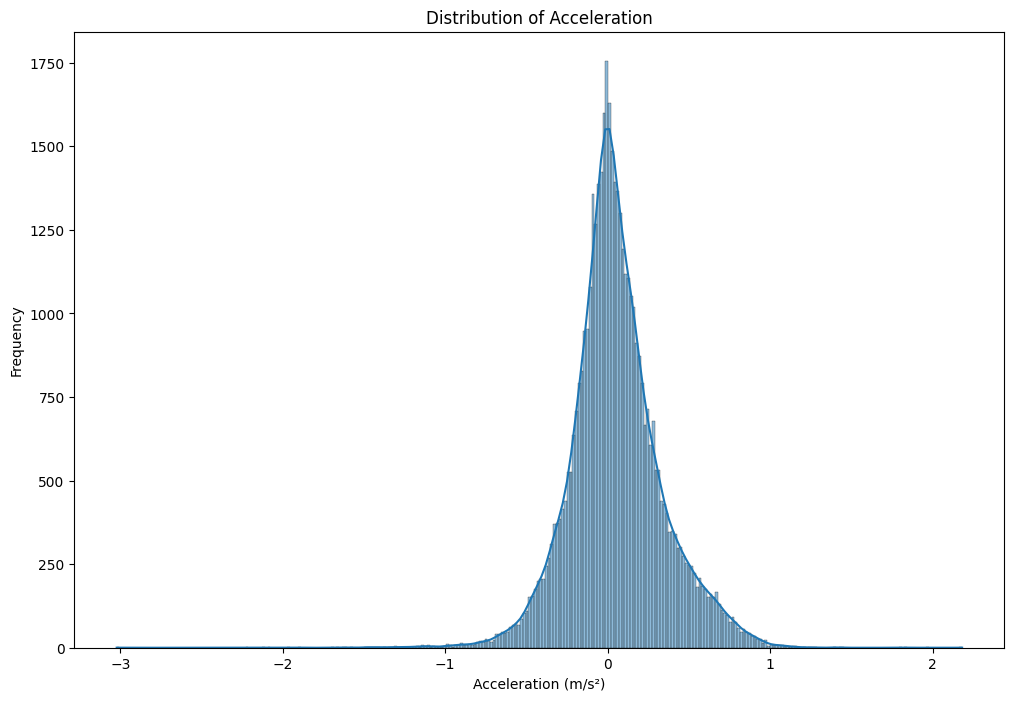

In [3]:
summary_stats = df.describe()

plt.figure(figsize=(12, 8))
sns.histplot(df['Acceleration(m/s^2)'], kde=True)
plt.title('Distribution of Acceleration')
plt.xlabel('Acceleration (m/s²)')
plt.ylabel('Frequency')
plt.show()

Third part

Distribution of Acceleration:

In this graph of distribution we can extract several points:
1) X axis shows us the "Acceleration" and Y axis shows us how frequent the corresponding "Acceleration" bar appears in data set.
2) The highest bar is around the acceleration value of 0 m/s^2. This means that the most frequently occurring acceleration value is close to 0.
3) The highest bar tells us that a lot of time the vehicle is neither accelerating nor decelerating, which shows a relatively stable and constant speed.
4) We can also see that the spread is left and right of the highest bar, telling us there are both deceleration and accelerations in data set, which means the left of the peak are negative values showing us the deceleration points and the right of the peak shows us the positive values meaning the accelerations or negative and positive accelerations respectively.

Extreme Values:

- The bars extend from -3 m/s^2 to +2 m/s^2.



Stable Speed:

- The high frequency of values around 0 m/s² suggests that the vehicle maintains a constant speed for a significant amount of time.

The reason why we plot this distribution of acceleration and not other features, is beacuse acceleration plays a fundamental role in fuel consumption. At the exact time of acceleration, any car or truck spends extreme fuel because it is needed additional power for the car to accelerate. This is why while accelerating, the fuel consumption of that exact moment reaches an extremely high value. 

##### **1.3 Correlation matrix of all features**

We specifically go through this step because correlation matrix  of features in data determines the degree to which two variables move in relation to each other, indicating how strongly two pairs of variables are related.

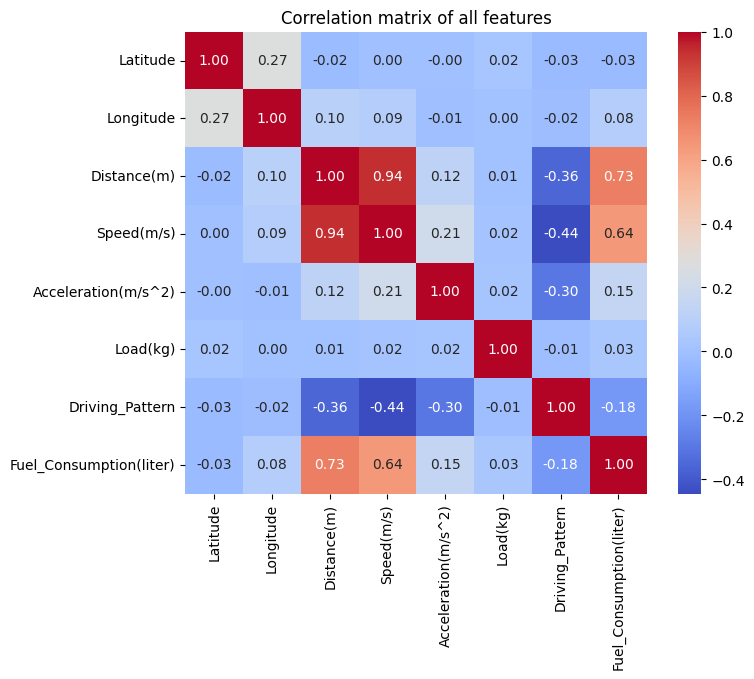

In [14]:
columns = df.columns
correlation_matrix = df[columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation matrix of all features')
plt.show()

First part

In this correlation matrix we can see strong and weak relations between several features:

Positive relations
1) Distance and Speed 
2) Distance and Fuel Consumption
3) Speed and Fuel COnsumpution

Negative relations:
1) Speed and Driving Pattern
2) Distance and Driving Pattern
3) Acceleration and Driving Pattern

Small positive relation:
1) Speed and Acceleration
2) Acceleration and Fuel Consumption

Small negative relation:
1) Driving pattern and Fuel Consumption

Distance and Speed seem to have a big correlation as their coefficient is 0.94. We will plot these two features, among other pair plots.

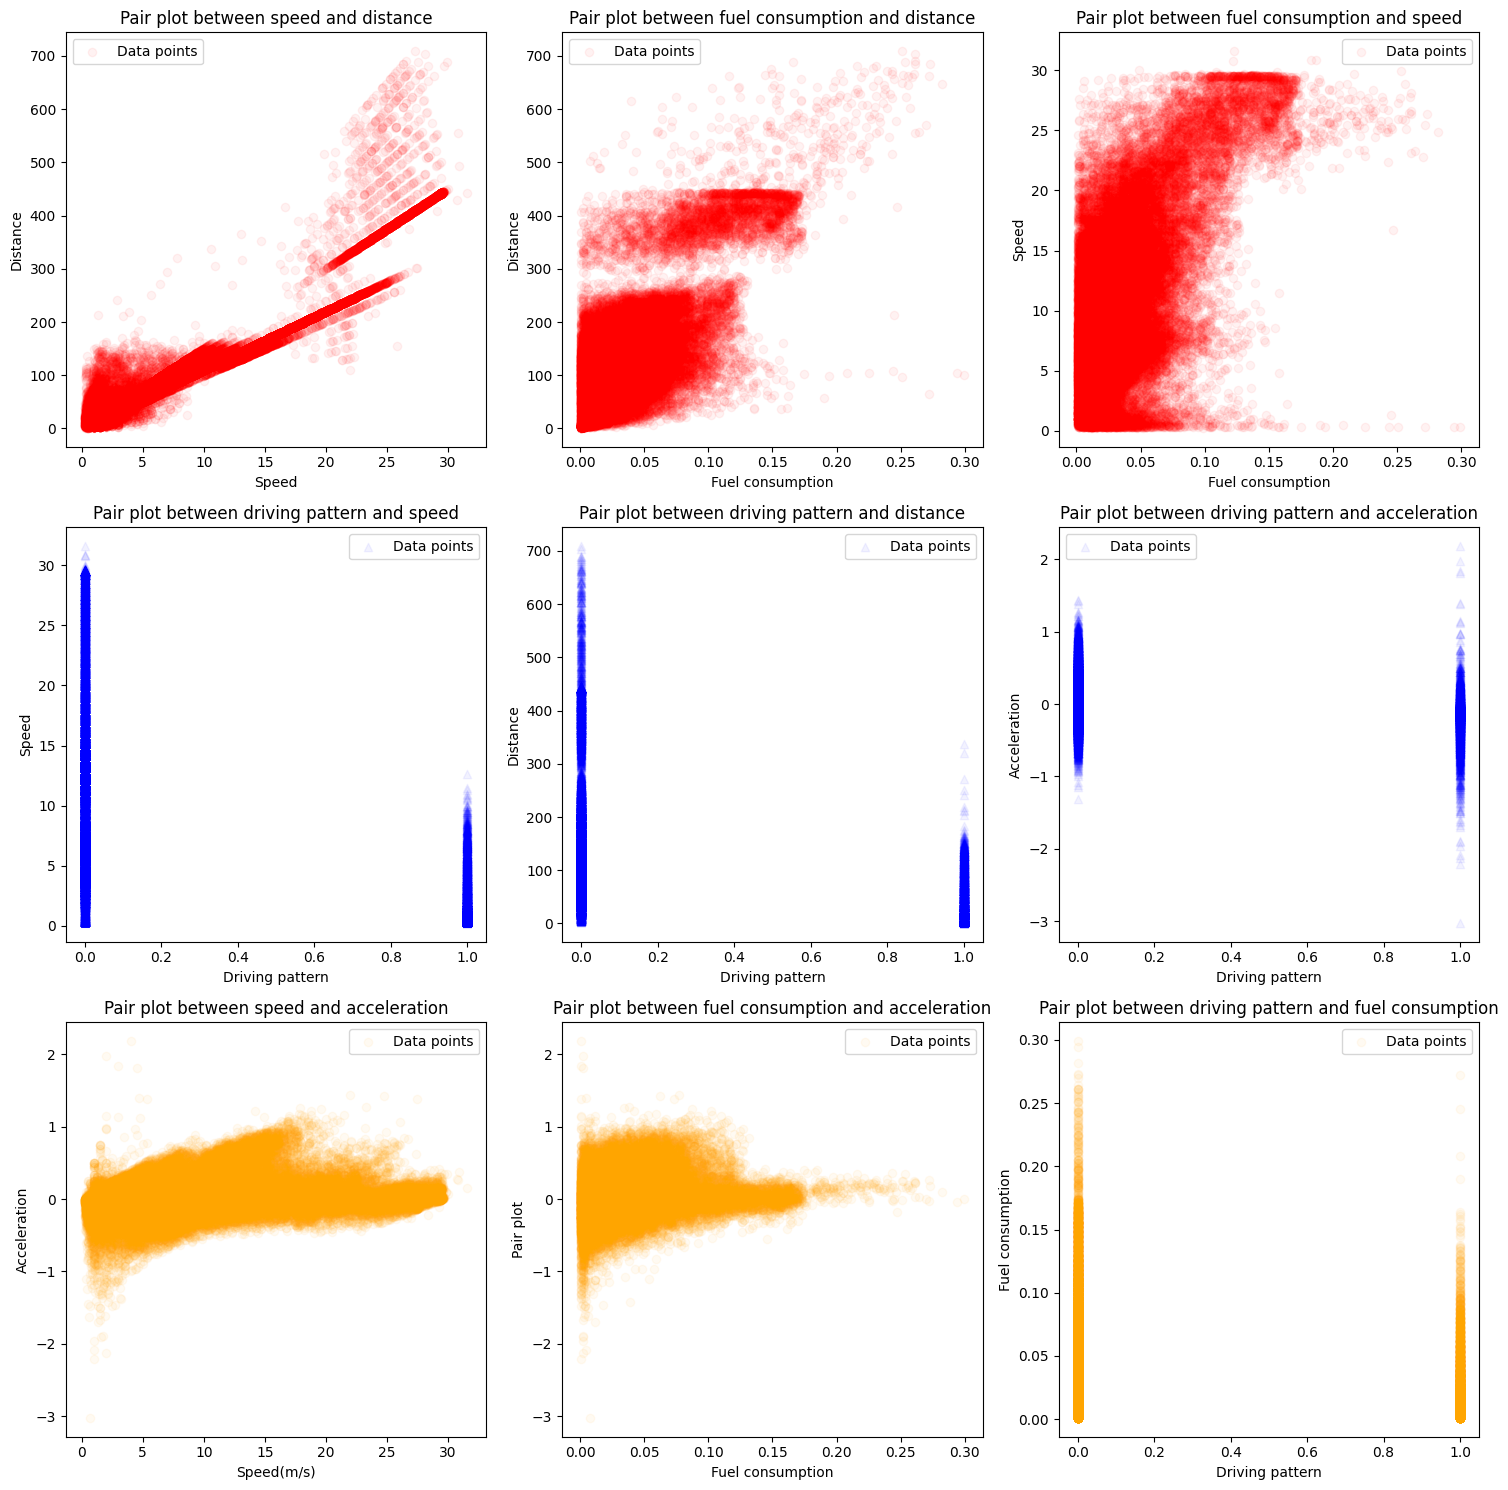

In [20]:
import matplotlib.pyplot as plt

# Create a function to plot each scatter plot
def plot_scatter(ax, x, y, xlabel, ylabel, title, color, marker):
    ax.scatter(x, y, label="Data points", color=color, marker=marker, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # 3x3 grid of subplots

# Plot each scatter plot in the grid
plot_scatter(axes[0, 0], df["Speed(m/s)"], df["Distance(m)"], "Speed", "Distance", "Pair plot between speed and distance", "red", "o")
plot_scatter(axes[0, 1], df["Fuel_Consumption(liter)"], df["Distance(m)"], "Fuel consumption", "Distance", "Pair plot between fuel consumption and distance", "red", "o")
plot_scatter(axes[0, 2], df["Fuel_Consumption(liter)"], df["Speed(m/s)"], "Fuel consumption", "Speed", "Pair plot between fuel consumption and speed", "red", "o")
plot_scatter(axes[1, 0], df["Driving_Pattern"], df["Speed(m/s)"], "Driving pattern", "Speed", "Pair plot between driving pattern and speed", "blue", "^")
plot_scatter(axes[1, 1], df["Driving_Pattern"], df["Distance(m)"], "Driving pattern", "Distance", "Pair plot between driving pattern and distance", "blue", "^")
plot_scatter(axes[1, 2], df["Driving_Pattern"], df["Acceleration(m/s^2)"], "Driving pattern", "Acceleration", "Pair plot between driving pattern and acceleration", "blue", "^")
plot_scatter(axes[2, 0], df["Speed(m/s)"], df["Acceleration(m/s^2)"], "Speed(m/s)", "Acceleration", "Pair plot between speed and acceleration", "orange", "o")
plot_scatter(axes[2, 1], df["Fuel_Consumption(liter)"], df["Acceleration(m/s^2)"], "Fuel consumption", "Pair plot", "Pair plot between fuel consumption and acceleration", "orange", "o")
plot_scatter(axes[2, 2], df["Driving_Pattern"], df["Fuel_Consumption(liter)"], "Driving pattern", "Fuel consumption", "Pair plot between driving pattern and fuel consumption", "orange", "o")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Second Part

 Pair plots

In order to have a better view and look for some outliers we plot the relation between these data points 

 


From these plots above we can say a few insights but not too informative:

1. When driving pattern is 0, speed and distance seems to be higher than when driving pattern is 1
2. Also when driving pattern is 1 we can see that the acceleration seems to be more variated than it is 0 
3. We can also see that when driving pattern is 0 Fuel consumption seems to be slightly higher compared to when the driving pattern is 1

Linear looking relations:

1. Speed and Distance seem a little bit linear but this does not tell us too much information
2. Fuel consumption and distance also seems to be somewhat linear but still not too clear information

##### **1.4 Pair plots of features with respect to only Fuel Consumption**

In addition to that, as we were taught in the lecture notes and by the Professor Voigtlaender, one should always investigate the relationship between each of the different features and the target variable. This can be done by using pair plots:

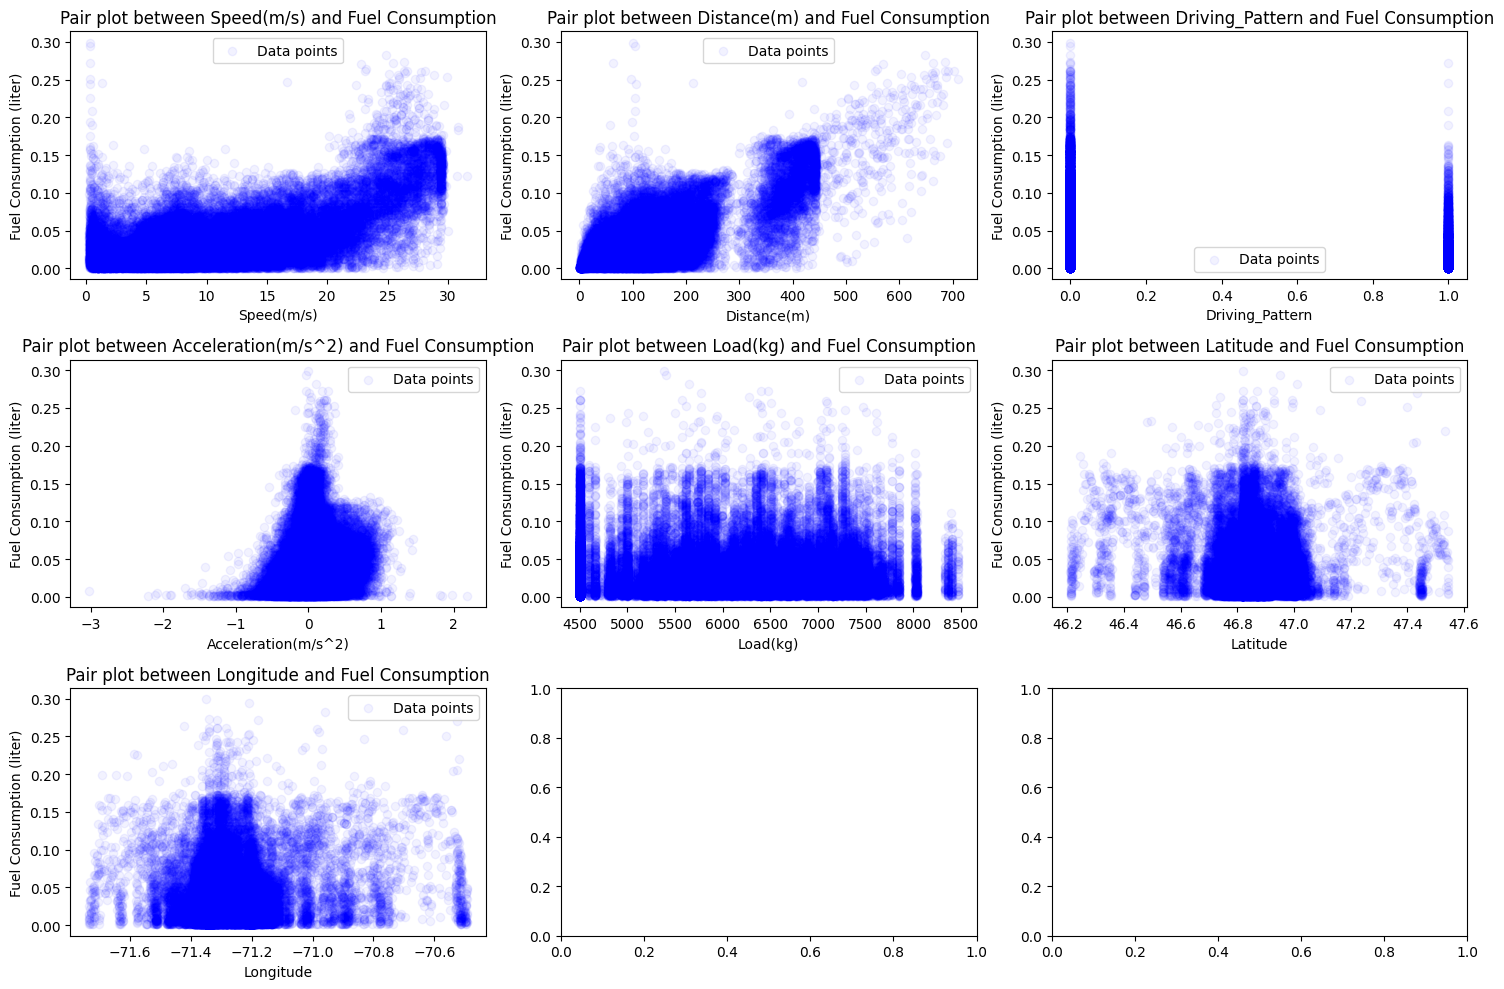

In [52]:
def plot_scatter(ax, x, y, xlabel, ylabel, title, color, marker):
    ax.scatter(x, y, label="Data points", color=color, marker=marker, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

features = ["Speed(m/s)", "Distance(m)", "Driving_Pattern", "Acceleration(m/s^2)", "Load(kg)", "Latitude", "Longitude"]
num_features = len(features)


num_rows = 3
num_cols = 3


fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))  


axes = axes.flatten()

for i, feature in enumerate(features):
    plot_scatter(
        axes[i],
        df[feature],
        df["Fuel_Consumption(liter)"],
        feature,
        "Fuel Consumption (liter)",
        f"Pair plot between {feature} and Fuel Consumption",
        "blue",
        "o"
    )


plt.tight_layout()
plt.show()

1) Speed(m/s) vs. Fuel Consumption(liter):
    - There seems to be a slight trend where higher speeds correlate with higher fuel consumption, particularly noticeable at speeds above 20 m/s


2) Driving_Pattern vs. Fuel Consumption(liter):
    - This could indicate distinct driving patterns (e.g., city vs. highway driving) with different fuel consumption characteristics. The clustering suggests that driving pattern is a categorical variable rather than continuous.

3) Load:
    - There doesn't seem to be a clear linear relationship.

4) Latitude and Longitude:
    - There doesn't seem to be a clear linear relationship.

Summary:

- Speed: Higher speeds generally correlate with higher fuel consumption, especially above 20 m/s.

- Distance: There are clusters of data points suggesting different segments of trips. No clear linear trend.

- Acceleration: Both positive and negative accelerations correlate strongly with increased fuel consumption.

- For columns Latitude and Longitute we will consider to drop them as they create additional noise for the data and there is no relationship with respect to the target variable

##### **1.5 Histogram**

First Part


As in our lecture we have also discussed about how important it is important before one starts to train a model, it is often useful to get a feeling for the data, and for instance to see if there are any obvious outliers that one might want to exclude from the dataset, or any obvious ways in which one could/should transform the different features to improve the performance of the final model 

One way of getting such a feeling is to plot histograms of the different features and of the target variable (in this case "fuel consumption"). This can be easily done using the hist method from Pandas.DataFrame:

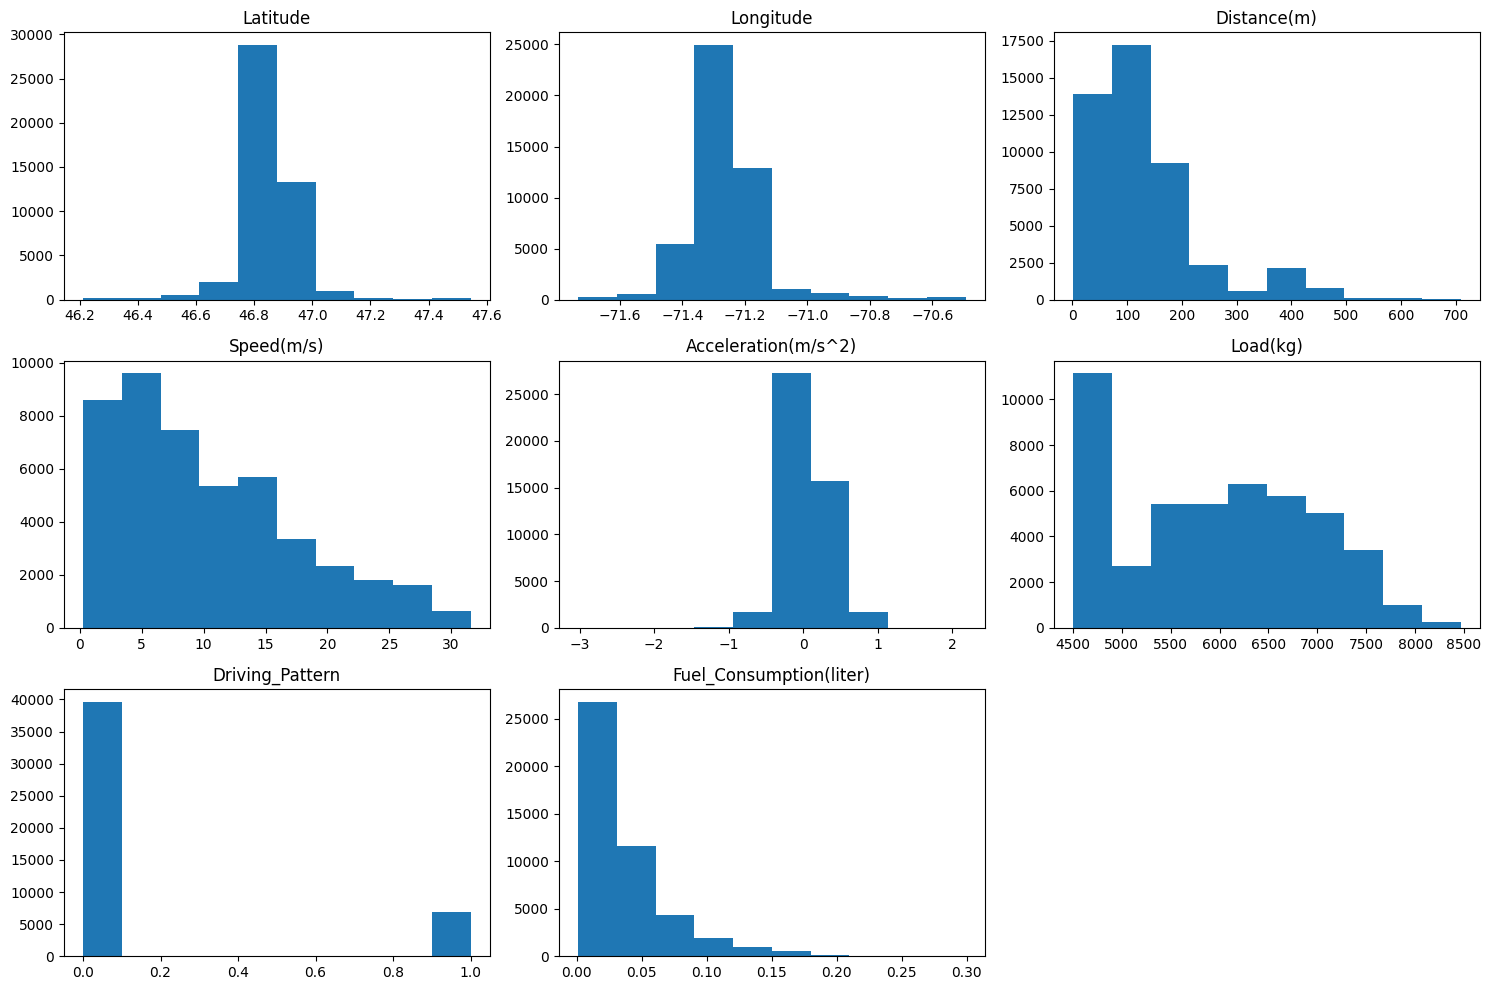

In [8]:
import matplotlib.pyplot as plt

# Create a histogram for each feature in the DataFrame
df.hist(figsize=(15, 10), grid=False)

plt.tight_layout() 
plt.show()

⦁	Distance shows a right-skewed distribution, suggesting most trips are short. 


⦁	Speed and Acceleration are also right-skewed, with more data points at lower values, indicating generally slower and smoother driving. Speed shows us that the majority trucks have a speed of between 0 and 10 m/s while the acceleration shows us that the majority trucks have an acceleration of close to 0 m/s^2 which roughly tells us that most of the trucks have a stable route , and maybe because of this there are a lot of trucks with driving pattern 0's rather than 1's. Maybe this tells us that the driving pattern 0 means the trucks are in highway or autobahn most of the time and 1 tells us that the trucks are in city making them to brake and accelerate periodically which causes the acceleration and deceleration.

⦁	Load has a wide spread with a significant number of entries at higher values showing us that more than 10 thousand trucks have a load between 4500 and 5000 kg

⦁	Driving pattern shows us that most of the trucks almost 40 thousand of them are in a driving patter 0 while very little portion is in driving pattern 1. 

⦁	Fuel Consumption shows us that the most cars more than 25 thousand have lower fuel consumption not exceeding 0.025

Second Part

As a team we have decided to look a closer look at the driving pattern to understand what it is and what are the relations with respect to key features such as Speed, Acceleration, Distance, Load and of course most importantly the Fuel Consumption


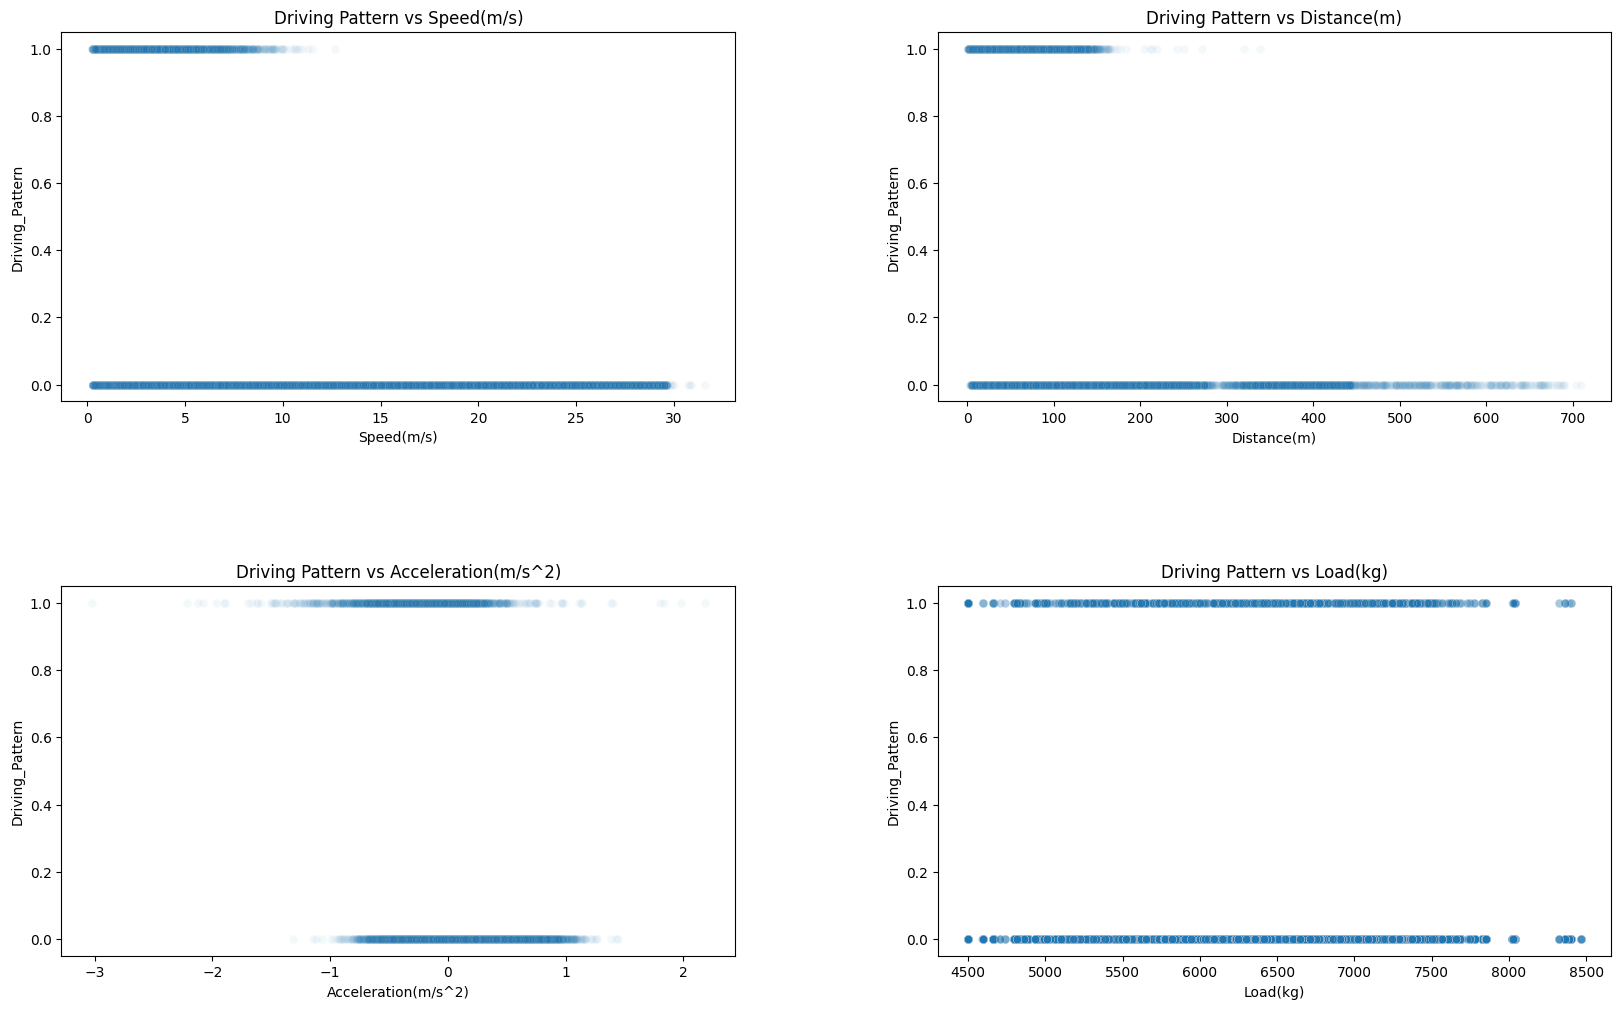

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(20, 12), gridspec_kw={'hspace': 0.5, 'wspace': 0.3})

# List of features to plot against Driving_Pattern
features = ['Speed(m/s)', 'Distance(m)', 'Acceleration(m/s^2)', 'Load(kg)']

for i, feature in enumerate(features):
    row, col = divmod(i, 2)  # Adjusting for 2x2 grid
    sns.scatterplot(x=df[feature], y=df['Driving_Pattern'], ax=axs[row, col], alpha=0.05)  
    axs[row, col].set_title(f'Driving Pattern vs {feature}')
    axs[row, col].set


⦁	Speed is higher in driving pattern 0 which is the key to understand what 0 means here. We can see that when driving pattern is 1 roughly the speed does not exceed 10 m/s while when it is 0 it goes up to the max value and most of the cars with driving cars is roughly saying more speedy in driving pattern 0

⦁	Distance is also higher in driving pattern 0 since speed and distance correlate with each other and also we can say that when driving pattern is 0 the speed is higher usually resulting in longer distances as well.

⦁	The key observation here is the acceleration, which tells us that when driving pattern is 1 majority cars are not stably driving, they accelerate and decelerate very often with strong accelerations and decelerations telling us that there is a strong braking and strong acceleration which also might be in a city based place

⦁	With regards to the Load, there is no specific change or outlier, roughly saying in our dataset the load does not affect anything 

⦁	Interestingly even though we assumed that when the driving patter is 0 the fuel consumption would be lower than when the driving pattern is 1 but in this graph we can see that it is not the case, in fact we observe that when driving pattern is 1 the fuel consumption does not exceed 0.15 liters except 4 points which do not really give big difference. From this observation we assume that driving pattern being 0 does not mean that the fuel consumption would be lower even the acceleration is stable. But later in this documentation there will be an interesting observation regarding driving pattern and fuel consumption.

##### **1.6 3D Scatter plots**

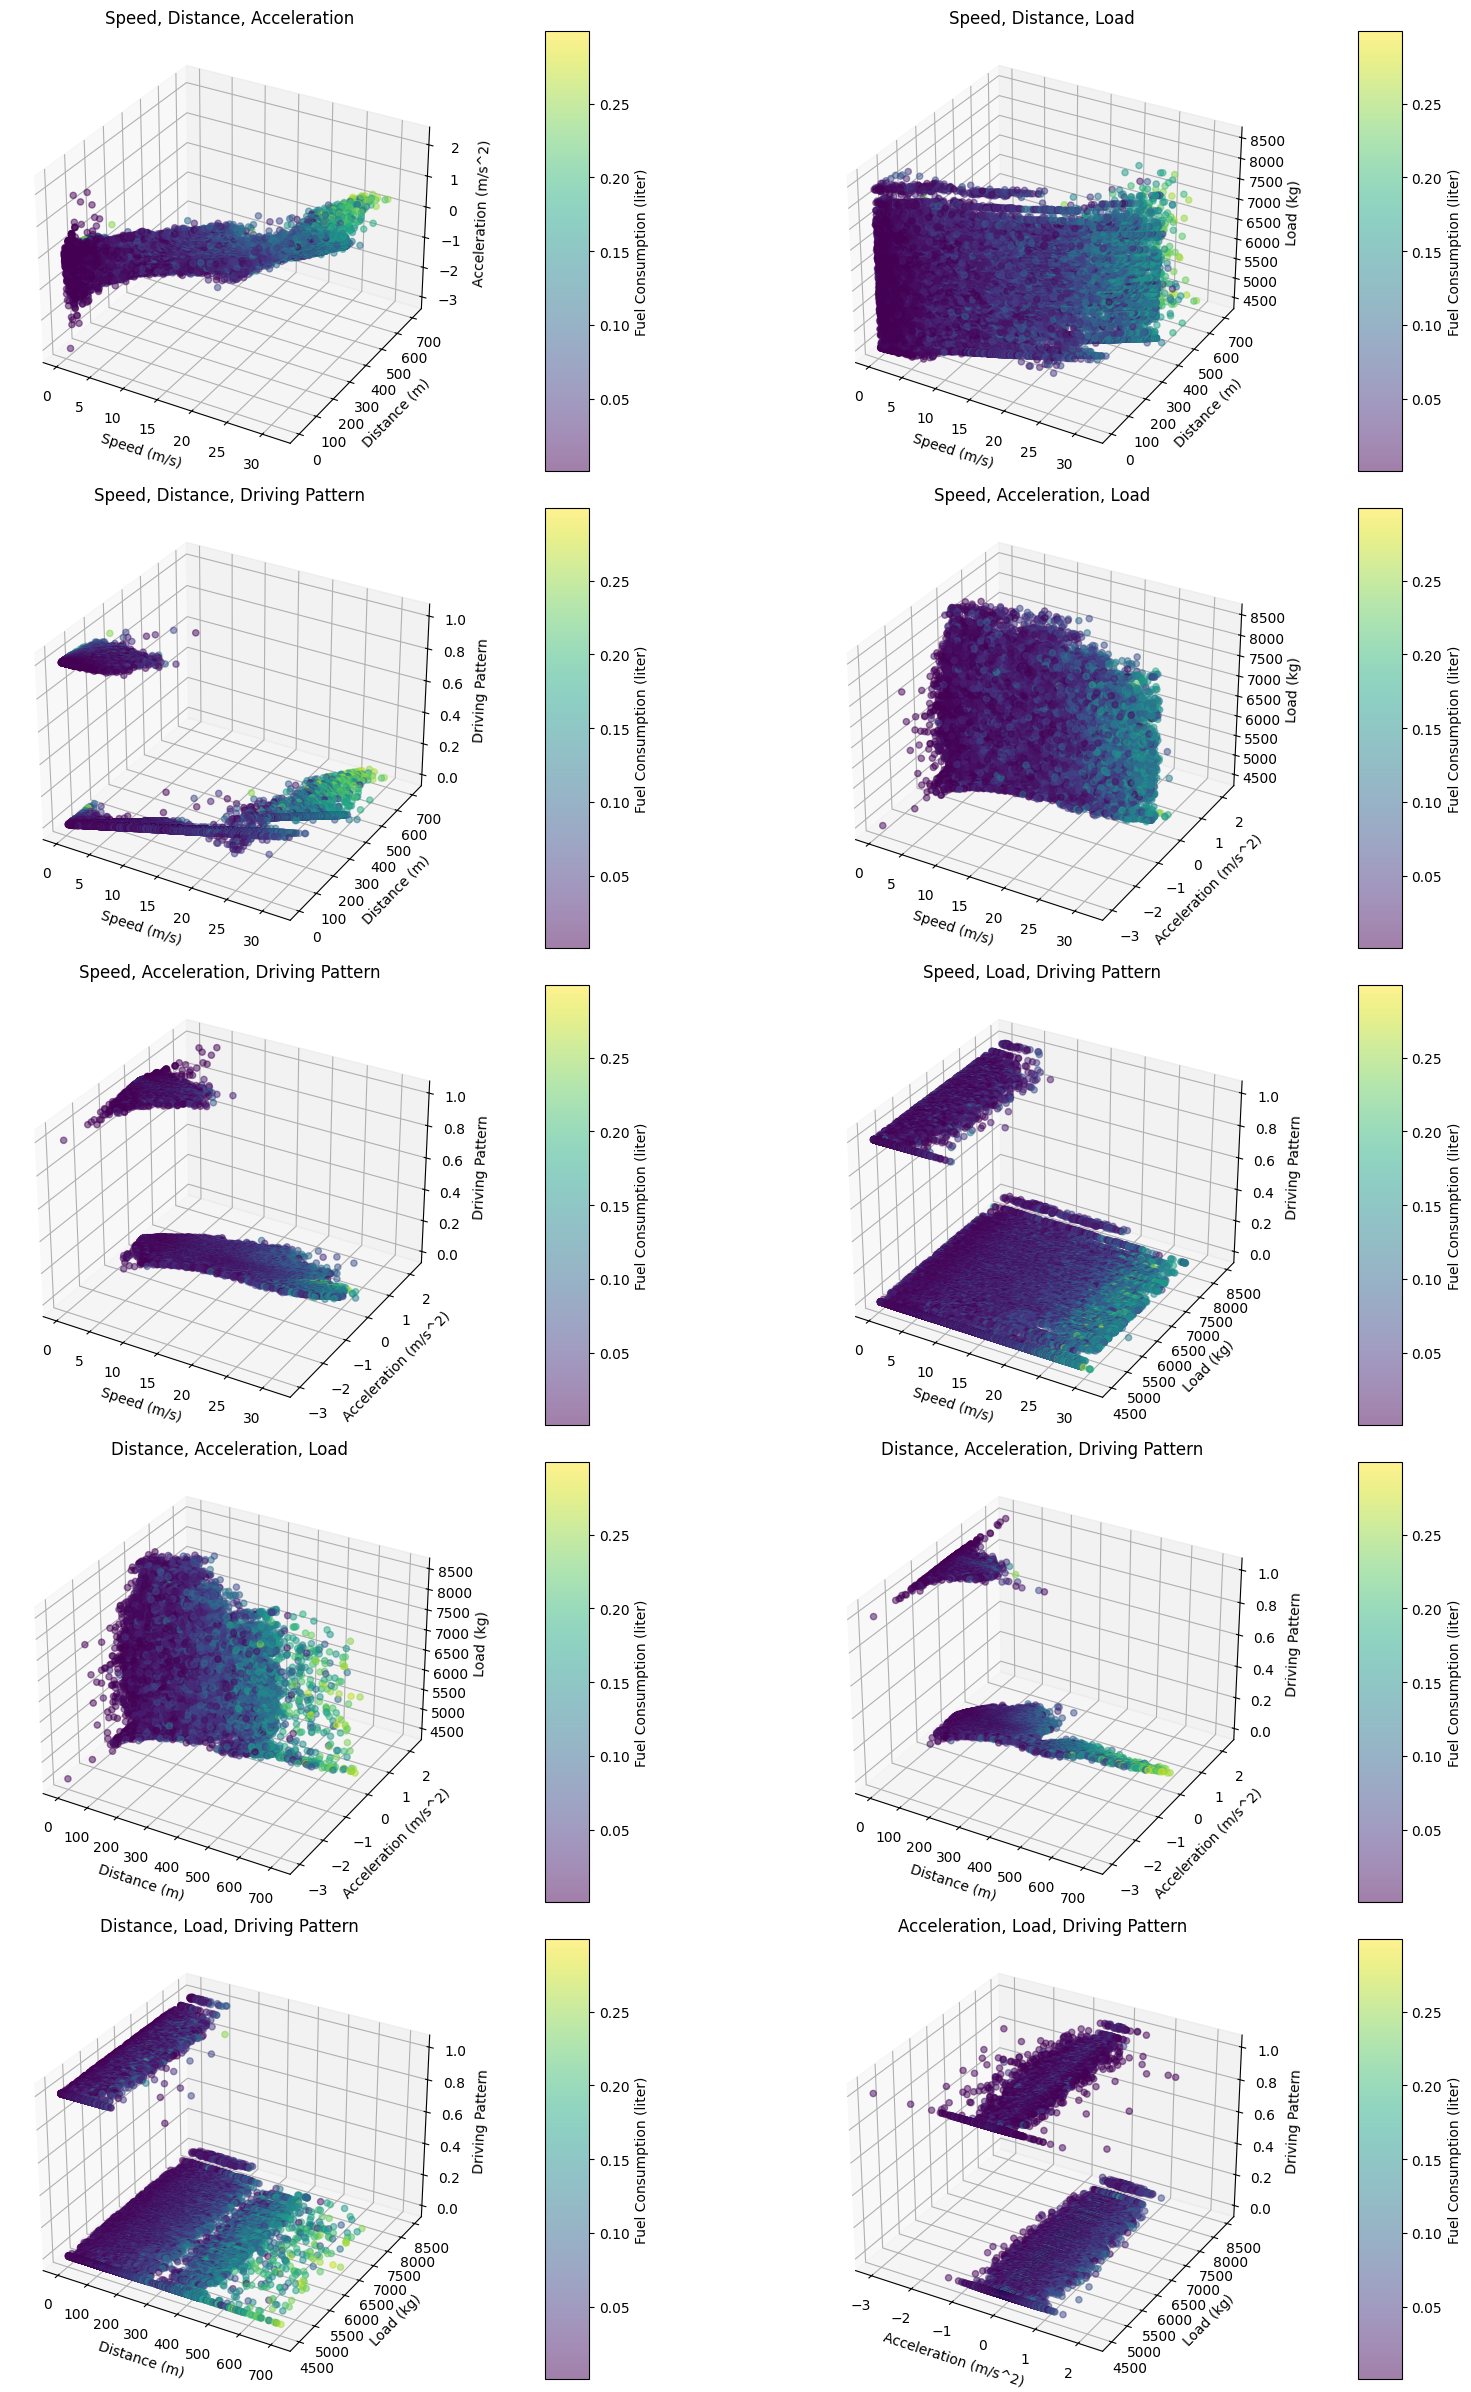

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Function to plot a 3D scatter plot with color-coded fuel consumption
def plot_3d_scatter(ax, x, y, z, c, xlabel, ylabel, zlabel, clabel, title):
    scatter = ax.scatter(x, y, z, c=c, cmap='viridis', marker='o', alpha=0.5)
    cbar = plt.colorbar(scatter, ax=ax, pad=0.1, aspect=10)
    cbar.set_label(clabel)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)

# Define the number of rows and columns for the subplots grid
num_rows = 5
num_cols = 2

# Create subplots
fig = plt.figure(figsize=(18, 24))  # Adjust the figure size as needed


# Plot combinations of features
plots = [
    (df['Speed(m/s)'], df['Distance(m)'], df['Acceleration(m/s^2)'], df['Fuel_Consumption(liter)'],
     'Speed (m/s)', 'Distance (m)', 'Acceleration (m/s^2)', 'Fuel Consumption (liter)',
     'Speed, Distance, Acceleration'),

    (df['Speed(m/s)'], df['Distance(m)'], df['Load(kg)'], df['Fuel_Consumption(liter)'],
     'Speed (m/s)', 'Distance (m)', 'Load (kg)', 'Fuel Consumption (liter)',
     'Speed, Distance, Load'),

    (df['Speed(m/s)'], df['Distance(m)'], df['Driving_Pattern'], df['Fuel_Consumption(liter)'],
     'Speed (m/s)', 'Distance (m)', 'Driving Pattern', 'Fuel Consumption (liter)',
     'Speed, Distance, Driving Pattern'),

    (df['Speed(m/s)'], df['Acceleration(m/s^2)'], df['Load(kg)'], df['Fuel_Consumption(liter)'],
     'Speed (m/s)', 'Acceleration (m/s^2)', 'Load (kg)', 'Fuel Consumption (liter)',
     'Speed, Acceleration, Load'),

    (df['Speed(m/s)'], df['Acceleration(m/s^2)'], df['Driving_Pattern'], df['Fuel_Consumption(liter)'],
     'Speed (m/s)', 'Acceleration (m/s^2)', 'Driving Pattern', 'Fuel Consumption (liter)',
     'Speed, Acceleration, Driving Pattern'),

    (df['Speed(m/s)'], df['Load(kg)'], df['Driving_Pattern'], df['Fuel_Consumption(liter)'],
     'Speed (m/s)', 'Load (kg)', 'Driving Pattern', 'Fuel Consumption (liter)',
     'Speed, Load, Driving Pattern'),

    (df['Distance(m)'], df['Acceleration(m/s^2)'], df['Load(kg)'], df['Fuel_Consumption(liter)'],
     'Distance (m)', 'Acceleration (m/s^2)', 'Load (kg)', 'Fuel Consumption (liter)',
     'Distance, Acceleration, Load'),

    (df['Distance(m)'], df['Acceleration(m/s^2)'], df['Driving_Pattern'], df['Fuel_Consumption(liter)'],
     'Distance (m)', 'Acceleration (m/s^2)', 'Driving Pattern', 'Fuel Consumption (liter)',
     'Distance, Acceleration, Driving Pattern'),

    (df['Distance(m)'], df['Load(kg)'], df['Driving_Pattern'], df['Fuel_Consumption(liter)'],
     'Distance (m)', 'Load (kg)', 'Driving Pattern', 'Fuel Consumption (liter)',
     'Distance, Load, Driving Pattern'),

    (df['Acceleration(m/s^2)'], df['Load(kg)'], df['Driving_Pattern'], df['Fuel_Consumption(liter)'],
     'Acceleration (m/s^2)', 'Load (kg)', 'Driving Pattern', 'Fuel Consumption (liter)',
     'Acceleration, Load, Driving Pattern')
]

# Loop through the plots and create each subplot
for i, (x, y, z, c, xlabel, ylabel, zlabel, clabel, title) in enumerate(plots):
    ax = fig.add_subplot(num_rows, num_cols, i + 1, projection='3d')
    plot_3d_scatter(ax, x, y, z, c, xlabel, ylabel, zlabel, clabel, title)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


From 3d plots above we combined multiple feature combinations with respect to fuel consumption, and we have several points to mention:

⦁	Speed, Distance, Acceleration: Displays a positive correlation between speed and distance, with notable outliers having high speeds and distances combined with negative acceleration.

⦁	Speed, Distance, Load: Shows a spread without strong correlation, which we can confirm that the load does not play any role.

⦁	Speed, Distance, Driving Pattern: Driving pattern 1 does not tell anything to us, we can see that the most datas are in driving pattern 0 and there is a cluster at middle distances and speeds.

⦁	Speed, Acceleration, Load: Shows a broad distribution with outliers at extreme speeds and we can also observe that the fuel consumption is higher at extreme speeds starting from 20-25 m/s with positive acceleration but the load does not play a role also

⦁	Speed, Acceleration, Driving Pattern: Here we can say that when driving pattern is 0 and speed is more than 20 m/s with positive acceleration the fuel consumption is higher usually

⦁	Distance, Acceleration, Load: Distance more than 300 m  and load up to 6500 kg with positive acceleration have higher fuel consumption

⦁	Distance, Acceleration, Driving Pattern: Driving pattern with 0 and the distance exactly being more than 300 m with positive acceleration also have more fuel consumption

⦁	Distance, Load, Driving Pattern: We can again see that exactly at distances roughly more than 300 m with driving pattern 0 with not too big affect of the load we have higher fuel consumption

##### **1.7 Evaluation of average fuel consumption**

At the beginning of this documentation there were stated several questions and this point will basically cover the first question:

⦁	 " What is the average fuel consumption with respect to the same load(kg) based on other features? An even detailed explanation to this question would be, assuming that the instances with the same load(kg) is one specific truck and we want to measure the average fuel consumption of this specific truck based on its acceleration, speed and driving pattern because we assumed that the instances with the same loads(kg) is the same truck." 

In [33]:
# Compute average, min, and max fuel consumption for each 'Load(kg)'
grouped_stats = df.groupby('Load(kg)').agg({
    'Fuel_Consumption(liter)': ['mean', 'min', 'max']
}).reset_index()

# Flatten MultiIndex columns
grouped_stats.columns = ['Load(kg)', 'Average_Fuel_Consumption(liter)', 'Min_Fuel_Consumption(liter)', 'Max_Fuel_Consumption(liter)']

# Compute overall min and max fuel consumption and find corresponding groups
min_fuel_consumption = df['Fuel_Consumption(liter)'].min()
max_fuel_consumption = df['Fuel_Consumption(liter)'].max()

min_fuel_group = df.loc[df['Fuel_Consumption(liter)'] == min_fuel_consumption, 'Load(kg)'].values[0]
max_fuel_group = df.loc[df['Fuel_Consumption(liter)'] == max_fuel_consumption, 'Load(kg)'].values[0]

# Compute the overall average fuel consumption
overall_average_fuel_consumption = df['Fuel_Consumption(liter)'].mean()

# Print the number of groups
num_groups = len(grouped_stats)
print(f"Number of groups: {num_groups}")

# Print the groups and their average, min, and max fuel consumption
print("\nGroups and their average, minimum, and maximum fuel consumption:")
print(grouped_stats)

# Print the overall minimum and maximum fuel consumption and their respective groups
print(f"\nOverall minimum fuel consumption: {min_fuel_consumption:.2f} (Load: {min_fuel_group})")
print(f"Overall maximum fuel consumption: {max_fuel_consumption:.2f} (Load: {max_fuel_group})")

# Print the overall average fuel consumption
print(f"\nOverall average fuel consumption: {overall_average_fuel_consumption:.2f}")
   

Number of groups: 735

Groups and their average, minimum, and maximum fuel consumption:
     Load(kg)  Average_Fuel_Consumption(liter)  Min_Fuel_Consumption(liter)  \
0      4500.0                         0.033699                        0.001   
1      4588.1                         0.020714                        0.002   
2      4596.0                         0.058690                        0.001   
3      4661.0                         0.045727                        0.001   
4      4664.5                         0.022222                        0.001   
..        ...                              ...                          ...   
730    8360.2                         0.033907                        0.001   
731    8360.4                         0.027648                        0.001   
732    8391.8                         0.027455                        0.001   
733    8404.8                         0.039015                        0.001   
734    8465.5                         0.032

⦁	Here we calculated the mean, min, max fuel consumption of each group with the same load and we calculated the overall minimum and maximum fuel consumption for all the groups and we also computed the overall average fuel consumption. 

⦁	This information is provided regardless of the distance and this information might be very useful in our model

⦁	Overall minimum fuel consumption: 0.00 (Load: 5641.5)

⦁	Overall maximum fuel consumption: 0.30 (Load: 5383.5)

⦁	Overall average fuel consumption: 0.04

⦁	Number of groups: 735

##### **1.8 Top 20 Highest Fuel Consumption per Driving Pattern**

<Figure size 1000x600 with 0 Axes>

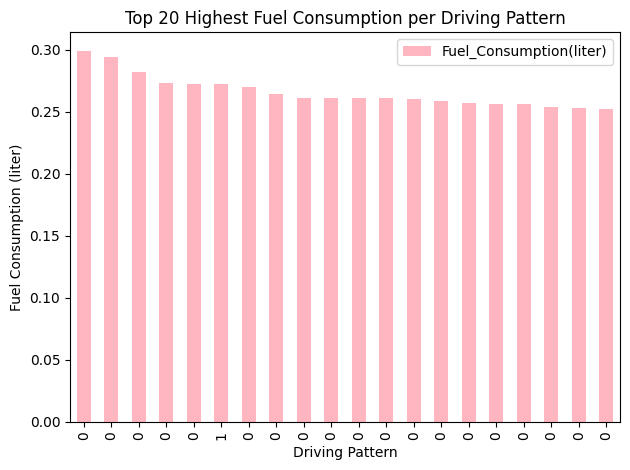

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Sort by fuel consumption and get the top 20 entries
top_20_fuel_consumption = df.nlargest(20, 'Fuel_Consumption(liter)')

# Plot for Driving Pattern
plt.figure(figsize=(10, 6))
top_20_fuel_consumption.plot(kind='bar', x='Driving_Pattern', y='Fuel_Consumption(liter)', color='lightpink')
plt.title('Top 20 Highest Fuel Consumption per Driving Pattern')
plt.xlabel('Driving Pattern')
plt.ylabel('Fuel Consumption (liter)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

⦁	Also in this chart we can see that the top 20 fuel consumption corresponds to the driving pattern with only 0's except only there is just 1 driving pattern with 1. 

⦁	The highest fuel consumption values are dominated by driving pattern 0.

⦁	Only one instance of driving pattern 1 appear among the highest 20 consumption values.

⦁	Driving pattern 0 exhibits the top consumption values, indicating more varied and higher fuel use in these instances.

⦁	Driving pattern 1 shows lower fuel consumption compared to pattern 0 in the top 20 values, suggesting more efficient or consistent fuel use.

⦁	This chart suggests that driving pattern 0 is associated with the highest fuel consumption scenarios, while pattern 1 tends to have lower maximum fuel consumption values

⦁	This finally helps us to make sure that when driving pattern is 0 the fuel consumption is higher.

The code below after reading the dataframe was written with the help of ChatGPT for only the demonstration purposes of how the driving pattern 0 and 1's with respect to coordinates Latitude and Longitude look like on a map where the red points are driving pattern 0's and blue points are 1's. On the map, we can as well observe that the red points appear on highway and more spread out of the city whereas the blue points(driving pattern 1's) appear mostly in the middle of the city which actually tells us that the assumption that 0 is more highway type of road and 1 is more like a city based streets.

THE MAP image IS ADDED IN DOCUMENTATION (NOTEPAD VERSION OF DOCUMENTATION)

NOTE: This code takes about 3 minutes to run and save the map into your computer

In [35]:
import pandas as pd
import folium

# Load datasets
df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")

# Rename column in df2 to match df1
df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)

# Concatenate datasets
df = pd.concat([df1, df2], ignore_index=True)

# Drop 'Id' column
df.drop(["Id"], axis=1, inplace=True)

# Display DataFrame info
print(df.info())

# Ensure that DataFrame has the correct columns
if 'Latitude' not in df.columns or 'Longitude' not in df.columns:
    raise ValueError("DataFrame must contain 'Latitude' and 'Longitude' columns")

# Create a map centered around the average location
center_lat = df['Latitude'].mean()
center_lon = df['Longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=5)

# Separate the data based on Driving_Pattern
pattern_0 = df[df['Driving_Pattern'] == 0]
pattern_1 = df[df['Driving_Pattern'] == 1]

# Function to add points for a given pattern
def add_points_to_map(map_obj, data, color):
    for idx, row in data.iterrows():
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=3,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            popup=f"Location {idx}"
        ).add_to(map_obj)


add_points_to_map(m, pattern_0, 'red')
add_points_to_map(m, pattern_1, 'blue')


m.save('map3.html')

print("Map has been created and saved as map3.html")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46476 entries, 0 to 46475
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Latitude                 46476 non-null  float64
 1   Longitude                46476 non-null  float64
 2   Distance(m)              46476 non-null  int64  
 3   Speed(m/s)               46476 non-null  float64
 4   Acceleration(m/s^2)      46476 non-null  float64
 5   Load(kg)                 46476 non-null  float64
 6   Driving_Pattern          46476 non-null  int64  
 7   Fuel_Consumption(liter)  46476 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 2.8 MB
None


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10a829490>>
Traceback (most recent call last):
  File "/Users/manuel/Library/Python/3.12/lib/python/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Map has been created and saved as map3.html



#### **2. Conclusion**

In this exploratory data analysis of fuel road consumption, we tried to go really deeep as much as possible into the data to pull out useful insights. We started by understanding the context from the original article and framed key questions to steer our analysis. 

After loading and cleaning the data, ensuring there were no missing values and all data types were correct, we moved on to exploring the data. We found some interesting patterns and relationships between the features. For instance, there's a strong correlation between speed, distance, and fuel consumption, as well as the impact of acceleration and driving patterns on fuel efficiency. 

Using histograms and scatter plots, we visualized these interactions and identified key trends and outliers. We specifically looked at fuel consumption in relation to load (by grouping them), calculating the mean, minimum, and maximum fuel consumption for different load groups. This helped us understand how different factors influence fuel usage. 

Finally, we examined the top 20 instances of highest fuel consumption, which highlighted the significant impact of driving patterns, with pattern 0 being associated with higher fuel consumption. 

Overall, this EDA has given us a solid understanding of the dataset and will guide us in building effective models to predict fuel consumption and optimize driving strategies.

## **Training models**

In this project we will demonstrate 2 ML problems, but mostly we will focus on 'Classification' as it makes more sense to predict 'Driving Pattern' here rather than predicting 'Fuel consumption'. This is because the values of the features that are measured are not the average values, they are the values of specific points measurements. We could say these values are measured at one point not throughout the whole ride, this is why it does not make  a lot of sense (also makes the problem extremely hard) to predict a fuel consumption that belongs to a specific point. It would make so much more sense to predict the average fuel consumption, if the measurements in the data set were the average values over a specific distance or over a specific time (or between two points). 

This is why we will try to demonstrate some regression models, but we will not be too extremely focused on it, because we will have two phases in 'Regression' whereas in 'Classification' we will have only one phase. Accordingly, we will try to cover as much as possible of the whole course material in terms of regression and classification, even though we figured out that it is much more logical to do classification (to predict Driving_Pattern) in this topic rather than regression. We want to demonstrate to the ones who read this project a broad overview of machine learning.

### **Phase 1: Predicting fuel consumption**
### **Approach 1**

In this approach, we will demonstrate all models with detailed explanations by splitting the data using train_test_split. 

NOTE: The original data was already split into training and testing CSV files. This is why we will have 2 Approaches in this Phase 1. In this first approach we will be working with combination of the original training and testing CSV files into one data frame called "df". We will work with this concatenated data frame throughout this Phase 1. Meanwhile we will work with the original split in our second approach.

Explanation of the code below:
1) Loading both training and testing csv files into Python using Pandas DataFrame.
2) The training csv file is named "training_dataset.csv" and the testing csv file is named "testing_dataset.csv".
3) We give a name to both data sets, "df1" and "df2" respectively.
4) We manually checked both data sets to look for some anomaly and we found out that there is a typo in the name of one of the feature names. The typo was in the testing csv file, it was written 'Acceleration(m^2)' which logically does not make any sense since acceleration can not be measured by squared meters (m^2). This is why we changed the name of this column in the testing csv file to 'Acceleration(m/s^2)'.
5) AWe know one must do is to check what kind of data we are working with, namely check the number of samples, the number of features, the type of each feature, and if there exist any missing values.
6) Before inspecting the data we combined df1 and df2 and named it just "df".
7) As inspected we have following properties:
    - 46476 samples.
    - 8 features.
    - 1 target value namely "Fuel_Consumption(liter)".
    - 0 missing values in each feature.
    - No "object" type , all float or int, this means we can pass the features into our machine learning algorithm without any problem.
    - 1 Binary feature namely "Driving_Pattern" consisting of only 0's and 1's (We have already mentioned in EDA what this feature means).
    - Driving_Pattern has 39638 times of class 0 and 6838 times of class 1,  85% of Driving pattern class 0 and 15% of class 1.
        - Class 0          39638
        - Class 1          6838
8) Out of 8 features we have a feature called "Id" which is just index feature which we do not need,  this is why we dropped this column.



    

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np


df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")
# we changed the column name because there was a typo in column name of testing set
df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)

#print(df1)   
#print(df1.info())

#print()
#print(df2)
#print(df2.info())
#print()
#print()

# Combining the training and testing data along rows
df = pd.concat([df1, df2], ignore_index=True)
print(df.isna().sum())
print()
print(df["Driving_Pattern"].value_counts())
print()
df.drop(["Id"], axis=1, inplace=True)
#print(df)

print("DATA FRAME ITSELF")
print(df)
print()
print()
print("DATA FRAME INFO")
print(df.info())





Id                         0
Latitude                   0
Longitude                  0
Distance(m)                0
Speed(m/s)                 0
Acceleration(m/s^2)        0
Load(kg)                   0
Driving_Pattern            0
Fuel_Consumption(liter)    0
dtype: int64

Driving_Pattern
0    39638
1     6838
Name: count, dtype: int64

DATA FRAME ITSELF
        Latitude  Longitude  Distance(m)  Speed(m/s)  Acceleration(m/s^2)  \
0      46.864846 -71.216451           41    2.928571             0.207560   
1      46.865222 -71.215906           60    4.000000             0.071429   
2      46.865953 -71.216578           98    6.533333             0.168889   
3      46.866003 -71.216643           16    1.454545            -0.461708   
4      46.865876 -71.217451           52    4.727273             0.297521   
...          ...        ...          ...         ...                  ...   
46471  46.821074 -71.348245           23    4.600000            -0.280000   
46472  46.821026 -71.34829

#### **Separation of data into x and y, train and test**

If we want to train a model using scikit-learn, we first need to separate the data into the "X -part" (the features) and the "y -part" (the target variable).

Then, we split the data into train and test data using the function train_test_split from the scikit-learn module.

This function randomly shuffles the data and then splits it into train and test sets, where the size of the test set (as a fraction of the total number of training points) can be specified using the test_size or train_size parameter.

As we said we first need to separate X and Y:
- In our dataset it is already separated but we do it manually again because we want to demonstrate in this approach, one of the most important functions in machine learning which is train_test_split function

Explanation:

1) We have dropped the target column for "x" because we want to predict this feature that is why it can not be in "x", accordingly we assign this target column to "y".
2) Using the function built in scikit-learn namely the train_test_split we split the data into training and testing datas where we passed the parameters of train_size to be 80% meaning the rest 20% will be as a testing data.
3) We check what "x" and "y" looks like by looking at the info.
4) We see that we have 7 features left for x and y is the target variable.

In [9]:
import random
x = df.drop(["Fuel_Consumption(liter)"], axis=1)
y= df["Fuel_Consumption(liter)"]

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.80, random_state = 42)


print("INFO ABOUT X")
print(x.info())
print()
print("INFO ABOUT Y")
print(y.info())


INFO ABOUT X
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46476 entries, 0 to 46475
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Latitude             46476 non-null  float64
 1   Longitude            46476 non-null  float64
 2   Distance(m)          46476 non-null  int64  
 3   Speed(m/s)           46476 non-null  float64
 4   Acceleration(m/s^2)  46476 non-null  float64
 5   Load(kg)             46476 non-null  float64
 6   Driving_Pattern      46476 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 2.5 MB
None

INFO ABOUT Y
<class 'pandas.core.series.Series'>
RangeIndex: 46476 entries, 0 to 46475
Series name: Fuel_Consumption(liter)
Non-Null Count  Dtype  
--------------  -----  
46476 non-null  float64
dtypes: float64(1)
memory usage: 363.2 KB
None


#### **Simple linear regression**

Since we are doing linear regression, it would be important to have such a linear relationship between the features and the target variable. We will see how to address this problem, but first we will simply train a linear regression model using the features as they are.

1) We fit our training data into LinearRegression model 
2) Then we evaluate the performance of our model in terms of MSE, RMSE AND R^2, both on the training data and on the test data

In [11]:
print("TRAIN UNTRAINED MODEL")
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)


## we now compute the MSE, RMSE, and R^2
## we evaluate the performance of our model

from sklearn.metrics import mean_squared_error

MSE_train = mean_squared_error(lin_reg.predict(x_train), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test, y_test))


# we can see that our R2 score on training data is 56% and on test data is 55% which is pretty bad

TRAIN UNTRAINED MODEL
MSE TRAIN: 0.0005455987481991405
RMSE TRAIN: 0.023358055317152165
R^2 SCORE TRAIN: 0.5562361103653188

MSE TEST: 0.0005461017525688443
RMSE TEST: 0.023368820093638536
R^2 SCORE TEST: 0.5465833589591043


We see that the average error of our prediction (as given by the RMSE) is roughly 0.02 liters, which is bad, since the Fuel Consumption in liters variable ranges between 0.01 and 0.299 liters with mean= 0.03.

Furthermore, the  R^2  score is around 55% (0.55), which is bad. Below we will try to further improve the performance of our model.

We can also see that the train and test scores are really close to each other showing there that there is no overfitting yet.


#### **Plot predicted and actual values**

As a final test, it is often useful to plot the relation between the predicted values and the ground truth values. In this way one can see if there is a discernable pattern in the errors that one is making. 


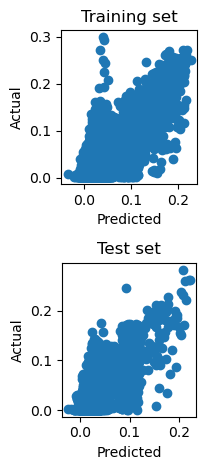

In [6]:
fig, axes= plt.subplots(2)

axes[0].scatter(lin_reg.predict(x_train), y_train)
axes[0].set_title("Training set")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_aspect("equal", adjustable= "box")

axes[1].scatter(lin_reg.predict(x_test), y_test)
axes[1].set_title("Test set")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_aspect("equal", adjustable= "box")

fig.tight_layout()
plt.show()


For example, looking at the testing set in this plot we see that very large values are getting underpredicted and also we see that the actual value in the middle area is close to 0.2 but the predicted value is 0.1 for some data points.

#### **Coefficient Plot**

We will talk about what exactly feature engineering is after showing this coefficient plot

COEFFICIENT PLOT
LENGTH OF COEF UNTRAINED 1 MODEL SHOULD BE 7 BEFORE PLOT: 7

Feature names: ['Latitude', 'Longitude', 'Distance(m)', 'Speed(m/s)', 'Acceleration(m/s^2)', 'Load(kg)', 'Driving_Pattern']

COEFFICIENTS: [-0.0008815285569280579, 0.0034320891929688953, 0.0003852894007328496, -0.0019094794072355436, 0.014460040476302494, 9.69768978272247e-07, 0.007584563540294969]



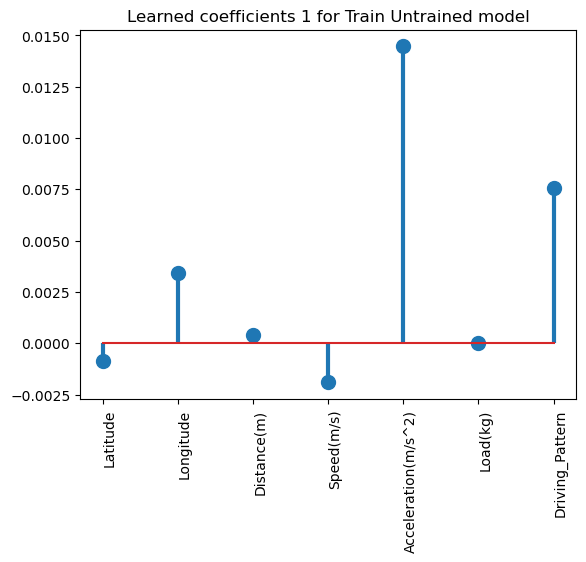

In [7]:
print("COEFFICIENT PLOT")
print("LENGTH OF COEF UNTRAINED 1 MODEL SHOULD BE 7 BEFORE PLOT:", len(lin_reg.coef_))


feature_names = list(df.columns)[:-1]
print()
print("Feature names:", feature_names)
print()
print("COEFFICIENTS:", list(lin_reg.coef_))
print()
coefs = list(lin_reg.coef_)


labels = feature_names             # Side note for myself .. if you want to use labels as the names not the actual x1, x2 x3 and so on....


fig, ax = plt.subplots()
markerline, stemlines, baseline = ax.stem(coefs)
plt.setp(stemlines, "linewidth", 3)
plt.setp(markerline, markersize = 10)
ax.set_xticks(np.arange(len(feature_names)), labels = labels)

plt.setp(ax.get_xticklabels(),                   # rotates the labels of the coefs
         rotation = 90,
         ha= "right",
         rotation_mode = "anchor")
plt.title("Learned coefficients 1 for Train Untrained model")
plt.show()

Here we can see that the coefficients of columns Distance, Load are almost 0 and the coefficients of the columns Latitude and Longitute are small. As we did not scale our features this coefficients of the features should not be "trusted", because in general small coefficients mean that these columns do not play a big role and large coefficients in general tell us that these features play a big role. As we mentioned the features are not scaled meaning there is a big difference between the magnitute of the features.

But if approaching naively we could say that the features Distance and Load do not play a big role, which would not be true because the Distance actually plays a role. However ,as we did EDA we know that Load does not affect anything that much and also Latitude and Longitute do not do anything, in fact they create a noise.



#### **Feature engineering** 

We will now replace some of the features with the log and square root of absolute value functions and see if this improve the performance.
Why we specifically chose the log function is because we did not have any other clear function to apply and the log function would be roughly reasonable to apply initially. We used here as well square root of absolute value because acceleration has both negative and positive values, so the absolute values make sure there is only a positive value and square root reduces the skewness of the data and lessen the impact of outliers. Extreme values are pulled in closer to the center, making the data more symmetric and easier to model with linear techniques.

But later on we will also do some more feature engineering with different functions such as the reciprocal, as the Professor Voigtlaender has suggested to us.

This approach of building new features from existing ones before training a model is called feature engineering. It is a very important part of machine learning.

Doing some feature engineering



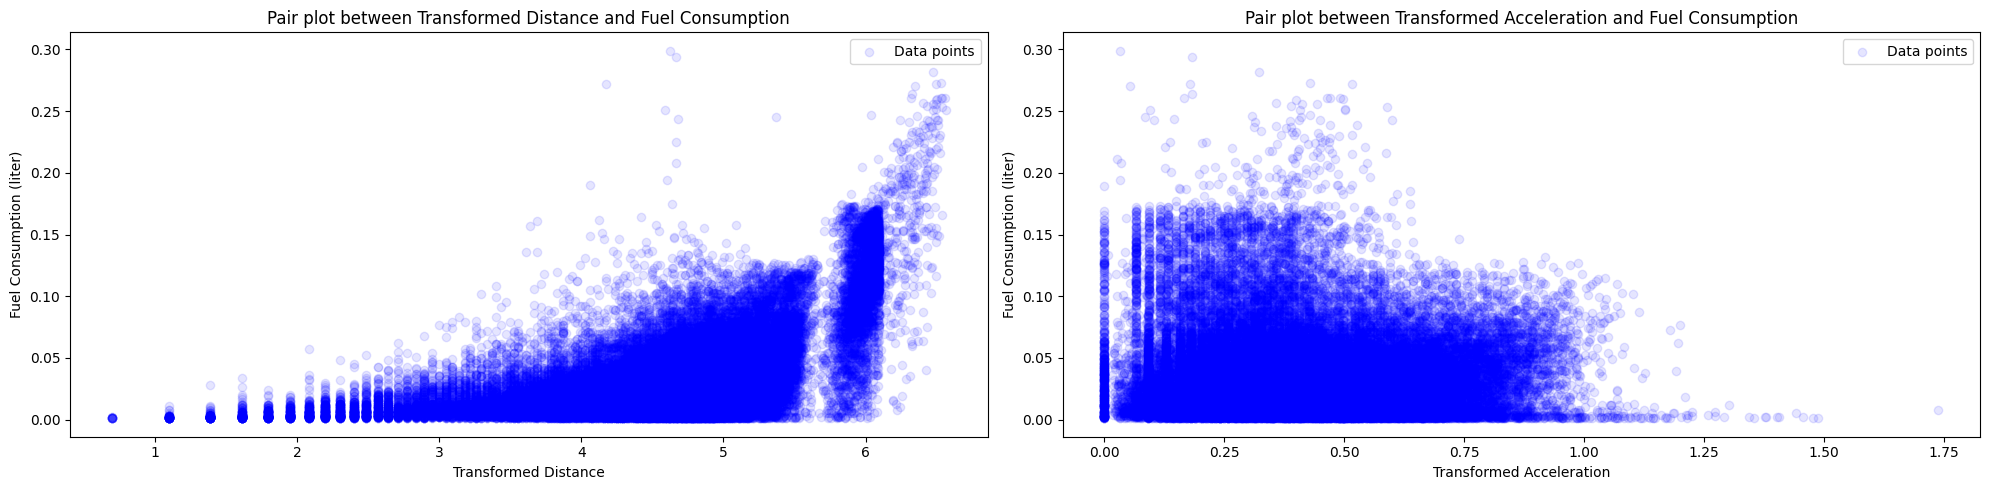

In [42]:
print("Doing some feature engineering")
print()

feature_df = df[["Latitude", "Longitude", "Load(kg)", "Driving_Pattern", "Speed(m/s)"]].copy()


# Apply transformations
feature_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
feature_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"])) # 

#!!!!!! WE AGAIN SPLIT THE DATA  !!!!!!!

x_train, x_test, y_train, y_test = train_test_split(feature_df, y, train_size=0.8, random_state= 42)



def plot_scatter(ax, x, y, xlabel, ylabel, title, color, marker):
    ax.scatter(x, y, label="Data points", color=color, marker=marker, alpha=0.1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

# List of transformed features to plot against Fuel_Consumption(liter)
transformed_features = ["Transformed Distance", "Transformed Acceleration"]
num_features = len(transformed_features)


num_rows = 1
num_cols = 2


fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5))  # 1x2 grid of subplots


axes = axes.flatten()


for i, feature in enumerate(transformed_features):
    plot_scatter(
        axes[i],
        feature_df[feature],
        df["Fuel_Consumption(liter)"],
        feature,
        "Fuel Consumption (liter)",
        f"Pair plot between {feature} and Fuel Consumption",
        "blue",
        "o"
    )

plt.tight_layout()
plt.show()


Here in the plot of the transformed new features, we can see more or less a change especially in transformed Acceleration, as it became only positive and it kind of has a negative "linear looking" relation, but this is approximately because this still is not even close to perfect relation. We can see also a lot of outliers above approximately 0.15 liters

#### **Simple linear regression with Feature Engineering**
We train again the model, now with the transformed features with feature engineering and we compute the MSE, RMSE, R^2

In [9]:

print("TRAIN THE FEATURE ENGINEERED MODEL")

from IPython.display import display

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
lin_reg.coef_
display(x_train.columns)


MSE_train = mean_squared_error(lin_reg.predict(x_train), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test, y_test))

TRAIN THE FEATURE ENGINEERED MODEL


Index(['Latitude', 'Longitude', 'Load(kg)', 'Driving_Pattern', 'Speed(m/s)',
       'Transformed Distance', 'Transformed Acceleration'],
      dtype='object')

MSE TRAIN: 0.0006915067615276702
RMSE TRAIN: 0.02629651614810734
R^2 SCORE TRAIN: 0.4375615207749769

MSE TEST: 0.0006828387168201635
RMSE TEST: 0.02613118284387761
R^2 SCORE TEST: 0.4330535730806999


We can see that our R^2 score has worsened on both train and test sets

Before doing anything else, we will try one more thing, we will drop the latitude and longitude columns and train again

#### **Simple linear regression with Feature Engineering + Dropped Latitude and Longitude**

In [49]:
print("TRAIN FEATURE ENGINEERED MODEL WITH DROPPED LAT AND LONG")
print()
feature_df = df[["Latitude", "Longitude", "Load(kg)", "Driving_Pattern", "Speed(m/s)"]].copy()



feature_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) 
feature_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"]))
feature_df.drop(["Latitude", "Longitude"], axis=1, inplace=True)
print()
print(feature_df.columns)


x_train, x_test, y_train, y_test = train_test_split(feature_df, y, train_size=0.8, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
lin_reg.coef_
display(x_train.columns)


MSE_train = mean_squared_error(lin_reg.predict(x_train), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test, y_test))
print()
print()
print("LENGTH OF COEF FEATURE DROPPED SHOULD BE 5 ALSO: ", len(lin_reg.coef_))


TRAIN FEATURE ENGINEERED MODEL WITH DROPPED LAT AND LONG


Index(['Load(kg)', 'Driving_Pattern', 'Speed(m/s)', 'Transformed Distance',
       'Transformed Acceleration'],
      dtype='object')


Index(['Load(kg)', 'Driving_Pattern', 'Speed(m/s)', 'Transformed Distance',
       'Transformed Acceleration'],
      dtype='object')

MSE TRAIN: 6.758497215743915e-25
RMSE TRAIN: 8.221007976972115e-13
R^2 SCORE TRAIN: 1.0

MSE TEST: 6.650546362114167e-25
RMSE TEST: 8.155088204375331e-13
R^2 SCORE TEST: 1.0


LENGTH OF COEF FEATURE DROPPED SHOULD BE 5 ALSO:  5


We can see that nothing has changed.

#### **Simple linear regression with Feature Engineering + Polynomial Features**

Here we demonstrate a simple linear regression model with feature engineering where we also apply a polynomial degree.

We still do not use the StandartScaler yet, even if it is always a must to scale the data considering that our data is variated in magnitude of the features, we want to demonstrate really detailed each scenario.

#### **- Polynomial degree 3 and dropped Latitude and Longitude**

In [50]:
print("TRAIN FEATURE ENGINEERED MODEL WITH DROPPED LAT AND LONG + POLYNOMIAL")
print()
print()


from sklearn.preprocessing import PolynomialFeatures


feature_df = df[["Latitude", "Longitude", "Load(kg)", "Driving_Pattern", "Speed(m/s)"]].copy()



feature_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
feature_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"]))
feature_df.drop(["Latitude", "Longitude"], axis=1, inplace=True)
y= df["Fuel_Consumption(liter)"]
print()
print()



# degree 3 gives 59,58 the best is degree 3, i have checked till degree 11 including, worse
poly_features = PolynomialFeatures(degree=3, include_bias=False)
poly_features.set_output(transform="pandas")  # this just tells scikit learn to output the results as a pandas DataFrame
fat_features = poly_features.fit_transform(feature_df)

x_train, x_test, y_train, y_test = train_test_split(fat_features, y, train_size=0.8, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
lin_reg.coef_
    




MSE_train = mean_squared_error(lin_reg.predict(x_train), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test, y_test))
print()


TRAIN FEATURE ENGINEERED MODEL WITH DROPPED LAT AND LONG + POLYNOMIAL




MSE TRAIN: 0.0005031935701685993
RMSE TRAIN: 0.022431976510521742
R^2 SCORE TRAIN: 0.5907264511250736

MSE TEST: 0.0005034853580227234
RMSE TEST: 0.02243847940531451
R^2 SCORE TEST: 0.5819668426734139



We see that we have improved the R^2 score to 58% using the polynomial feature, and we do not have any overfitting currently
We will try to improve our model's performance by trying out several scenarios.

Here we do exactly the same procedure but without dropping the columns Latitude and Longitude.

#### **- Polynomial degree 3**

In [51]:
print("TRAIN FEATURE ENGINEERED MODEL WITHOUT DROPPED LAT AND LONG + POLYNOMIAL")


from sklearn.preprocessing import PolynomialFeatures
feature_df = df[["Latitude", "Longitude", "Load(kg)", "Driving_Pattern", "Speed(m/s)"]].copy()



feature_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
feature_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"]))
y= df["Fuel_Consumption(liter)"]
print()
print()




# degree 4,5,6 give the same score 60,59, degree 8 gives 59,58 after degree 8 have not checked
poly_features = PolynomialFeatures(degree=4, include_bias=False)
poly_features.set_output(transform="pandas")  # this just tells scikit learn to output the results as a pandas DataFrame

fat_features = poly_features.fit_transform(feature_df)

x_train, x_test, y_train, y_test = train_test_split(fat_features, y, train_size=0.8, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
lin_reg.coef_
display(x_train.columns)


MSE_train = mean_squared_error(lin_reg.predict(x_train), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test, y_test))
print()




TRAIN FEATURE ENGINEERED MODEL WITHOUT DROPPED LAT AND LONG + POLYNOMIAL




Index(['Latitude', 'Longitude', 'Load(kg)', 'Driving_Pattern', 'Speed(m/s)',
       'Transformed Distance', 'Transformed Acceleration', 'Latitude^2',
       'Latitude Longitude', 'Latitude Load(kg)',
       ...
       'Speed(m/s)^2 Transformed Acceleration^2',
       'Speed(m/s) Transformed Distance^3',
       'Speed(m/s) Transformed Distance^2 Transformed Acceleration',
       'Speed(m/s) Transformed Distance Transformed Acceleration^2',
       'Speed(m/s) Transformed Acceleration^3', 'Transformed Distance^4',
       'Transformed Distance^3 Transformed Acceleration',
       'Transformed Distance^2 Transformed Acceleration^2',
       'Transformed Distance Transformed Acceleration^3',
       'Transformed Acceleration^4'],
      dtype='object', length=329)

MSE TRAIN: 0.0004897452143248597
RMSE TRAIN: 0.022130187851097417
R^2 SCORE TRAIN: 0.6016646996421522

MSE TEST: 0.0004903811350404634
RMSE TEST: 0.02214455091078759
R^2 SCORE TEST: 0.5928469996040917



Not too big of difference but still an improvement in testing accuracy by 1%

#### **Linear regression with Feature Engineering + Polynomial Features + Standard Scaler**

#### **- Polynomial degree 5**

We applied polynomial degree 5 as it was the best degree in this case, because we also checked with polynomial degree 2,3,4 which were worse.

In [13]:
print("TRAIN FEATURE ENGINEERED MODEL WITHOUT DROPPED LAT AND LONG + POLYNOMIAL + SCALER")

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
feature_df = df[["Latitude", "Longitude", "Load(kg)", "Driving_Pattern", "Speed(m/s)"]].copy()



feature_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
feature_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"]))
y= df["Fuel_Consumption(liter)"]
print()
print()
print(feature_df.columns)
# degree 5 gives 61,59 the best
# degree 6 gives 63,38
# degree 7 gives 64, -3
# degree 8 gives 66, -85
poly_features = PolynomialFeatures(degree=5, include_bias=False)
poly_features.set_output(transform="pandas")  # this just tells scikit learn to output the results as a pandas DataFrame

fat_features = poly_features.fit_transform(feature_df)

x_train, x_test, y_train, y_test = train_test_split(fat_features, y, train_size=0.8, random_state=42)



scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled_poly = scaler.transform(x_train)
x_test_scaled_poly = scaler.transform(x_test)

lin_reg = LinearRegression()
lin_reg.fit(x_train_scaled_poly, y_train)


MSE_train = mean_squared_error(lin_reg.predict(x_train_scaled_poly), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test_scaled_poly), y_test)


print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train_scaled_poly, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test_scaled_poly, y_test))
print()

TRAIN FEATURE ENGINEERED MODEL WITHOUT DROPPED LAT AND LONG + POLYNOMIAL + SCALER


Index(['Latitude', 'Longitude', 'Load(kg)', 'Driving_Pattern', 'Speed(m/s)',
       'Transformed Distance', 'Transformed Acceleration'],
      dtype='object')
MSE TRAIN: 0.00046958007926687495
RMSE TRAIN: 0.02166979647497583
R^2 SCORE TRAIN: 0.6180660546633588

MSE TEST: 0.0004931049924475682
RMSE TEST: 0.022205967496318826
R^2 SCORE TEST: 0.5905854388777358



We see that nothing has changed.

#### **- Polynomial degree 6 and dropped Latitude and Longitude**
Now we try with polynomial degree 6 and dropping latitude and longitude.



In [12]:
print("TRAIN FEATURE ENGINEERED MODEL WITH DROPPED LAT AND LONG + POLYNOMIAL + SCALER")

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
feature_df = df[["Latitude", "Longitude", "Load(kg)", "Driving_Pattern", "Speed(m/s)"]].copy()



feature_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
feature_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"]))
feature_df.drop(["Latitude", "Longitude"], axis=1, inplace=True)
y= df["Fuel_Consumption(liter)"]
print()
print()
print(feature_df.columns)

# degree 4,5 give 60,59
# degree 6 gives 61 59 the best
# degree 7 gives 61 57
# degree 8 gives 61 49
# degree 9 gives 62, -0.91
# degree 10 gives 63, -100
poly_features = PolynomialFeatures(degree=6, include_bias=False)
poly_features.set_output(transform="pandas")  # this just tells scikit learn to output the results as a pandas DataFrame

fat_features = poly_features.fit_transform(feature_df)

x_train, x_test, y_train, y_test = train_test_split(fat_features, y, train_size=0.8, random_state=42)



scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled_poly = scaler.transform(x_train)
x_test_scaled_poly = scaler.transform(x_test)

lin_reg = LinearRegression()
lin_reg.fit(x_train_scaled_poly, y_train)




MSE_train = mean_squared_error(lin_reg.predict(x_train_scaled_poly), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test_scaled_poly), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train_scaled_poly, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test_scaled_poly, y_test))
print()




TRAIN FEATURE ENGINEERED MODEL WITH DROPPED LAT AND LONG + POLYNOMIAL + SCALER


Index(['Load(kg)', 'Driving_Pattern', 'Speed(m/s)', 'Transformed Distance',
       'Transformed Acceleration'],
      dtype='object')
MSE TRAIN: 0.0004794452976243277
RMSE TRAIN: 0.02189623934890025
R^2 SCORE TRAIN: 0.6100421585586691

MSE TEST: 0.0004887047687405948
RMSE TEST: 0.022106667970107907
R^2 SCORE TEST: 0.5942388507989746



There is no overfitting.

There is no reason to increase the degree of the polynomial degree because it does not increase the training accuracy.
We should consider different approaches, maybe to add some more feature engineering.

In [13]:
print()
feature_names = list(df.columns)[:-1]
print("Our feature names:", feature_names)
print("SEE THE DATA WE ARE WORKING WITH BELOW:") # this is to make sure again how the data looks like
display(df.info())


Our feature names: ['Latitude', 'Longitude', 'Distance(m)', 'Speed(m/s)', 'Acceleration(m/s^2)', 'Load(kg)', 'Driving_Pattern']
SEE THE DATA WE ARE WORKING WITH BELOW:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46476 entries, 0 to 46475
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Latitude                 46476 non-null  float64
 1   Longitude                46476 non-null  float64
 2   Distance(m)              46476 non-null  int64  
 3   Speed(m/s)               46476 non-null  float64
 4   Acceleration(m/s^2)      46476 non-null  float64
 5   Load(kg)                 46476 non-null  float64
 6   Driving_Pattern          46476 non-null  int64  
 7   Fuel_Consumption(liter)  46476 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 2.8 MB


None

#### **Linear regression without Feature Engineering + Polynomial Features + Standard Scaler**
#### **- Polynomial degree 4**

This is the last linear regression model just to quickly see if we have a better performance without introducing new columns (without feature enginering).
Now we do Polynomial Features, then scale and then do LinearRegression.
Here we are doing this manually, not using pipelines.
Later we will also show this with ridge regression with we will do it correctly with pipelines.

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("POLYNOMIAL FEATURE + SCALED DATA + SIMPLE LINEAR REGRESSION")
print()

x = df.drop(["Fuel_Consumption(liter)"], axis=1)
y= df["Fuel_Consumption(liter)"]

poly = PolynomialFeatures(degree=4, include_bias=False)
poly_features = poly.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(poly_features, y, train_size=0.8, random_state=42)


scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled_poly = scaler.transform(x_train)
x_test_scaled_poly = scaler.transform(x_test)

lin_reg = LinearRegression()
lin_reg.fit(x_train_scaled_poly, y_train)




MSE_train = mean_squared_error(lin_reg.predict(x_train_scaled_poly), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test_scaled_poly), y_test)
MAE_train = mean_absolute_error(lin_reg.predict(x_train_scaled_poly), y_train)
MAE_test = mean_absolute_error(lin_reg.predict(x_test_scaled_poly), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R2 score TRAIN:", lin_reg.score(x_train_scaled_poly, y_train))
print("MAE Train:", MAE_train)

print()

print("'MSE test:", MSE_test)
print("RMSE test:", np.sqrt(MSE_test))
print("R2 score test:", lin_reg.score(x_test_scaled_poly, y_test))
print("MAE test:", MAE_test)

POLYNOMIAL FEATURE + SCALED DATA + SIMPLE LINEAR REGRESSION

MSE TRAIN: 0.00047633966357644026
RMSE TRAIN: 0.02182520706835196
R2 score TRAIN: 0.6125681325449023
MAE Train: 0.015993052936481775

'MSE test: 0.0004922210583118031
RMSE test: 0.022186055492398896
R2 score test: 0.5913193505431986
MAE test: 0.0161108636334174


Overall with polynomial degree up to degree 4 the model does not overfit, after degree 4 the model overfits.
Here with polynomial degree 4, scaled data and linear regression model, the R^2 score on training data is 61% and 59 % on testing data.

Summary of Linear Regression model, it does not seem to increase with Linear Regression model with both introduced new columns and also without feature engineering.

Also we can emphasise that there is no overfitting until degree 4.

What we can do here would start doing different models to see how well we can improve and also do some more feature engineering. We can also try to remove outliers to see if it makes better the performance of the model.

#### **Ridge regression with Polynomial Features + Standard Scaler (manual search for alpha hyperparameter)**

#### **Regularization (Ridge regression and Lasso)**

Remember, for a ridge regression model correct scaling of the features is very important. Therefore, in addition to Ridge class we also use StandardScaler.

First, we again define x and y and split the data.

After we scaled the features we want to train the ridge regression model.

For this, we need to specify the hyperparameter alpha using 5-fold cross validation to determine a good value for alpha.

Here we will not use GridSearch, and later we will do the same with GridSearch.

After finding the best hyperparameter one must train on the full training set and see the train and test scores

In [17]:
from IPython.display import display

x = df.drop(["Fuel_Consumption(liter)"], axis=1)
y= df["Fuel_Consumption(liter)"]

# DEGREE 2, BEST 0, 58
# DEGREE 3, BEST -3, 59
# DEGREE 4, BEST -4, 59
# DEGREE 5, BEST -2, 59
# DEGREE 6, BEST 1, 59
poly = PolynomialFeatures(degree=6, include_bias=False)
poly_features = poly.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(poly_features, y, train_size=0.8, random_state=42)

scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge


max_r2 = -np.inf 
best_expo = None

for expo in np.logspace(-5, 2, 30):
    ridge = Ridge(alpha= 10**expo)
    scores = cross_val_score(ridge,
                             x_train_scaled,
                             y_train,
                             cv=5)
    cv_r2 = np.mean(scores)
    if cv_r2 > max_r2:
        max_r2 = cv_r2
        best_expo = expo

    print(f"Mean cv_r2 for each expo{expo=}", cv_r2)
    print(f"Standart deviation cv_r2 {expo=}", np.std(scores))
    print()
print("The best CV R2 SCORE:", max_r2)
print("Best expo:", best_expo)

best_alpha = 10** best_expo
# Fit the Ridge model with the best alpha
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(x_train_scaled, y_train)


train_score = best_ridge.score(x_train_scaled, y_train)
test_score = best_ridge.score(x_test_scaled, y_test)

print("Train score:", train_score)
print("Test score:", test_score)


Mean cv_r2 for each expoexpo=1e-05 0.5947061590859837
Standart deviation cv_r2 expo=1e-05 0.013197046974081531

Mean cv_r2 for each expoexpo=1.7433288221999873e-05 0.5947062067498805
Standart deviation cv_r2 expo=1.7433288221999873e-05 0.013196969372127632

Mean cv_r2 for each expoexpo=3.039195382313195e-05 0.5947062898437606
Standart deviation cv_r2 expo=3.039195382313195e-05 0.01319683408458622

Mean cv_r2 for each expoexpo=5.2983169062837125e-05 0.5947064347016445
Standart deviation cv_r2 expo=5.2983169062837125e-05 0.013196598236693757

Mean cv_r2 for each expoexpo=9.236708571873866e-05 0.5947066872331035
Standart deviation cv_r2 expo=9.236708571873866e-05 0.013196187078471913

Mean cv_r2 for each expoexpo=0.0001610262027560939 0.594707127466155
Standart deviation cv_r2 expo=0.0001610262027560939 0.013195470303486567

Mean cv_r2 for each expoexpo=0.0002807216203941176 0.5947078949004355
Standart deviation cv_r2 expo=0.0002807216203941176 0.013194220755202345

Mean cv_r2 for each ex

Here while using ridge, we introduced degree 6 because in lesser degrees we do not have overfitting and there would be no point of doing ridge without having an overfitting, and as we can see with degree 6 , the best alpha hyperparameter is 10^ 0.6723357536499335 with the best cv score 59%.

As we mentioned one must always train on the full training set after tuning, we can see that we did not increase the performance of our model.
As degree 6 is already a lot, there is no point of increasing the degree further, rather we will demonstrate below more feature engineering with log transformations.



#### **More feature engineering**

1) Firstly we drop the features Latitude and Longitude.
2) Secondly we transform all the features except the driving pattern, using log functions, but adding 1 because log of 0 is undefined, so we do not want this to happen and also we transform the acceleration feature using the square root of absolute value as we explained earlier why.
3) Then we apply again the log transformation to the transformed features one more time to see if we can increase the performance.
4) We split the data one more time.
5) Take a look at the plot of the transformed features

Doing some feature engineering



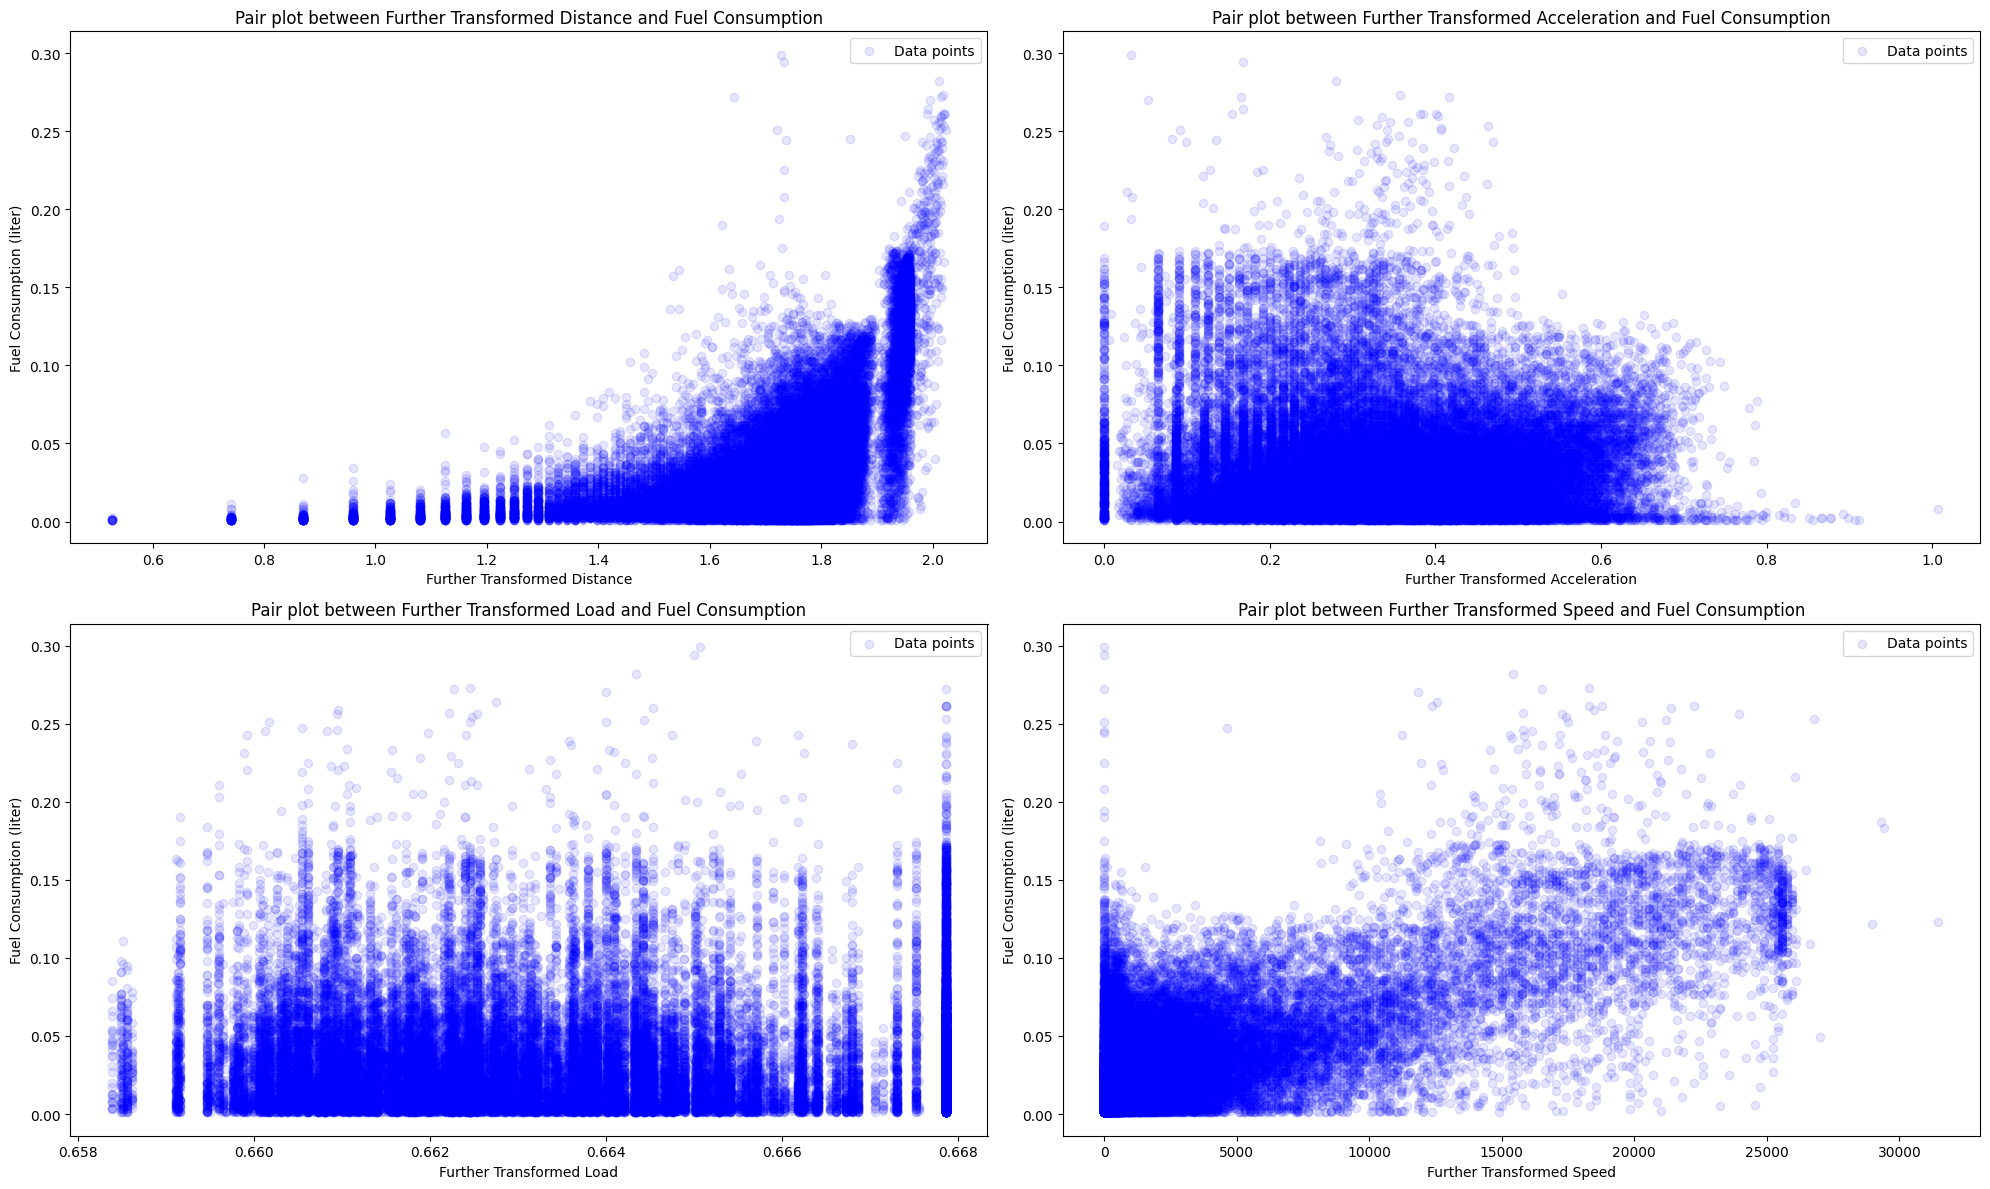

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46476 entries, 0 to 46475
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Driving_Pattern                   46476 non-null  int64  
 1   Further Transformed Distance      46476 non-null  float64
 2   Further Transformed Acceleration  46476 non-null  float64
 3   Further Transformed Load          46476 non-null  float64
 4   Further Transformed Speed         46476 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 1.8 MB
None


In [44]:
print("Doing some feature engineering")
print()

new_df = df[[ "Driving_Pattern"]].copy()




new_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"]))
new_df["Transformed Load"] = np.log(df["Load(kg)"] + 1) 
new_df["Transformed Speed"] = np.sqrt(df["Speed(m/s)"])


new_df["Further Transformed Distance"] = np.log(new_df["Transformed Distance"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df["Further Transformed Acceleration"] = np.log(new_df["Transformed Acceleration"] + 1)
new_df["Further Transformed Load"] = 1./np.sqrt((np.log(new_df["Transformed Load"] + 1)))
new_df["Further Transformed Speed"] = (new_df["Transformed Speed"])**6

new_df.drop(["Transformed Distance", "Transformed Acceleration", "Transformed Load", "Transformed Speed"], axis=1, inplace=True )




x_train, x_test, y_train, y_test = train_test_split(new_df, y, train_size=0.8, random_state= 42)



def plot_scatter(ax, x, y, xlabel, ylabel, title, color, marker):
    ax.scatter(x, y, label="Data points", color=color, marker=marker, alpha=0.1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()





# List of transformed features to plot against Fuel_Consumption(liter)
transformed_features = ["Further Transformed Distance", "Further Transformed Acceleration", "Further Transformed Load", "Further Transformed Speed"]
num_features = len(transformed_features)


num_rows = 2
num_cols = 2


fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 12))  # 1x2 grid of subplots


axes = axes.flatten()

# Plot each scatter plot in the grid
for i, feature in enumerate(transformed_features):
    plot_scatter(
        axes[i],
        new_df[feature],
        df["Fuel_Consumption(liter)"],
        feature,
        "Fuel Consumption (liter)",
        f"Pair plot between {feature} and Fuel Consumption",
        "blue",
        "o"
    )

plt.tight_layout()
plt.show()

print(new_df.info())

#### **Grid search**  


Rather than using cross_val_score function and searching the best parameters via a hand-coded loop, one can also use the GridSearchCV class in sklearn as shown below.

Note: Here we use the new transformed features for this model.

In [19]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

x_train, x_test, y_train, y_test = train_test_split(new_df, y, train_size=0.8, random_state= 42)



from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("poly", PolynomialFeatures(6, include_bias=False)),
                 ("scaler", StandardScaler()),
                 ("ridge", Ridge())])

alphas = [10**expo for expo in np.logspace(-5, 2, 15)]
param_grid = {"ridge__alpha": alphas}



grid = GridSearchCV(pipe, 
                    param_grid= param_grid, 
                    cv=5)

grid.fit(x_train, y_train)


print("Best CV Score", grid.best_score_)
print("Best Hyperparameter", grid.best_params_)




train_score = grid.best_estimator_.score(x_train, y_train)
test_score = grid.best_estimator_.score(x_test, y_test)

print("Train score:", train_score)
print("Test score:", test_score)





Best CV Score 0.5745173712465839
Best Hyperparameter {'ridge__alpha': 10.0}
Train score: 0.5830335715630754
Test score: 0.5782971071117332


We see that transforming the features did not affect anything, in the code below we will add all the features that we created and also keep the original features as well and use grid search one more time for Ridge.

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
new_df = df[[ "Driving_Pattern", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()




new_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"]))
new_df["Transformed Load"] = np.log(df["Load(kg)"] + 1) 
new_df["Transformed Speed"] = np.sqrt(df["Speed(m/s)"])


new_df["Further Transformed Distance"] = np.log(new_df["Transformed Distance"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df["Further Transformed Acceleration"] = np.log(new_df["Transformed Acceleration"] + 1)
new_df["Further Transformed Load"] = 1./np.sqrt((np.log(new_df["Transformed Load"] + 1)))
new_df["Further Transformed Speed"] = (new_df["Transformed Speed"])**6

x_train, x_test, y_train, y_test = train_test_split(new_df, y, train_size=0.8, random_state= 42)



from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("poly", PolynomialFeatures(3, include_bias=False)),
                 ("scaler", StandardScaler()),
                 ("ridge", Ridge())])

alphas = [10**expo for expo in np.logspace(-5, 2, 20)]
param_grid = {"ridge__alpha": alphas}



grid = GridSearchCV(pipe, 
                    param_grid= param_grid, 
                    cv=5)

grid.fit(x_train, y_train)


print("Best CV Score", grid.best_score_)
print("Best Hyperparameter", grid.best_params_)




train_score = grid.best_estimator_.score(x_train, y_train)
test_score = grid.best_estimator_.score(x_test, y_test)

print("Train score:", train_score)
print("Test score:", test_score)

Best CV Score 0.6063127299939517
Best Hyperparameter {'ridge__alpha': 1.0000230261160268}
Train score: 0.6100735152933936
Test score: 0.6056608489466119


We can see that after we added quite a lot of features with degree 3 polynomial, we have finally increased the testing score to 60%, we will as well try to remove outliers in this code and see how the model is doing with removed outliers.

Below we will demonstrate exactly the same model with removed outliers, and, hopefully we will see some difference, at least we can see if removing outliers would be a good choice or not.

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline



new_df = df[["Driving_Pattern", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()

new_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) # add 1 to avoid log(0)
new_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"]))
new_df["Transformed Load"] = np.log(df["Load(kg)"] + 1) 
new_df["Transformed Speed"] = np.sqrt(df["Speed(m/s)"])

new_df["Further Transformed Distance"] = np.log(new_df["Transformed Distance"] + 1) # add 1 to avoid log(0)
new_df["Further Transformed Acceleration"] = np.log(new_df["Transformed Acceleration"] + 1)
new_df["Further Transformed Load"] = 1./np.sqrt((np.log(new_df["Transformed Load"] + 1)))
new_df["Further Transformed Speed"] = (new_df["Transformed Speed"])**6

# Remove outliers using the IQR method
def remove_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

new_df_cleaned = remove_outliers(new_df)

# Align target variable 'y' with the cleaned dataframe
y = df.loc[new_df_cleaned.index, "Fuel_Consumption(liter)"]


x_train, x_test, y_train, y_test = train_test_split(new_df_cleaned, y, train_size=0.8, random_state=42)


pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])


alphas = [10**expo for expo in np.logspace(-5, 2, 20)]
param_grid = {"ridge__alpha": alphas}


grid = GridSearchCV(pipe, param_grid=param_grid, cv=5)


grid.fit(x_train, y_train)


print("Best CV Score:", grid.best_score_)
print("Best Hyperparameter:", grid.best_params_)


print("Test set score:", grid.score(x_test, y_test))


train_score = grid.best_estimator_.score(x_train, y_train)
test_score = grid.best_estimator_.score(x_test, y_test)

print("Train score:", train_score)
print("Test score:", test_score)


Best CV Score: 0.22139936621801093
Best Hyperparameter: {'ridge__alpha': 1.0000230261160268}
Test set score: 0.22030464800530358
Train score: 0.22843285896684817
Test score: 0.22030464800530358


We see that while removing the outliers of the new_df, we have worsened our model's performance, so maybe we should keep the outliers as it affects the model too much.

#### **Lasso**

We use the same columns to find the best alpha for Lasso, let's check if this will make our model better.

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso

new_df = df[["Driving_Pattern", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()


new_df["Transformed Distance"] = np.log(df["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df["Transformed Acceleration"] = np.sqrt(np.abs(df["Acceleration(m/s^2)"]))
new_df["Transformed Load"] = np.log(df["Load(kg)"] + 1) 
new_df["Transformed Speed"] = np.sqrt(df["Speed(m/s)"])


new_df["Further Transformed Distance"] = np.log(new_df["Transformed Distance"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df["Further Transformed Acceleration"] = np.log(new_df["Transformed Acceleration"] + 1)
new_df["Further Transformed Load"] = 1./np.sqrt((np.log(new_df["Transformed Load"] + 1)))
new_df["Further Transformed Speed"] = (new_df["Transformed Speed"])**6


y= df["Fuel_Consumption(liter)"]

x_train, x_test, y_train, y_test = train_test_split(new_df, y, train_size=0.8, random_state= 42)



from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("poly", PolynomialFeatures(2, include_bias=False)),
                 ("scaler", StandardScaler()),
                 ("lasso", Lasso(max_iter=200_000))])

alphas = [10**expo for expo in [-4,-3,-2,-1]]
param_grid = {"lasso__alpha": alphas}



grid = GridSearchCV(pipe, 
                    param_grid= param_grid, 
                    cv=5)

grid.fit(x_train, y_train)




print("Best CV Score", grid.best_score_)
print("Best Hyperparameter", grid.best_params_)




train_score = grid.best_estimator_.score(x_train, y_train)
test_score = grid.best_estimator_.score(x_test, y_test)

print("Train score:", train_score)
print("Test score:", test_score)


Best CV Score 0.5913378470957035
Best Hyperparameter {'lasso__alpha': 0.0001}
Train score: 0.5921558035266502
Test score: 0.58781486337263


Lasso without the transformed features.

In [23]:
import sklearn
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np


x = df.drop(["Fuel_Consumption(liter)"], axis=1)
y= df["Fuel_Consumption(liter)"]


x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state= 42)



from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("poly", PolynomialFeatures(2, include_bias=False)),
                 ("scaler", StandardScaler()),
                 ("lasso", Lasso(max_iter=200_000))])

alphas = [10**expo for expo in [-5,-4,-3,-2,-1,0,1]]
param_grid = {"lasso__alpha": alphas}



grid = GridSearchCV(pipe, 
                    param_grid= param_grid, 
                    cv=5)

grid.fit(x_train, y_train)





print("Best CV Score", grid.best_score_)
print("Best Hyperparameter", grid.best_params_)


train_score = grid.best_estimator_.score(x_train, y_train)
test_score = grid.best_estimator_.score(x_test, y_test)

print("Train score:", train_score)
print("Test score:", test_score)


Best CV Score 0.5855419698070324
Best Hyperparameter {'lasso__alpha': 1e-05}
Train score: 0.5864853151438925
Test score: 0.5821747315703807


1) Best CV Score 0.5855419698070324
2) Best Hyperparameter {'lasso__alpha': 1e-05}
3) Train score: 0.5864853151438925
4) Test score: 0.5821747315703809

Lasso did not seem to improve also.

#### **Professor Voigtlaender's advise and hint**

As our models performance does not seem to increase , we were advised to introduce Distance_Speed_Quotient and Speed_Distance_Quotient, and try out with these features.

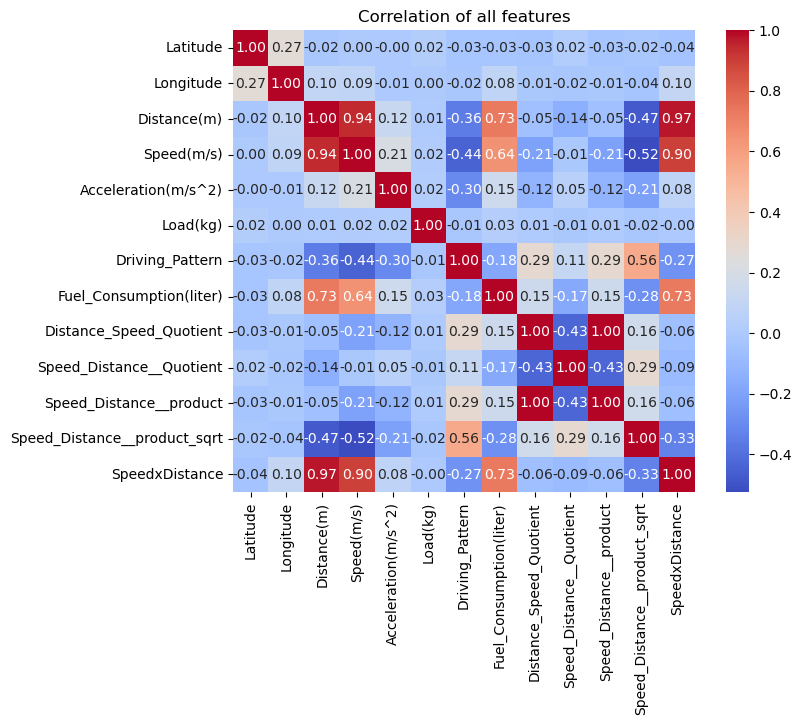

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46476 entries, 0 to 46475
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Latitude                      46476 non-null  float64
 1   Longitude                     46476 non-null  float64
 2   Distance(m)                   46476 non-null  int64  
 3   Speed(m/s)                    46476 non-null  float64
 4   Acceleration(m/s^2)           46476 non-null  float64
 5   Load(kg)                      46476 non-null  float64
 6   Driving_Pattern               46476 non-null  int64  
 7   Fuel_Consumption(liter)       46476 non-null  float64
 8   Distance_Speed_Quotient       46476 non-null  float64
 9   Speed_Distance__Quotient      46476 non-null  float64
 10  Speed_Distance__product       46476 non-null  float64
 11  Speed_Distance__product_sqrt  46476 non-null  float64
 12  SpeedxDistance                46476 non-null  float64
dtypes

c:\Users\anar1\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.269e+00, tolerance: 4.586e-03
  model = cd_fast.enet_coordinate_descent(


Best parameters found for Lasso:  {'lasso__alpha': 1e-07}
Best cross-validation score for Lasso:  0.6065812821789951
Lasso Regression test score:  0.583820872165231
Decision Tree with Polynomial Features test score:  0.5660063585125246


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

newdf = df.copy()


newdf['Distance_Speed_Quotient'] = newdf['Distance(m)'] / newdf['Speed(m/s)']
newdf['Speed_Distance__Quotient'] = newdf['Speed(m/s)'] / newdf['Distance(m)']
newdf['Speed_Distance__product'] = 1./ (newdf['Speed(m/s)']) * (newdf['Distance(m)'])
newdf['Speed_Distance__product_sqrt'] = 1./ np.sqrt((newdf['Speed(m/s)']) * (newdf['Distance(m)']))


newdf['SpeedxDistance'] = newdf['Distance(m)'] * newdf['Speed(m/s)']

newdf.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinite values with NaN
newdf.dropna(subset=['Distance_Speed_Quotient'], inplace=True)  # Drop rows with NaN values in the new feature

columns = newdf.columns
correlation_matrix = newdf[columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation of all features')
plt.show()





print(newdf.info())

x = newdf.drop(["Fuel_Consumption(liter)", "Latitude", "Longitude", "Load(kg)"], axis=1)
y = newdf["Fuel_Consumption(liter)"]


x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, stratify=newdf["Driving_Pattern"], random_state=42)



lin_reg_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

lin_reg_pipeline.fit(x_train, y_train)
y_pred_lin_reg = lin_reg_pipeline.predict(x_test)
print("Linear Regression with Polynomial Features test score: ", r2_score(y_test, y_pred_lin_reg))


ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid_ridge = {
    'ridge__alpha': [0.0001, 0.001, 0.1, 1, 10, 100,1000,1500]
}


grid_search_ridge = GridSearchCV(estimator=ridge_pipeline, param_grid=param_grid_ridge, cv=3, n_jobs=-1, scoring='r2')


grid_search_ridge.fit(x_train, y_train)


print("Best parameters found for Ridge: ", grid_search_ridge.best_params_)
print("Best cross-validation score for Ridge: ", grid_search_ridge.best_score_)


best_ridge = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(x_test)
print("Ridge Regression test score: ", r2_score(y_test, y_pred_ridge))


lasso_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=100000))
])


param_grid_lasso = {
    'lasso__alpha': [0.0000001, 0.000001, 0.00001, 0.0001, 0.1,0]
}


grid_search_lasso = GridSearchCV(estimator=lasso_pipeline, param_grid=param_grid_lasso, cv=3, n_jobs=-1, scoring='r2')


grid_search_lasso.fit(x_train, y_train)


print("Best parameters found for Lasso: ", grid_search_lasso.best_params_)
print("Best cross-validation score for Lasso: ", grid_search_lasso.best_score_)


best_lasso = grid_search_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(x_test)
print("Lasso Regression test score: ", r2_score(y_test, y_pred_lasso))

# Decision Tree Regressor
tree_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('tree', DecisionTreeRegressor(max_depth=8, min_samples_split=10, min_samples_leaf=5, max_features='sqrt', random_state=42))
])

tree_pipeline.fit(x_train, y_train)
y_pred_tree = tree_pipeline.predict(x_test)
print("Decision Tree with Polynomial Features test score: ", r2_score(y_test, y_pred_tree))



- Linear Regression with Polynomial Features test score:  0.5840052314032187
- Best parameters found for Ridge:  {'ridge__alpha': 1000}
- Best cross-validation score for Ridge:  0.6070350602726016
- Ridge Regression test score:  0.5842379927664769


- Best parameters found for Lasso:  {'lasso__alpha': 1e-07}
- Best cross-validation score for Lasso:  0.6060987674464972
- Lasso Regression test score:  0.5832779856145557
- Decision Tree with Polynomial Features test score:  0.5660063585125246

#### **Trying out several models with removed outliers**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)


df = pd.concat([df1, df2], ignore_index=True)
df.drop(["Id"], axis=1, inplace=True)


newdf = df.copy()


newdf['Distance_Speed_Quotient'] = newdf['Distance(m)'] / newdf['Speed(m/s)']
newdf.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinite values with NaN
newdf.dropna(subset=['Distance_Speed_Quotient'], inplace=True)  # Drop rows with NaN values in the new feature

# Create additional features
newdf['Speed_Squared'] = newdf['Speed(m/s)'] ** 2
newdf['Log_Distance'] = np.log1p(newdf['Distance(m)'])
newdf['Speed_Acceleration_Product'] = newdf['Speed(m/s)'] * newdf['Acceleration(m/s^2)']
newdf['Reciprocal of Speed'] = 1./newdf['Speed(m/s)']
newdf['Reciprocal of Acceleration'] = 1./newdf['Acceleration(m/s^2)']
newdf['Reciprocal of Distance'] = 1./newdf['Distance(m)']

# Add sin and cos functions
newdf['SIN of Speed'] = np.sin(newdf['Speed(m/s)'])
newdf['SIN of Acceleration'] = np.sin(newdf['Acceleration(m/s^2)'])
newdf['SIN of Distance'] = np.sin(newdf['Distance(m)'])

# Add reciprocal product
newdf['Reciprocal product of Speed and distance'] = 1./(newdf['Speed(m/s)'] * newdf['Distance(m)'])
newdf['Reciprocal of speed and acceleration'] = 1./(newdf['Speed(m/s)'] * newdf['Acceleration(m/s^2)'])
newdf['Reciprocal of distance and acceleration'] = 1./(newdf['Distance(m)'] * newdf['Acceleration(m/s^2)'])

# Remove infinite values and NaNs
newdf.replace([np.inf, -np.inf], np.nan, inplace=True)
newdf.dropna(inplace=True)

# Select specific features for outlier removal
features_to_check = ['Distance(m)', 'Speed(m/s)', 'Distance_Speed_Quotient', 'Speed_Squared', 'Log_Distance', 'Speed_Acceleration_Product', 'Reciprocal of Speed', 'Reciprocal of Acceleration', 'Reciprocal of Distance']

# Calculate IQR for the specific features
Q1 = newdf[features_to_check].quantile(0.25)
Q3 = newdf[features_to_check].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR



outliers = ((newdf[features_to_check] < lower_bound) | (newdf[features_to_check] > upper_bound))

# Remove outliers
newdf_no_outliers = newdf[~outliers.any(axis=1)]



x = newdf_no_outliers.drop(["Fuel_Consumption(liter)", "Latitude", "Longitude"], axis=1)
y = newdf_no_outliers["Fuel_Consumption(liter)"]


stratify_column = newdf_no_outliers["Driving_Pattern"]

# Split the cleaned dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.9, stratify=stratify_column, shuffle=True, random_state=44)

# function to evaluate models
def evaluate_model(x_train, x_test, y_train, y_test, model_pipeline):
    model_pipeline.fit(x_train, y_train)
    y_train_pred = model_pipeline.predict(x_train)
    y_test_pred = model_pipeline.predict(x_test)
    train_score = r2_score(y_train, y_train_pred)
    test_score = r2_score(y_test, y_test_pred)
    return train_score, test_score

# function to run experiments
def run_experiments(x, y, stratify_col, description):
    x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.9, random_state=44, stratify=stratify_col, shuffle=True)

    
    lr_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=1)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    lr_train_score, lr_test_score = evaluate_model(x_train, x_test, y_train, y_test, lr_pipeline)

    
    ridge_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1))
    ])
    ridge_train_score, ridge_test_score = evaluate_model(x_train, x_test, y_train, y_test, ridge_pipeline)

    
    lasso_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=0.00001, max_iter=10000))
    ])
    lasso_train_score, lasso_test_score = evaluate_model(x_train, x_test, y_train, y_test, lasso_pipeline)

    
    dt_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('scaler', StandardScaler()),
        ('tree', DecisionTreeRegressor(max_depth=None, min_samples_split=10, min_samples_leaf=5, max_leaf_nodes=50, random_state=44))
    ])
    dt_train_score, dt_test_score = evaluate_model(x_train, x_test, y_train, y_test, dt_pipeline)

    
    rf_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('scaler', StandardScaler()),
        ('rf', RandomForestRegressor(n_estimators=300, max_depth=30, max_features=7, min_samples_leaf=5, min_samples_split=10, random_state=44, bootstrap=False))
    ])
    rf_train_score, rf_test_score = evaluate_model(x_train, x_test, y_train, y_test, rf_pipeline)

    
    knn_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=1)),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=2))
    ])
    knn_train_score, knn_test_score = evaluate_model(x_train, x_test, y_train, y_test, knn_pipeline)

    print(f"Results for {description}:")
    print(f"Linear Regression with Polynomial Features train score: {lr_train_score}, test score: {lr_test_score}")
    print(f"Ridge Regression with Polynomial Features train score: {ridge_train_score}, test score: {ridge_test_score}")
    print(f"Lasso Regression with Polynomial Features train score: {lasso_train_score}, test score: {lasso_test_score}")
    print(f"Decision Tree with Polynomial Features train score: {dt_train_score}, test score: {dt_test_score}")
    print(f"Random Forest with Polynomial Features train score: {rf_train_score}, test score: {rf_test_score}")
    print(f"KNN Regression with Polynomial Features train score: {knn_train_score}, test score: {knn_test_score}")
    print()

# Run on the dataset without outliers
run_experiments(x, y, stratify_column, "Data Without Outliers")

# Run n the original dataset (with outliers)
x_orig = newdf.drop(["Fuel_Consumption(liter)", "Latitude", "Longitude"], axis=1)
y_orig = newdf["Fuel_Consumption(liter)"]
stratify_orig = newdf["Driving_Pattern"]
run_experiments(x_orig, y_orig, stratify_orig, "Original Data")





Exception in thread Thread-50 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\anar1\anaconda3\Lib\threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "c:\Users\anar1\anaconda3\Lib\threading.py", line 975, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\anar1\anaconda3\Lib\subprocess.py", line 1597, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 3: invalid start byte
c:\Users\anar1\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\anar1\anaconda3\Lib\site-packages\joblib\externals\

Results for Data Without Outliers:
Linear Regression with Polynomial Features train score: 0.47017121281502516, test score: 0.48310447580424565
Ridge Regression with Polynomial Features train score: 0.4779729985483181, test score: 0.4889115695465357
Lasso Regression with Polynomial Features train score: 0.4756000464837914, test score: 0.4885852858088412
Decision Tree with Polynomial Features train score: 0.4891467949185546, test score: 0.48013431302455034
Random Forest with Polynomial Features train score: 0.8228028369255226, test score: 0.4456872801247984
KNN Regression with Polynomial Features train score: 0.7409872903628395, test score: 0.24816571704986934

Results for Original Data:
Linear Regression with Polynomial Features train score: 0.5956806859262808, test score: 0.5830456078126498
Ridge Regression with Polynomial Features train score: 0.6073328388762006, test score: 0.592815995654171
Lasso Regression with Polynomial Features train score: 0.6049765442184243, test score: 0.592

Results for Data Without Outliers:

- Linear Regression with Polynomial Features train score: 0.47017121281502516, test score: 0.48310447580424565
- Ridge Regression with Polynomial Features train score: 0.4779729985483181, test score: 0.4889115695465357
- Lasso Regression with Polynomial Features train score: 0.4756000464837914, test score: 0.4885852858088412
- Decision Tree with Polynomial Features train score: 0.4891467949185546, test score: 0.48013431302455034
- Random Forest with Polynomial Features train score: 0.8228028369255226, test score: 0.4456872801247984
- KNN Regression with Polynomial Features train score: 0.7409872903628395, test score: 0.24816571704986934

Results for Original Data:

- Linear Regression with Polynomial Features train score: 0.5956806859262808, test score: 0.5830456078126498
- Ridge Regression with Polynomial Features train score: 0.6073328388762006, test score: 0.592815995654171
- Lasso Regression with Polynomial Features train score: 0.6049765442184243, test score: 0.5921153290902144
- Decision Tree with Polynomial Features train score: 0.6129824807696969, test score: 0.5804992087933423
- Random Forest with Polynomial Features train score: 0.8656707071355574, test score: 0.5541072626649302
- KNN Regression with Polynomial Features train score: 0.8068999825028644, test score: 0.3803320862719376



For this phase we stopped here and did not improve further because in approach 2 we will demonstrate with the original split data sets.

#### **Plotting the outliers**

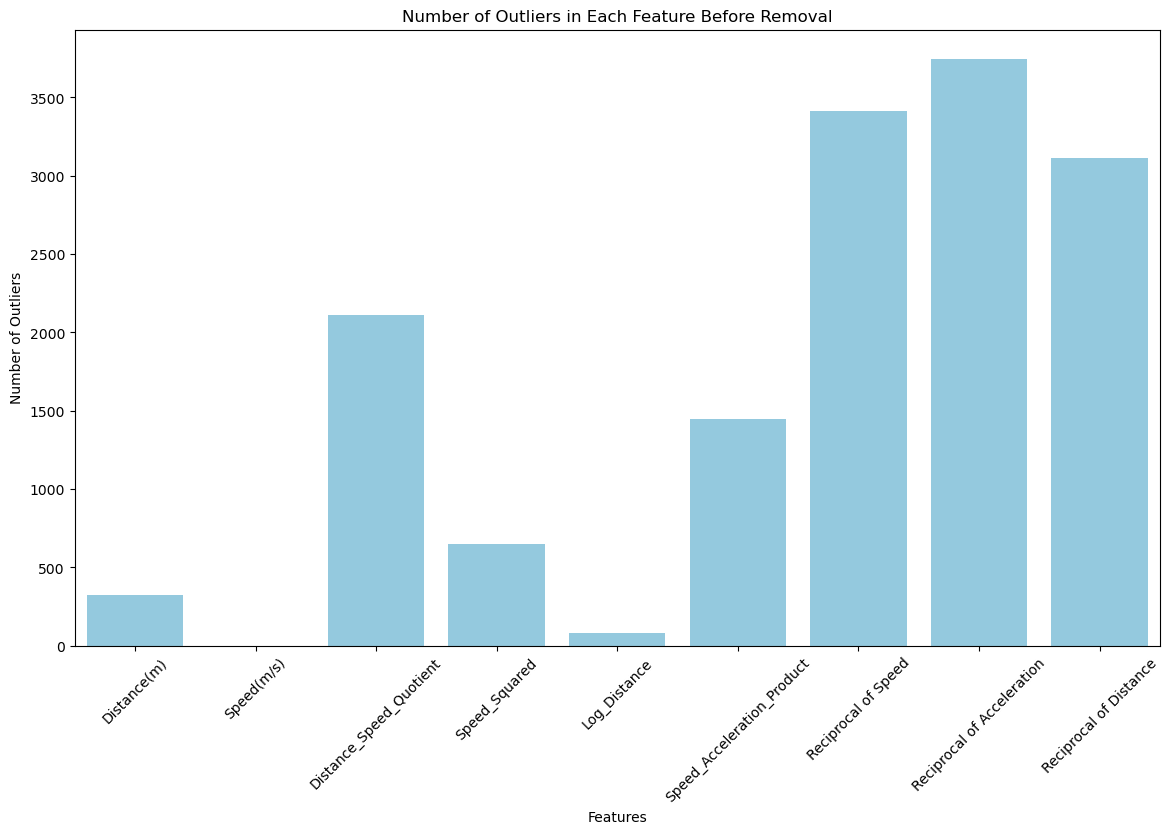

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)


df = pd.concat([df1, df2], ignore_index=True)
df.drop(["Id"], axis=1, inplace=True)


newdf = df.copy()


newdf['Distance_Speed_Quotient'] = newdf['Distance(m)'] / newdf['Speed(m/s)']
newdf.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinite values with NaN
newdf.dropna(subset=['Distance_Speed_Quotient'], inplace=True)  # Drop rows with NaN values in the new feature


newdf['Speed_Squared'] = newdf['Speed(m/s)'] ** 2
newdf['Log_Distance'] = np.log1p(newdf['Distance(m)'])
newdf['Speed_Acceleration_Product'] = newdf['Speed(m/s)'] * newdf['Acceleration(m/s^2)']
newdf['Reciprocal of Speed'] = 1./newdf['Speed(m/s)']
newdf['Reciprocal of Acceleration'] = 1./newdf['Acceleration(m/s^2)']
newdf['Reciprocal of Distance'] = 1./newdf['Distance(m)']


newdf['SIN of Speed'] = np.sin(newdf['Speed(m/s)'])
newdf['SIN of Acceleration'] = np.sin(newdf['Acceleration(m/s^2)'])
newdf['SIN of Distance'] = np.sin(newdf['Distance(m)'])


newdf['Reciprocal product of Speed and distance'] = 1./(newdf['Speed(m/s)'] * newdf['Distance(m)'])
newdf['Reciprocal of speed and acceleration'] = 1./(newdf['Speed(m/s)'] * newdf['Acceleration(m/s^2)'])
newdf['Reciprocal of distance and acceleration'] = 1./(newdf['Distance(m)'] * newdf['Acceleration(m/s^2)'])


newdf.replace([np.inf, -np.inf], np.nan, inplace=True)
newdf.dropna(inplace=True)


features_to_check = ['Distance(m)', 'Speed(m/s)', 'Distance_Speed_Quotient', 'Speed_Squared', 'Log_Distance', 'Speed_Acceleration_Product', 'Reciprocal of Speed', 'Reciprocal of Acceleration', 'Reciprocal of Distance']


Q1 = newdf[features_to_check].quantile(0.25)
Q3 = newdf[features_to_check].quantile(0.75)
IQR = Q3 - Q1

# Adjust the IQR threshold to be less aggressive
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR


outliers = ((newdf[features_to_check] < lower_bound) | (newdf[features_to_check] > upper_bound))

# Count number of outliers for each feature before removal
num_outliers_before = outliers.sum()

# Create a dataframe for plotting
outlier_counts_before = pd.DataFrame({
    'Feature': num_outliers_before.index,
    'Number of Outliers': num_outliers_before.values
})


plt.figure(figsize=(14, 8))
sns.barplot(x='Feature', y='Number of Outliers', data=outlier_counts_before, color='skyblue')
plt.title('Number of Outliers in Each Feature Before Removal')
plt.xlabel('Features')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=45)
plt.show()


### **Approach 2**

In this approach we will stick to the original training and testing csv files, which were already separated and we hope to see some better results with the original split version.



In [28]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
import numpy as np


df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(columns=["Fuel_Consumption(liter)"])
y_train = df1["Fuel_Consumption(liter)"]

x_test = df2.drop(columns=["Fuel_Consumption(liter)"])
y_test = df2["Fuel_Consumption(liter)"]
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)


## we now compute the MSE, RMSE, and R^2
## we evaluate the performance of our model

from sklearn.metrics import mean_squared_error

MSE_train = mean_squared_error(lin_reg.predict(x_train), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test, y_test))

MSE TRAIN: 0.0005154317149306892
RMSE TRAIN: 0.02270312125965699
R^2 SCORE TRAIN: 0.5361770441675138

MSE TEST: 0.0006292616063753325
RMSE TEST: 0.025085087330430654
R^2 SCORE TEST: 0.6287892511452318


The output:

MSE TRAIN: 0.0005154317149306892

RMSE TRAIN: 0.02270312125965699

R^2 SCORE TRAIN: 0.5361770441675138


MSE TEST: 0.0006292616063753325

RMSE TEST: 0.025085087330430654

R^2 SCORE TEST: 0.6287892511452318

Here we can see that the train score is less than the test score, as you can notice in the approach 1 with Trained Untrained model we had a train score 56% and a test score of 55%, but with the original separated files now the test score is performing way better than the training score. It might be because it is splitted that way, so it would be easier to predict the test set, and also it might be because there are a lot of outliers in training data, which are not present in the testing data. 

Simple linear regression is doing way better than it used to do in approach 1 with manual separation version. We see that there is no overfitting, we will directly proceed to the next try out below.

#### **Linear regression with Polynomial Features + Standard Scaler**

In the code below we will directly use standard scaler and polynomial feature up to degree 3 to see how well the model is doing.

Very important, we dropped the Latitude and Longitude columns and we will be working from now on with only dropped Latitude and Longitude columns.

In [29]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(columns=["Fuel_Consumption(liter)", "Latitude", "Longitude"])
y_train = df1["Fuel_Consumption(liter)"]

x_test = df2.drop(columns=["Fuel_Consumption(liter)", "Latitude", "Longitude"])
y_test = df2["Fuel_Consumption(liter)"]

poly = PolynomialFeatures(degree=5, include_bias=False)
poly_features_train = poly.fit_transform(x_train)
poly_features_test = poly.fit_transform(x_test)



scaler = StandardScaler()
scaler.fit(poly_features_train)

x_train_scaled_poly = scaler.transform(poly_features_train)
x_test_scaled_poly = scaler.transform(poly_features_test)

lin_reg = LinearRegression()
lin_reg.fit(x_train_scaled_poly, y_train)






from sklearn.metrics import mean_squared_error

MSE_train = mean_squared_error(lin_reg.predict(x_train_scaled_poly), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test_scaled_poly), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train_scaled_poly, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test_scaled_poly, y_test))

MSE TRAIN: 0.00046033850366720687
RMSE TRAIN: 0.021455500545715704
R^2 SCORE TRAIN: 0.5857539238090164

MSE TEST: 0.0005730422877003352
RMSE TEST: 0.02393830168788787
R^2 SCORE TEST: 0.6619538605445898


MSE TRAIN: 0.00046033850366721625
RMSE TRAIN: 0.021455500545715923
R^2 SCORE TRAIN: 0.5857539238090079

MSE TEST: 0.0005730422877001529
RMSE TEST: 0.02393830168788406
R^2 SCORE TEST: 0.6619538605446975

With degree 5 we made our performance better to 66% but the RMSE is still not good, so, we will directly proceed to feature engineering try with feature engineering, see if there is any change, then directly try ridge and lasso as well.

#### **Feature engineering**

In [30]:

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)
x_train = df1.drop(columns=["Fuel_Consumption(liter)", "Latitude", "Longitude"])
y_train = df1["Fuel_Consumption(liter)"]

x_test = df2.drop(columns=["Fuel_Consumption(liter)", "Latitude", "Longitude"])
y_test = df2["Fuel_Consumption(liter)"]

new_df1 = df1[[ "Driving_Pattern", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()




new_df1["Transformed Distance"] = np.log(df1["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df1["Transformed Acceleration"] = np.sqrt(np.abs(df1["Acceleration(m/s^2)"]))
new_df1["Transformed Load"] = np.log(df1["Load(kg)"] + 1) 
new_df1["Transformed Speed"] = np.sqrt(df1["Speed(m/s)"])


new_df1["Further Transformed Distance"] = np.log(new_df1["Transformed Distance"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df1["Further Transformed Acceleration"] = np.log(new_df1["Transformed Acceleration"] + 1)
new_df1["Further Transformed Load"] = 1./np.sqrt((np.log(new_df1["Transformed Load"] + 1)))
new_df1["Further Transformed Speed"] = (new_df1["Transformed Speed"])**6




new_df2 = df2[[ "Driving_Pattern", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()


new_df2["Transformed Distance"] = np.log(df2["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df2["Transformed Acceleration"] = np.sqrt(np.abs(df2["Acceleration(m/s^2)"]))
new_df2["Transformed Load"] = np.log(df2["Load(kg)"] + 1) 
new_df2["Transformed Speed"] = np.sqrt(df2["Speed(m/s)"])


new_df2["Further Transformed Distance"] = np.log(new_df2["Transformed Distance"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df2["Further Transformed Acceleration"] = np.log(new_df2["Transformed Acceleration"] + 1)
new_df2["Further Transformed Load"] = 1./np.sqrt((np.log(new_df2["Transformed Load"] + 1)))
new_df2["Further Transformed Speed"] = (new_df2["Transformed Speed"])**6




poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_features.set_output(transform="pandas")  # this just tells scikit learn to output the results as a pandas DataFrame

fat_features_train = poly_features.fit_transform(new_df1)
fat_features_test = poly_features.fit_transform(new_df2)





scaler = StandardScaler()
scaler.fit(fat_features_train)

x_train_scaled_poly = scaler.transform(fat_features_train)
x_test_scaled_poly = scaler.transform(fat_features_test)

lin_reg = LinearRegression()
lin_reg.fit(x_train_scaled_poly, y_train)




MSE_train = mean_squared_error(lin_reg.predict(x_train_scaled_poly), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test_scaled_poly), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train_scaled_poly, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test_scaled_poly, y_test))
print()
print(new_df1.info())
print(new_df2.info())

MSE TRAIN: 0.00046102094700498715
RMSE TRAIN: 0.021471398347685397
R^2 SCORE TRAIN: 0.5851398116444981

MSE TEST: 0.0005634315852997685
RMSE TEST: 0.023736713869020886
R^2 SCORE TEST: 0.667623356345684

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38004 entries, 0 to 38003
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Driving_Pattern                   38004 non-null  int64  
 1   Speed(m/s)                        38004 non-null  float64
 2   Distance(m)                       38004 non-null  int64  
 3   Acceleration(m/s^2)               38004 non-null  float64
 4   Load(kg)                          38004 non-null  float64
 5   Transformed Distance              38004 non-null  float64
 6   Transformed Acceleration          38004 non-null  float64
 7   Transformed Load                  38004 non-null  float64
 8   Transformed Speed                 38004 non-null  flo

- MSE TRAIN: 0.0004610143714441571
- RMSE TRAIN: 0.02147124522341816
- R^2 SCORE TRAIN: 0.5851457288125188

- MSE TEST: 0.0005634416313882412
- RMSE TEST: 0.02373692548305785
- R^2 SCORE TEST: 0.6676174300091855



As we can see we did not improve too much.

We will try to add reciprocal of columns Distance, Acceleration and Speed and see what happens.

In [31]:

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)

y_train = df1["Fuel_Consumption(liter)"]


y_test = df2["Fuel_Consumption(liter)"]

new_df1 = df1[[ "Driving_Pattern", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()


new_df1["Distance(m)"].replace(0, np.nan, inplace=True)
new_df1["Speed(m/s)"].replace(0, np.nan, inplace=True)
new_df1["Acceleration(m/s^2)"].replace(0, np.nan, inplace=True)

new_df1.replace([np.inf, -np.inf], np.nan, inplace=True)

imputer = SimpleImputer(strategy='mean')
new_df1 = pd.DataFrame(imputer.fit_transform(new_df1), columns=new_df1.columns)


new_df1["Transformed Distance"] = np.log(df1["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df1["Transformed Acceleration"] = np.sqrt(np.abs(df1["Acceleration(m/s^2)"]))
new_df1["Transformed Load"] = np.log(df1["Load(kg)"] + 1) 
new_df1["Transformed Speed"] = np.sqrt(df1["Speed(m/s)"])

new_df1["Reciprocal Distance"] = 1./df1["Distance(m)"] # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df1["Reciprocal Acceleration"] = 1./df1["Acceleration(m/s^2)"]
new_df1["Reciprocal Speed"] = 1./df1["Speed(m/s)"]


new_df1.replace([np.inf, -np.inf], np.nan, inplace=True)

imputer = SimpleImputer(strategy='mean')
new_df1 = pd.DataFrame(imputer.fit_transform(new_df1), columns=new_df1.columns)




new_df2 = df2[[ "Driving_Pattern", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()

new_df2["Distance(m)"].replace(0, np.nan, inplace=True)
new_df2["Speed(m/s)"].replace(0, np.nan, inplace=True)
new_df2["Acceleration(m/s^2)"].replace(0, np.nan, inplace=True)


new_df2["Transformed Distance"] = np.log(df2["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df2["Transformed Acceleration"] = np.sqrt(np.abs(df2["Acceleration(m/s^2)"]))
new_df2["Transformed Load"] = np.log(df2["Load(kg)"] + 1) 
new_df2["Transformed Speed"] = np.sqrt(df2["Speed(m/s)"])

new_df2["Reciprocal Distance"] = 1./df2["Distance(m)"] # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df2["Reciprocal Acceleration"] = 1./df2["Acceleration(m/s^2)"]
new_df2["Reciprocal Speed"] = 1./df2["Speed(m/s)"]

# Replace infinities with NaN
new_df2.replace([np.inf, -np.inf], np.nan, inplace=True)
# Impute NaN values with column means
new_df2 = pd.DataFrame(imputer.fit_transform(new_df2), columns=new_df2.columns)



poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_features.set_output(transform="pandas")  # this just tells scikit learn to output the results as a pandas DataFrame

fat_features_train = poly_features.fit_transform(new_df1)
fat_features_test = poly_features.fit_transform(new_df2)





scaler = StandardScaler()
scaler.fit(fat_features_train)

x_train_scaled_poly = scaler.transform(fat_features_train)
x_test_scaled_poly = scaler.transform(fat_features_test)

lin_reg = LinearRegression()
lin_reg.fit(x_train_scaled_poly, y_train)




MSE_train = mean_squared_error(lin_reg.predict(x_train_scaled_poly), y_train)
MSE_test = mean_squared_error(lin_reg.predict(x_test_scaled_poly), y_test)

print("MSE TRAIN:", MSE_train)
print("RMSE TRAIN:", np.sqrt(MSE_train))
print("R^2 SCORE TRAIN:", lin_reg.score(x_train_scaled_poly, y_train))

print()

print("MSE TEST:", MSE_test)
print("RMSE TEST:", np.sqrt(MSE_test))
print("R^2 SCORE TEST:", lin_reg.score(x_test_scaled_poly, y_test))
print()
print(new_df1.info())
print(new_df2.info())

MSE TRAIN: 0.00046248668143748144
RMSE TRAIN: 0.021505503515088443
R^2 SCORE TRAIN: 0.5838208371668868

MSE TEST: 0.0005619665293670423
RMSE TEST: 0.023705833235029776
R^2 SCORE TEST: 0.6684876145562462

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38004 entries, 0 to 38003
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Driving_Pattern           38004 non-null  float64
 1   Speed(m/s)                38004 non-null  float64
 2   Distance(m)               38004 non-null  float64
 3   Acceleration(m/s^2)       38004 non-null  float64
 4   Load(kg)                  38004 non-null  float64
 5   Transformed Distance      38004 non-null  float64
 6   Transformed Acceleration  38004 non-null  float64
 7   Transformed Load          38004 non-null  float64
 8   Transformed Speed         38004 non-null  float64
 9   Reciprocal Distance       38004 non-null  float64
 10  Reciprocal Acceleratio

- MSE TRAIN: 0.00046248656908553414
- RMSE TRAIN: 0.021505500902920957
- R^2 SCORE TRAIN: 0.5838209382693429

- MSE TEST: 0.0005619646302204346
- RMSE TEST: 0.02370579317847084
- R^2 SCORE TEST: 0.6684887348909803



#### **Ridge**

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from IPython.display import display


df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)


df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(["Fuel_Consumption(liter)", "Latitude", "Longitude"], axis=1)
y_train = df1["Fuel_Consumption(liter)"]

x_test = df2.drop(["Fuel_Consumption(liter)", "Latitude", "Longitude"], axis=1)
y_test = df2["Fuel_Consumption(liter)"]


poly = PolynomialFeatures(degree=5, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)


scaler = StandardScaler()
scaler.fit(x_train_poly)

x_train_scaled = scaler.transform(x_train_poly)
x_test_scaled = scaler.transform(x_test_poly)


max_r2 = -np.inf
best_expo = None

for expo in np.logspace(-5, 2, 30):
    ridge = Ridge(alpha=10**expo)
    scores = cross_val_score(ridge, x_train_scaled, y_train, cv=5)
    cv_r2 = np.mean(scores)
    if cv_r2 > max_r2:
        max_r2 = cv_r2
        best_expo = expo

    print(f"Mean cv_r2 for expo={expo}: {cv_r2}")
    print(f"Standard deviation cv_r2 for expo={expo}: {np.std(scores)}")
    print()

print("The best CV R2 SCORE:", max_r2)
print("Best expo:", best_expo)

# Fit the Ridge model with the best alpha
best_alpha = 10**best_expo
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(x_train_scaled, y_train)

train_score = best_ridge.score(x_train_scaled, y_train)
test_score = best_ridge.score(x_test_scaled, y_test)

print("Train score:", train_score)
print("Test score:", test_score)

Mean cv_r2 for expo=1e-05: 0.5600914678772555
Standard deviation cv_r2 for expo=1e-05: 0.04634402506465325

Mean cv_r2 for expo=1.7433288221999873e-05: 0.5600915065759796
Standard deviation cv_r2 for expo=1.7433288221999873e-05: 0.046343947155577284

Mean cv_r2 for expo=3.039195382313195e-05: 0.5600915740417799
Standard deviation cv_r2 for expo=3.039195382313195e-05: 0.046343811332587186

Mean cv_r2 for expo=5.2983169062837125e-05: 0.56009169166059
Standard deviation cv_r2 for expo=5.2983169062837125e-05: 0.04634357454277799

Mean cv_r2 for expo=9.236708571873866e-05: 0.5600918967207328
Standard deviation cv_r2 for expo=9.236708571873866e-05: 0.04634316172204542

Mean cv_r2 for expo=0.0001610262027560939: 0.5600922542434954
Standard deviation cv_r2 for expo=0.0001610262027560939: 0.04634244198525252

Mean cv_r2 for expo=0.0002807216203941176: 0.5600928776309916
Standard deviation cv_r2 for expo=0.0002807216203941176: 0.04634118708221535

Mean cv_r2 for expo=0.0004893900918477494: 0.560

1) The best CV R2 SCORE: 0.5688337517877553
2) Best expo: 1.1721022975334818
3) Train score: 0.5755366804684392
4) Test score: 0.6615965406024915

#### **Random Forest**

#### **Random Forest with original data and reciprocal features (reduced parameters version)**

Best hyperparameters for Random Forest:
{'max_depth': 15, 'max_features': 5}
Random Forest - Train R^2: 0.7669320852046376
Random Forest - Test R^2: 0.65250168250445


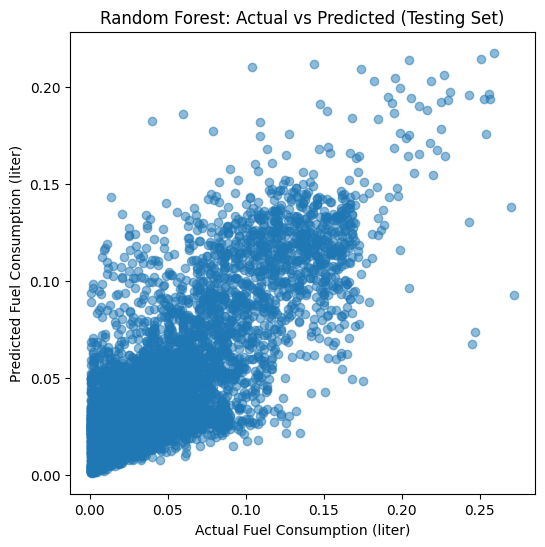

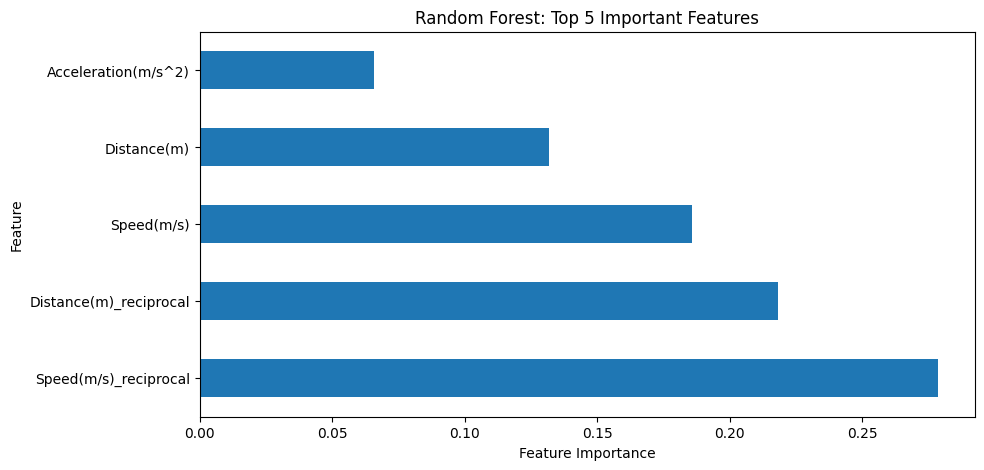

In [48]:


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np


df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)

df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(columns=["Fuel_Consumption(liter)", "Latitude", "Longitude"])
y_train = df1["Fuel_Consumption(liter)"]

x_test = df2.drop(columns=["Fuel_Consumption(liter)", "Latitude", "Longitude"])
y_test = df2["Fuel_Consumption(liter)"]

# Add reciprocal features for both training and testing sets
reciprocal_features_train = 1 / (x_train.replace(0, np.nan))  # Avoid division by zero
reciprocal_features_train.columns = [f"{col}_reciprocal" for col in x_train.columns]
x_train = pd.concat([x_train, reciprocal_features_train], axis=1)

reciprocal_features_test = 1 / (x_test.replace(0, np.nan))  # Avoid division by zero
reciprocal_features_test.columns = [f"{col}_reciprocal" for col in x_test.columns]
x_test = pd.concat([x_test, reciprocal_features_test], axis=1)

# Impute NaN values with the median of each column separately for training and testing sets
imputer = SimpleImputer(strategy="median")
x_train = pd.DataFrame(imputer.fit_transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(imputer.transform(x_test), columns=x_test.columns)


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

param_grid_rf = {
    'max_depth': [15, 30],
    'max_features': [5, 10],
}

rf = RandomForestRegressor(n_estimators=300)
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, n_jobs=-1, scoring='r2')
grid_search_rf.fit(x_train_scaled, y_train)


print("Best hyperparameters for Random Forest:")
print(grid_search_rf.best_params_)


best_rf = grid_search_rf.best_estimator_

# Make predictions with Random Forest on both training and testing sets
y_train_pred_rf = best_rf.predict(x_train_scaled)
y_test_pred_rf = best_rf.predict(x_test_scaled)

# Evaluate Random Forest model on both training and testing sets
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)


print(f"Random Forest - Train R^2: {train_r2_rf}")
print(f"Random Forest - Test R^2: {test_r2_rf}")

# Plot Actual vs Predicted for Random Forest on testing set
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.5)
plt.xlabel("Actual Fuel Consumption (liter)")
plt.ylabel("Predicted Fuel Consumption (liter)")
plt.title("Random Forest: Actual vs Predicted (Testing Set)")
plt.show()

# Display feature importances for Random Forest
plt.figure(figsize=(10, 5))
feature_importances = pd.Series(best_rf.feature_importances_, index=x_train.columns)
feature_importances.nlargest(5).plot(kind='barh')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest: Top 5 Important Features")
plt.show()

Note: This code runs in 40 minutes.

Here we are doing RandomForest model with our original data while doing a transformation in our features. The transformation we do consists on calculating the reciprocal of our features. As we can see the performance of our model R^2 score of 0.76 for training set and 0.65 for testing set. We plot the predicted values against the real ones. We plot as well the 5 most relevant features in this model, which are reciprocal of speed, reciprocal of distance, speed, distance, and acceleration.

#### **Ensemble method**

Below we use 5 random forest algorithms, 1 linear regression, 1 extra tree, 1 decision tree with VotingRegressor and also use Grid Search for specifically the random forests and extra tree with cross validation split =5..

In [18]:
import pandas as pd
from sklearn.ensemble import VotingRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)


df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(columns=["Fuel_Consumption(liter)", "Latitude", "Longitude"])
y_train = df1["Fuel_Consumption(liter)"]

x_test = df2.drop(columns=["Fuel_Consumption(liter)", "Latitude", "Longitude"])
y_test = df2["Fuel_Consumption(liter)"]


estimators = [
    ('tree', DecisionTreeRegressor(random_state=43, max_depth=5, max_features=5)),
    ('ridge', Ridge(alpha=10**1.1721022975334818)),
    ('linear', LinearRegression()),
    ('forest1', RandomForestRegressor(n_estimators=500, max_depth=5, max_features=5, random_state=43)),
    ('extra', ExtraTreeRegressor(max_features='sqrt', random_state=43))
]


voting_reg = VotingRegressor(estimators=estimators)


pipe = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('reg', voting_reg)
])



pipe.fit(x_train, y_train)


print("Voting regressor R^2 score:", pipe.score(x_train, y_train))
print("Voting regressor R^2 score:", pipe.score(x_test, y_test))


Voting regressor R^2 score: 0.7282519680989497
Voting regressor R^2 score: 0.6491188245842621


### **Phase 2: Predicting driving pattern**

In this phase, we will be only considering this problem as a classification problem, predicting the "Driving_Pattern".
As we have already explained this in EDA the "Driving_Pattern" column is a binary feature consisting of class 0 and class 1.

It is very important to mention that we have approximately 86% of class 0 and 14% of class 1 which means that this problem is highly imbalanced.

Class 0 appears on highway and more spread out of the city meaning that class 0 consists on the trucks travelling in highway,
whereas Class 1 appears mostly in the middle of the city which actually tells us that class 1 is city based driving pattern.

Class 0 : HIGHWAY
Class 1 : CITY

Very important thing to check, we are using original separated data, which means that we are not using train_test_split function where one can pass the parameter stratify to equally or proportionally split the data correctly. Accordingly we do not know how the target value "Driving_Pattern" is split in the original files, hence we will plot to see if it has been correctly split.

In the code below, we firstly use pandas to open the two csv files without concatenating them as we have demonstrated in approach 1. 

- We drop the "Id" column and plot the features with respect to the target variable "Driving_Pattern" using scatter plots .

#### **Pair plots between features and driving pattern**

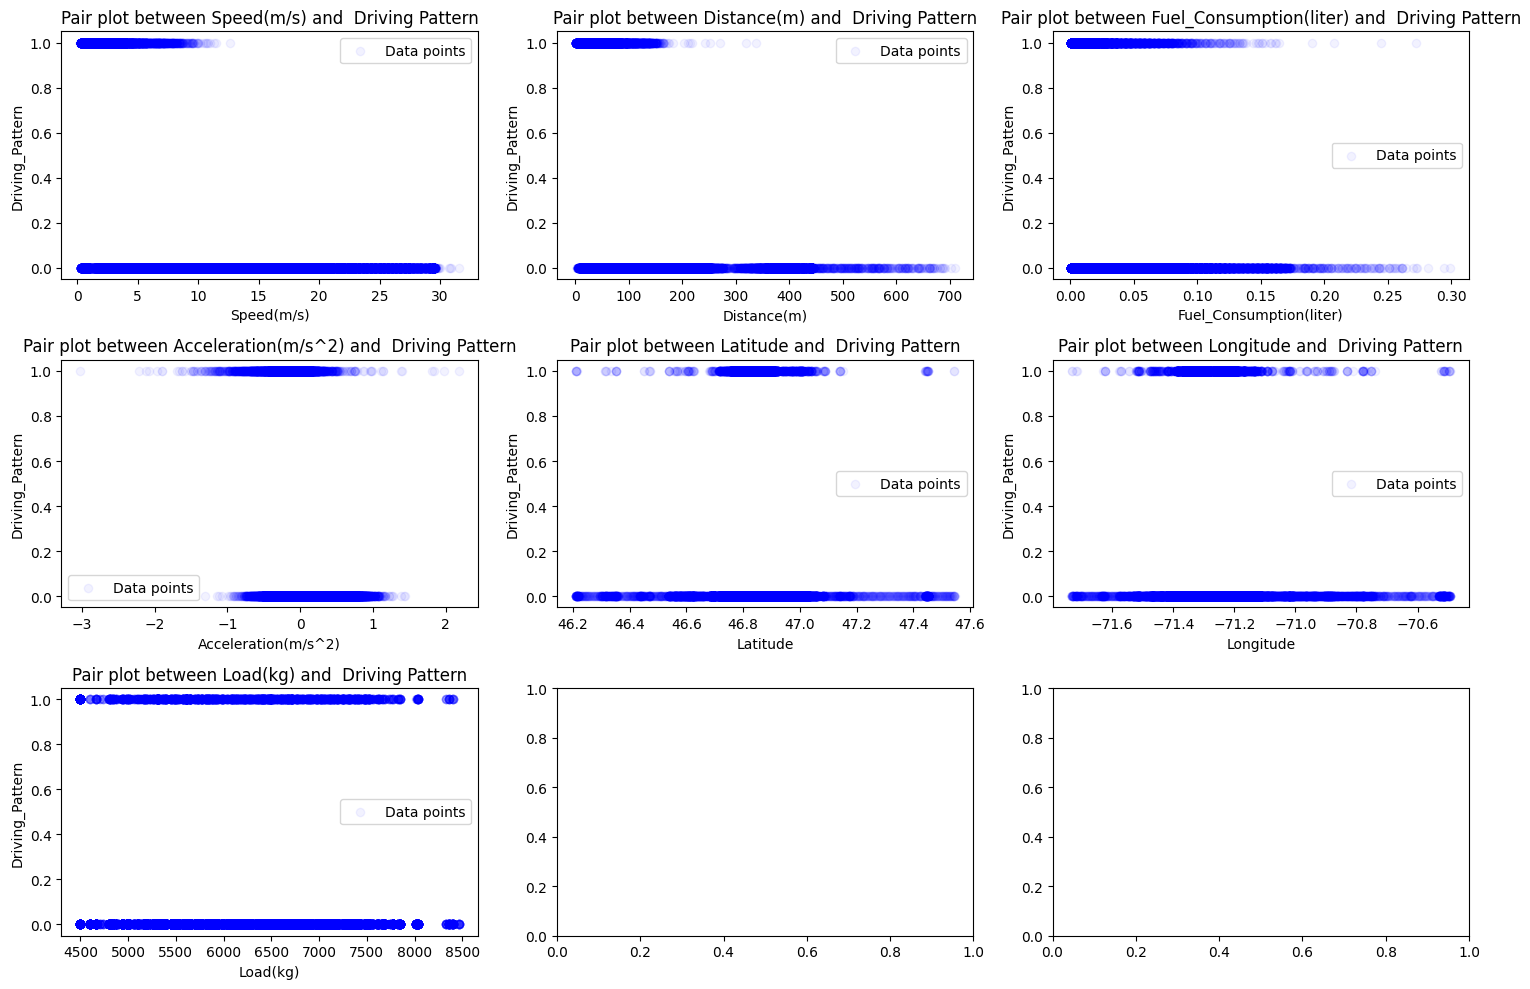

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display



df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")

df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df = pd.concat([df1, df2], ignore_index=True)

df.drop(["Id"], axis=1, inplace=True)

# Function to create scatter plots
def plot_scatter(ax, x, y, xlabel, ylabel, title, color, marker):
    ax.scatter(x, y, label="Data points", color=color, marker=marker, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

# List of features to plot against Fuel_Consumption(liter)
features = ["Speed(m/s)", "Distance(m)", "Fuel_Consumption(liter)", "Acceleration(m/s^2)", "Latitude", "Longitude", "Load(kg)"]
num_features = len(features)


num_rows = 3
num_cols = 3


fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10)) 


axes = axes.flatten()

# Plot each scatter plot in the grid
for i, feature in enumerate(features):
    plot_scatter(
        axes[i],
        df[feature],
        df["Driving_Pattern"],
        feature,
        "Driving_Pattern",
        f"Pair plot between {feature} and  Driving Pattern",
        "blue",
        "o"
    )


plt.tight_layout()
plt.show()



⦁	Speed is higher in driving pattern 0 which is the key to understand what 0 means here. We can see that when driving pattern is 1, the speed does not exceed approximately 10 m/s while when it is 0 it goes up to the max value. 

⦁	Distance is also higher in driving pattern 0 since speed and distance correlate with each other and also we can say that when driving pattern is 0 the speed is higher usually resulting in longer distances as well.

⦁	The key observation here is about acceleration, which tells us that when driving pattern is 1, majority of trucks are not driving stable. They accelerate and decelerate very often, telling us that there is a strong braking and strong acceleration which also might mean it is a city based place.

⦁	Rgearding the load, there is no specific change or outlier, roughly saying in our dataset the load does not affect anything.


#### **3D plots of features with respect to driving pattern**

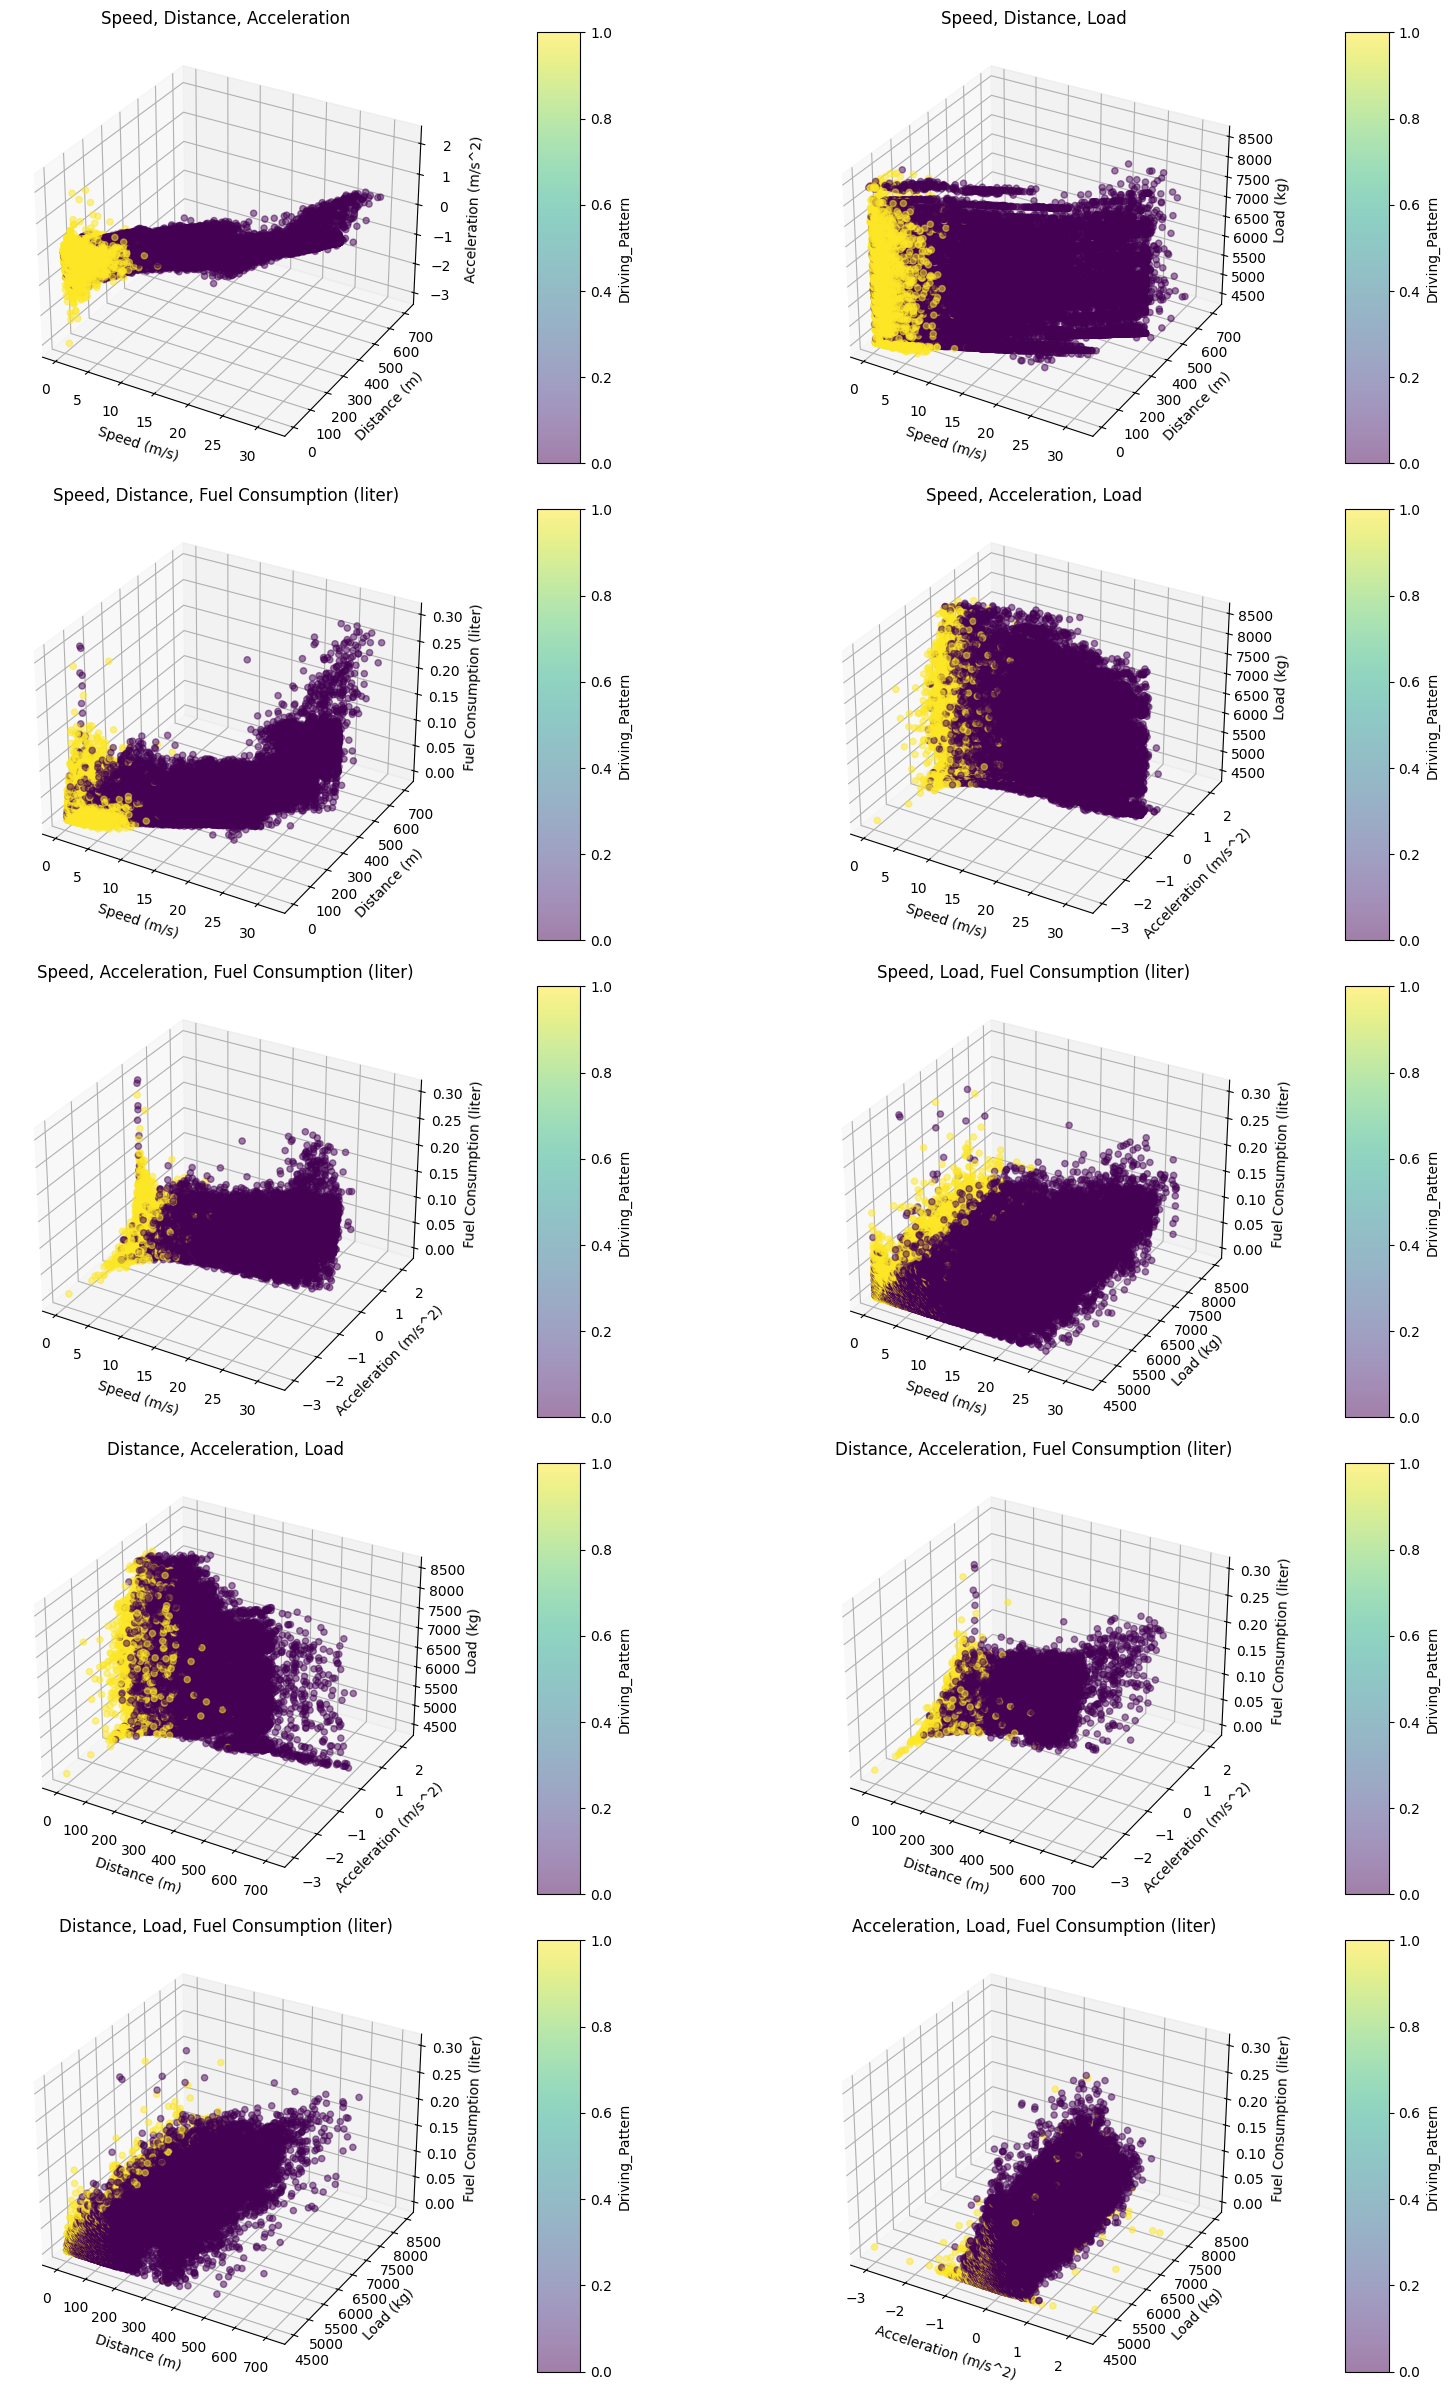

In [47]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Function to plot a 3D scatter plot with color-coded fuel consumption
def plot_3d_scatter(ax, x, y, z, c, xlabel, ylabel, zlabel, clabel, title):
    scatter = ax.scatter(x, y, z, c=c, cmap='viridis', marker='o', alpha=0.5)
    cbar = plt.colorbar(scatter, ax=ax, pad=0.1, aspect=10)
    cbar.set_label(clabel)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)


num_rows = 5
num_cols = 2


fig = plt.figure(figsize=(18, 24))  


# Here we do combinations of features
plots = [
    (df['Speed(m/s)'], df['Distance(m)'], df['Acceleration(m/s^2)'], df['Driving_Pattern'],
     'Speed (m/s)', 'Distance (m)', 'Acceleration (m/s^2)', 'Driving_Pattern',
     'Speed, Distance, Acceleration'),

    (df['Speed(m/s)'], df['Distance(m)'], df['Load(kg)'], df['Driving_Pattern'],
     'Speed (m/s)', 'Distance (m)', 'Load (kg)', 'Driving_Pattern',
     'Speed, Distance, Load'),

    (df['Speed(m/s)'], df['Distance(m)'], df['Fuel_Consumption(liter)'], df['Driving_Pattern'],
     'Speed (m/s)', 'Distance (m)', 'Fuel Consumption (liter)', 'Driving_Pattern',
     'Speed, Distance, Fuel Consumption (liter)'),

    (df['Speed(m/s)'], df['Acceleration(m/s^2)'], df['Load(kg)'], df['Driving_Pattern'],
     'Speed (m/s)', 'Acceleration (m/s^2)', 'Load (kg)', 'Driving_Pattern',
     'Speed, Acceleration, Load'),

    (df['Speed(m/s)'], df['Acceleration(m/s^2)'], df['Fuel_Consumption(liter)'], df['Driving_Pattern'],
     'Speed (m/s)', 'Acceleration (m/s^2)', 'Fuel Consumption (liter)', 'Driving_Pattern',
     'Speed, Acceleration, Fuel Consumption (liter)'),

    (df['Speed(m/s)'], df['Load(kg)'], df['Fuel_Consumption(liter)'], df['Driving_Pattern'],
     'Speed (m/s)', 'Load (kg)', 'Fuel Consumption (liter)', 'Driving_Pattern',
     'Speed, Load, Fuel Consumption (liter)'),

    (df['Distance(m)'], df['Acceleration(m/s^2)'], df['Load(kg)'], df['Driving_Pattern'],
     'Distance (m)', 'Acceleration (m/s^2)', 'Load (kg)', 'Driving_Pattern',
     'Distance, Acceleration, Load'),

    (df['Distance(m)'], df['Acceleration(m/s^2)'], df['Fuel_Consumption(liter)'], df['Driving_Pattern'],
     'Distance (m)', 'Acceleration (m/s^2)', 'Fuel Consumption (liter)', 'Driving_Pattern',
     'Distance, Acceleration, Fuel Consumption (liter)'),

    (df['Distance(m)'], df['Load(kg)'], df['Fuel_Consumption(liter)'], df['Driving_Pattern'],
     'Distance (m)', 'Load (kg)', 'Fuel Consumption (liter)', 'Driving_Pattern',
     'Distance, Load, Fuel Consumption (liter)'),

    (df['Acceleration(m/s^2)'], df['Load(kg)'], df['Fuel_Consumption(liter)'], df['Driving_Pattern'],
     'Acceleration (m/s^2)', 'Load (kg)', 'Fuel Consumption (liter)', 'Driving_Pattern',
     'Acceleration, Load, Fuel Consumption (liter)')
]

# Loop through the plots and create each subplot
for i, (x, y, z, c, xlabel, ylabel, zlabel, clabel, title) in enumerate(plots):
    ax = fig.add_subplot(num_rows, num_cols, i + 1, projection='3d')
    plot_3d_scatter(ax, x, y, z, c, xlabel, ylabel, zlabel, clabel, title)

plt.tight_layout()
plt.show()

We will describe the most important insights, and from what we observe is that the driving pattern is more affected by the speed, distance, acceleration, and fuel consumption, but is not affected by the load.

Speed, Distance, Acceleration (Top Left):

- Class 1 Driving patterns generally occur at lower speeds.

Speed, Distance, Load (Top Right):

- The driving pattern class 1 again occurs at lower speeds and distances.

Speed, Distance, Fuel Consumption (Second Row Left):

- Here we can observe that the driving pattern of class 0 only occurred when fuel consumption was high But we see that class 1 occurred when the fuel consumption was low. What this means is that we do not have any data points (except some outliers like 4-5 data points we can also see this in this plot) being class 0 at the same time with high fuel consumption. We can see that class 1 does not exceed the value of fuel consumption, more than approximately 0.10. Class 0 and Class 1 are easily distinguishable.


In the plots where there is distance in the axis:

- These plots were also interesting to talk about, because we see that class 1 only occurs when the distance is roughly equal to 100-200 meters, but it does not appear for more than 200 meters, except only a few outliers. 


Additional general observation:

- We can also easily distinguish the two classes concerning the speed. If you look at the plots where there is a speed axis, you will see that with speeds up to 5 m/s there only occurs class 1, after speeds more than 5 m/s there are only data points consisting of class 0.

- In the case of acceleration we find the extreme values only for class 1, for class 0 they seem to be more stable.

#### **Distribution of driving pattern**

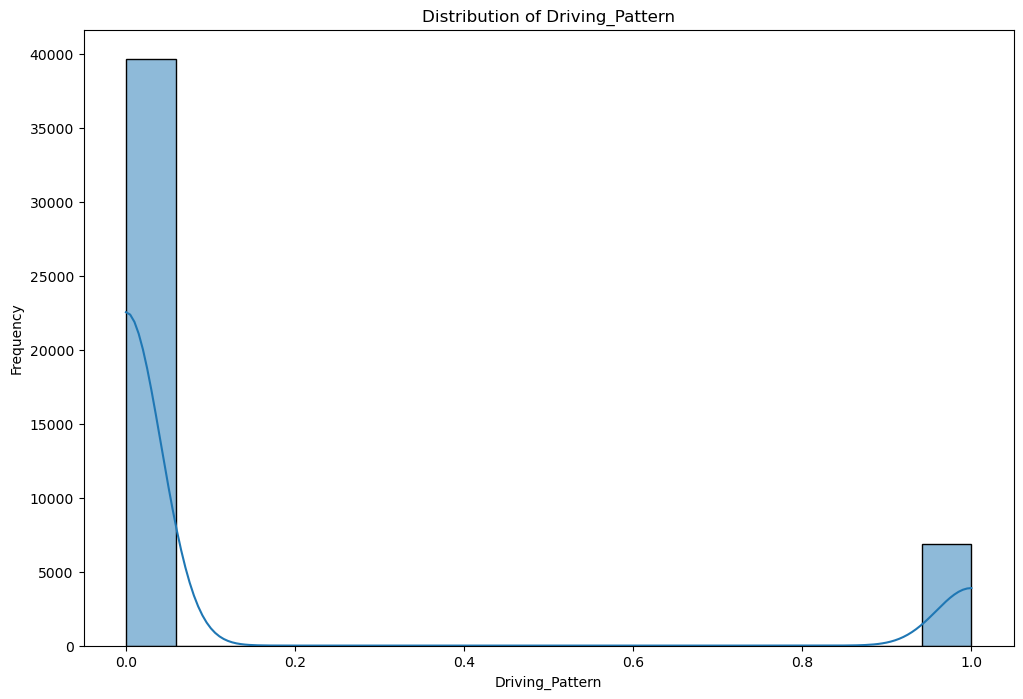

In [6]:
summary_stats = df.describe()

plt.figure(figsize=(12, 8))
sns.histplot(df['Driving_Pattern'], kde=True)
plt.title('Distribution of Driving_Pattern')
plt.xlabel('Driving_Pattern')
plt.ylabel('Frequency')
plt.show()

#### **Distribution of driving pattern for training data set (original split)**


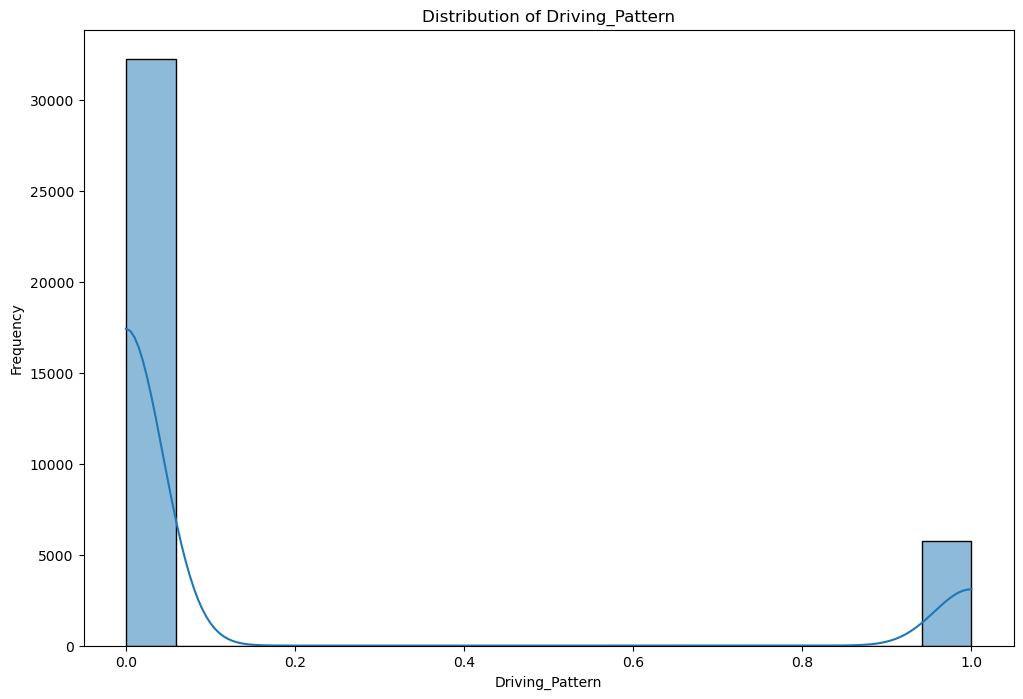

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(columns=["Driving_Pattern"])
y_train = df1["Driving_Pattern"]

x_test = df2.drop(columns=["Driving_Pattern"])
y_test = df2["Driving_Pattern"]


summary_stats = df1.describe()

plt.figure(figsize=(12, 8))
sns.histplot(df1['Driving_Pattern'], kde=True)
plt.title('Distribution of Driving_Pattern')
plt.xlabel('Driving_Pattern')
plt.ylabel('Frequency')
plt.show()

#### **Distribution of driving pattern for testing data set (original split)**

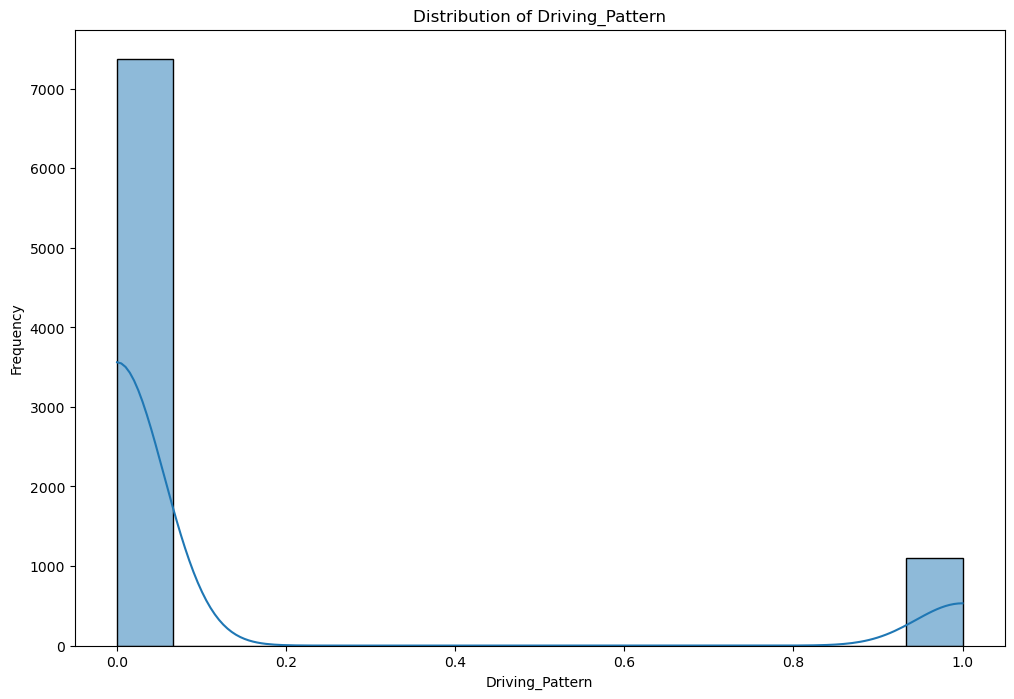

In [9]:
summary_stats = df2.describe()

plt.figure(figsize=(12, 8))
sns.histplot(df2['Driving_Pattern'], kde=True)
plt.title('Distribution of Driving_Pattern')
plt.xlabel('Driving_Pattern')
plt.ylabel('Frequency')
plt.show()

Looking at the plots above, we can see that the distribution of the driving pattern for the whole data and the distributions of the driving pattern for the train and test data, respectively, look the same. However, we would also, for preciseness, calculate the percentage of each class for the whole data set and compare this to the training and testing datasets to see if the stratifying is similar or basically well split, which we show below by using the value.counts() function.

In [12]:
print("The Training data", df1["Driving_Pattern"].value_counts())
print("The Testing data", df2["Driving_Pattern"].value_counts())
print("The whole data set", df["Driving_Pattern"].value_counts())

The Training data Driving_Pattern
0    32266
1     5738
Name: count, dtype: int64
The Testing data Driving_Pattern
0    7372
1    1100
Name: count, dtype: int64
The whole data set Driving_Pattern
0    39638
1     6838
Name: count, dtype: int64


Calculation of the whole data:

- 39638 + 6838 = 46476 data points (the whole data set)
- 39638 x 100% / 46476 = approx. 86% class 0 

Calculation of the training data:

- 32266 + 5738 = 38004 (training points)
- 32266 x 100% / 38004 = 85% of class 0

Calculation of the testing data:

- 7372 + 1100 = 8472 (testing points)
- 7372 x 100% / 8472 = 87% of class 0


We explicitely showed the hand calculations to demonstrate to you that training and testing datas are proportionally correctly split.

#### **KNN algorithm** 
We will train simple KNN algorithm and demonstrate to you the most important parts as well.

In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(["Driving_Pattern", "Latitude", "Longitude"], axis=1)
y_train = df1["Driving_Pattern"]

x_test = df2.drop(["Driving_Pattern", "Latitude", "Longitude"], axis =1)
y_test = df2["Driving_Pattern"]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

neigh = KNeighborsClassifier(n_neighbors=5) # just a random k value , we will demonstrate how to tune this below

neigh.fit(x_train, y_train)
print("Train accuracy", neigh.score(x_train, y_train))
print("Test accuracy", neigh.score(x_test, y_test))




Train accuracy 0.9420587306599305
Test accuracy 0.9313031161473088


We first trained with simple KNN algorithm with number of neighbors = 5 and we get a training and test accuracy 94 and 93 percent respectively.

Best K value: 19
Train accuracy 0.9296981960564198
Test(validation if being exact) accuracy 0.9240607260817482


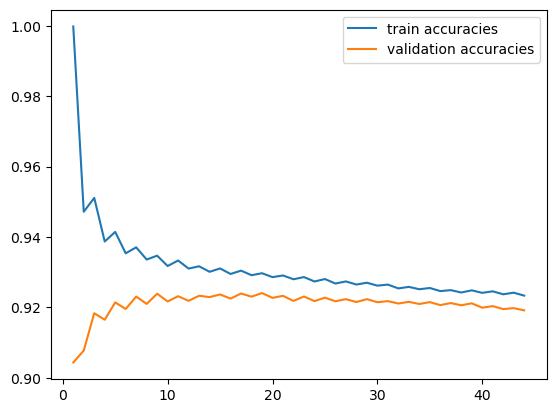

In [44]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
import numpy as np
ks = list(range(1, 45))
train_accuracies = []
val_accuracies = []
val_accuracy = -np.inf 
train_accuracy = -np.inf

best_k = None

skf = StratifiedKFold(n_splits=5)

for k in ks:
  neigh = KNeighborsClassifier(n_neighbors=k)
  scores = cross_validate(neigh,
                          x_train,
                          y_train,
                          cv=skf, # NOTE: here we use the `StratifiedKFold` object from above
                          return_train_score=True)

  train_cv_score = np.mean(scores["train_score"])
  val_cv_score = np.mean(scores["test_score"])

  train_accuracies.append(train_cv_score)
  val_accuracies.append(val_cv_score)

  if val_cv_score > val_accuracy:
    best_k = k
    val_accuracy = val_cv_score
    train_accuracy = train_cv_score



print("Best K value:", best_k)
print("Train accuracy", train_accuracy)
print("Test(validation if being exact) accuracy", val_accuracy)
  

plt.plot(ks, train_accuracies, label="train accuracies")
plt.plot(ks, val_accuracies, label="validation accuracies")
plt.legend()
plt.show()

We more or less see the expected effect: For very small  k, the training accuracy is essentially perfect, but there is a gap between the training and validation accuracy (overfitting).

The accuracy of the kNN classifier might seem very impressive (and it is quite good). However, this is a highly imbalanced task. Even a trivial classifier which would always say "class 0" would attain an accuracy of  86% , even though this trivial classifier is essentially useless. We will next discuss alternative metrics that are more useful for imbalanced classification tasks than the accuracy is.

And looking to the graph we can see that the two lines indicating the train and test accuracies tend to go lower and there is no point increasing further the number of k values in the loop. Our best k value here is 19 with train and test score being approximately equal, so no overfitting 93% and 92%.

#### **Alternative metrics**

We will do a confusion matrix to summarize the performance of the binary classifier.

We use scikit-learn to compute and display the confusion matrix for the task of classifying "class 0" vs. "class 1" where we use a kNN model as the classifier.

We fit a kNN classifier and compute its train and validation accuracy with the best chosen k value = 19.




In [46]:
neigh = KNeighborsClassifier(n_neighbors=19) 
skf = StratifiedKFold(n_splits=5)

scores = cross_validate(neigh,
                        x_train,
                        y_train,
                        cv=skf, # NOTE: here we use the `StratifiedKFold` object from above
                        return_train_score=True)

train_cv_score = np.mean(scores["train_score"])
val_cv_score = np.mean(scores["test_score"])

print("train CV accuracy:", train_cv_score)
print("CV accuracy:", val_cv_score)

train CV accuracy: 0.9296981960564198
CV accuracy: 0.9240607260817482


Here, we use the function cross_val_predict to compute predictions for the training set using cross validation. This works similarly to regular cross validation, we train the model on the union of the "training folds" and then use the trained model to compute the predictions for the "validation fold".

[[31295   971]
 [ 1915  3823]]


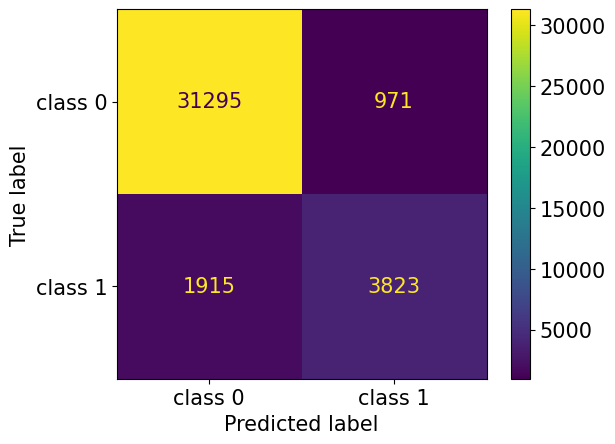

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt


plt.rcParams.update({'font.size': 15})


skf = StratifiedKFold(n_splits=5)
predictions = cross_val_predict(neigh, x_train, y_train, cv=skf)


cm = confusion_matrix(y_train, predictions)
print(cm) 


disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["class 0", "class 1"])

disp.plot()
plt.show()

We see here that the major problem of the above classifier, is that it only correctly classifies 3823 of the 5738 actual class 1 (i.e. it misses 1915 out of 5738, this means,  33.3%  are missed). If this was a classifier for cancer detection that would not be a good performance as stated in the lecture notes.

In contrast, misclassifying 971 of 32266 "Class 0" as "Class 1's" might be good. 97% correctly detects Class 0 but 66% correctly detects the Class 1.

The issue is that the number of "Class 1" is small compared to the number of "Class 0" (the dataset is imbalanced), so that the accuracy can be very high, even though a large fraction of the "Class 1" is misclassified.

Let us now look at a number of other performance measures which are designed to measure issues like this.

It is important to at least understand the meaning of the different metrics. For instance, it is important to understand that a low sensitivity means that the classifier is working badly on the actual positives, whereas a low specificity means that the classifier is working badly on the actual negative samples.

In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score

recall = recall_score(y_train, predictions) 

# specificity is the same as sensitivity (or recall) with interchanged roles of the "positive" and "negative" classes
specificity = recall_score(y_train, predictions, pos_label=0)
precision = precision_score(y_train, predictions)
F1 = f1_score(y_train, predictions)



print(f"{specificity=}")
print(f"{precision=}")
print(f"{recall=}")
print(f"{F1=}")

specificity=0.9699064030248559
precision=0.7974551522736755
recall=0.6662600209132101
F1=0.7259779718951767


Observation:

- Specificity is pretty good 96 % which means that we predict 96% correctly class 0.
- Precision is quite low about 79% which means out of our predicted values of class 1 we only got 79% correctly.
- Recall is also really bad about 66% which means we predicted only 66% correctly of class 1.

- F1 score is the harmonic mean of precision and recall, and it is only good if both precision and recall is good.

As our precision and recall scores are not good, our F1 score is also not good.

So we will mainly focus on increasing F1 score to increase the number of correct predictions of class 1.

#### **Voting threshold (decision treshold)**

We now realized that our model from above has a good accuracy, but does not actually work that well on class 1 samples.

The question is how to address this problem.

First, let us train the model once more.

In [67]:

skf = StratifiedKFold(n_splits=5)
proba_predictions = cross_val_predict(neigh,
                                      x_train,
                                      y_train,
                                      cv=skf,
                                      method='predict_proba') 

print(proba_predictions.shape)

proba_predictions = proba_predictions[:, 1] # predicted probabilities for class 1

for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
  y_pred = (proba_predictions >= thresh)
  print(f"{thresh=}: accuracy:", np.sum(y_train == y_pred) / len(y_train))
  print(f"{thresh=}: recall/sensitivity:", recall_score(y_train, y_pred))
  print(f"{thresh=}: precision:", precision_score(y_train, y_pred))
  print(f"{thresh=}: specificity:", recall_score(y_train, y_pred, pos_label=0))
  print(f"{thresh=}: F1 score:", f1_score(y_train, y_pred))
  print()

(38004, 2)
thresh=0.1: accuracy: 0.8193084938427534
thresh=0.1: recall/sensitivity: 0.9238410596026491
thresh=0.1: precision: 0.4518796351547183
thresh=0.1: specificity: 0.8007190231203124
thresh=0.1: F1 score: 0.6069036579082947

thresh=0.2: accuracy: 0.8951952426060414
thresh=0.2: recall/sensitivity: 0.850644823980481
thresh=0.2: precision: 0.6095916073435744
thresh=0.2: specificity: 0.9031178330130788
thresh=0.2: F1 score: 0.7102218988723172

thresh=0.3: accuracy: 0.9189295863593306
thresh=0.3: recall/sensitivity: 0.7906936214708958
thresh=0.3: precision: 0.7070282063269441
thresh=0.3: specificity: 0.9417343333539949
thresh=0.3: F1 score: 0.7465240641711229

thresh=0.4: accuracy: 0.9247447637090832
thresh=0.4: recall/sensitivity: 0.7312652492157546
thresh=0.4: precision: 0.7609720710917665
thresh=0.4: specificity: 0.9591520485960454
thresh=0.4: F1 score: 0.7458229648062566

thresh=0.5: accuracy: 0.9240606251973477
thresh=0.5: recall/sensitivity: 0.6662600209132101
thresh=0.5: precis

Above, we just computed the recall and precision for different values of the decision threshold to select the best one. From above we can say that for this method of tuning we have 0.3 the best threshold value because we gain the best F1 score but below we will demonstrate a better way to tune the threshold value using ROC and precision recall curves.

#### **Precision-recall curves**

To compute/display a precision-recall curve, one more or less does the same as we did above for finding a good decision threshold, but with all possible (or sensible) values of the decision threshold. More precisely, one computes all values of predict_proba that occur for the given data set, takes each of these values as a possible decision threshold and computes the precision and recall for each value.

In [12]:
print(y_train.value_counts())
print((y_train == 1).value_counts())

Driving_Pattern
0    32266
1     5738
Name: count, dtype: int64
Driving_Pattern
False    32266
True      5738
Name: count, dtype: int64


threshold values: [0.         0.05263158 0.10526316 0.15789474 0.21052632 0.26315789
 0.31578947 0.36842105 0.42105263 0.47368421 0.52631579 0.57894737
 0.63157895 0.68421053 0.73684211 0.78947368 0.84210526 0.89473684
 0.94736842 1.        ]
len(thresholds)=20


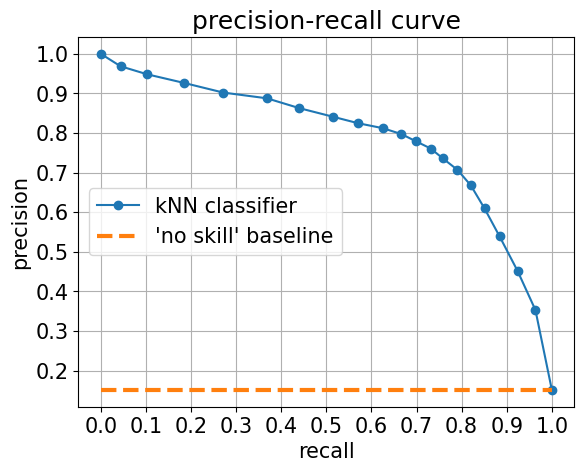

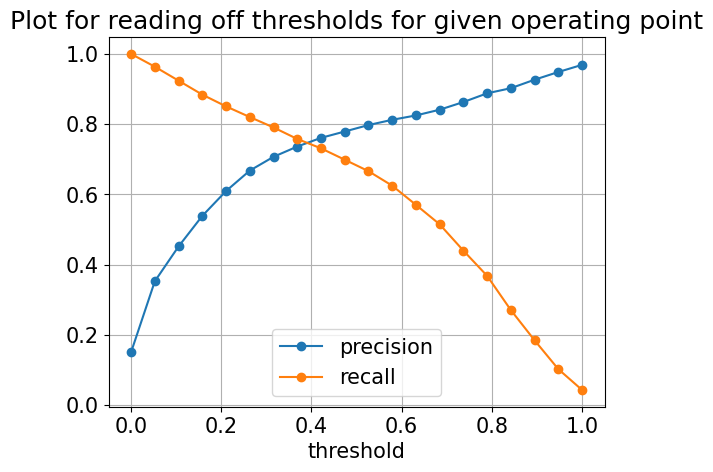

In [74]:
from sklearn.metrics import precision_recall_curve
from matplotlib.ticker import MultipleLocator # just to make the plot more beautiful
print(y_train)

skf = StratifiedKFold(n_splits=5)
proba_predictions = cross_val_predict(neigh,
                                      x_train,
                                      y_train,
                                      cv=skf,
                                      method='predict_proba') 


precision, recall, thresholds = precision_recall_curve(y_train,
                                                       proba_predictions[:,1]) # Note the "[:,1], for class 1"

print("threshold values:", thresholds)
print(f"{len(thresholds)=}")

plt.plot(recall, precision, '-o', label="kNN classifier")

positive_fraction = np.sum(y_train == 1) / len(y_train)
plt.plot([0,1], [positive_fraction, positive_fraction], '--', lw=3, label="'no skill' baseline")
plt.ylabel("precision")
plt.xlabel("recall")
plt.legend()
plt.grid(which='both')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
plt.title("precision-recall curve")
plt.show()

print()
print()

plt.plot(thresholds, precision[:-1], '-o', label="precision")
plt.plot(thresholds, recall[:-1], '-o', label="recall")
plt.xlabel("threshold")
plt.legend()
plt.grid(which='both')
plt.title("Plot for reading off thresholds for given operating point")
plt.show()

The precision-recall curve can be used in several ways:

For a given desired recall (or precision), one can read off what the best possible value of precision (or recall) is that one can obtain using the given model, by varying the decision threshold.

For instance, it is possible to achieve

a recall of  ≈90%  with a precision of  ≈50% 
a recall of  ≈80%  with a precision of  ≈70% 
a recall of  ≈70%  with a precision of  ≈78% 
The corresponding thresholds for achieving these precision/recall values can be read off from the second plot shown above.



#### **Average precision score**

A common way to measure the overall performance of the model consists on computing the so-called average precision, which is essentially the area under the precision-recall curve.

In [70]:
from sklearn.metrics import average_precision_score


skf = StratifiedKFold(n_splits=5)
proba_predictions = cross_val_predict(neigh,
                                      x_train,
                                      y_train,
                                      cv=skf,
                                      method='predict_proba')

# first parameter: actual/true labels
# second parameter: "target scores" (as for instance produced by `predict_proba`)
print("average precision (cross validation):", average_precision_score(y_train,
                                                                       proba_predictions[:,1]))

average precision (cross validation): 0.7730822819035773


#### **ROC curve**

A ROC curve (which stands for receiver operating characteristic curve, a name that stems from use of such curves connected to radar operation in the second world war) is computed/drawn just like a precision-recall curve, but
on the x-axis, one records the false positive rate, and
on the y-axis, one records the true positive rate
Thus, the plot shows the fraction of correct predictions for the positive class (y-axis) versus the fraction of errors for the negative class (x-axis).

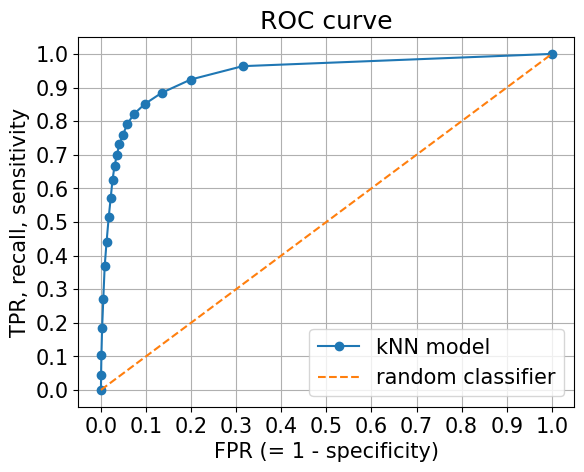

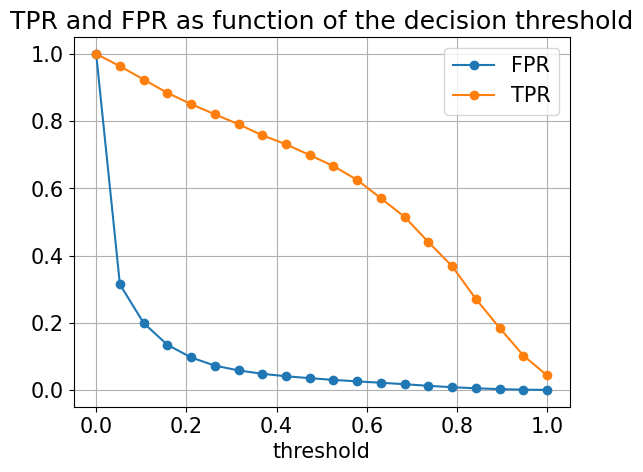

In [71]:
from sklearn.metrics import roc_curve

skf = StratifiedKFold(n_splits=5)
proba_predictions = cross_val_predict(neigh,
                                      x_train,
                                      y_train,
                                      cv=skf,
                                      method='predict_proba')

fpr, tpr, thresholds = roc_curve(y_train,
                                 proba_predictions[:,1]) 

plt.plot(fpr, tpr, '-o', label="kNN model") 
plt.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), '--', label="random classifier")
plt.xlabel("FPR (= 1 - specificity)")
plt.ylabel("TPR, recall, sensitivity")
plt.legend()
plt.grid(which='both')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
plt.title("ROC curve")
plt.legend()
plt.show()


plt.plot(thresholds[1:], fpr[1:], '-o', label="FPR") 
plt.plot(thresholds[1:], tpr[1:], '-o', label="TPR") 
plt.xlabel("threshold")
plt.legend()
plt.grid(which='both')
plt.title("TPR and FPR as function of the decision threshold")
plt.show()

A perfect classifier has FRP = 0 and TPR = 1

#### **AUC (area under curve)**

One can summarize (to some extent) the shape of the ROC curve in one single number, called AUC (area under curve), or ROC AUC to be more precise. This metric measures the area under the ROC curve. It is often used as an alternative to the  F1  score to compare different classifiers for highly imbalanced problems.

One important beneficial property of the ROC AUC metric is that it treats both classes the same, even if one of the two classes has much more samples.

In [72]:
from sklearn.metrics import roc_auc_score

print("ROC AUC score (cross validation):", roc_auc_score(y_train,
                                                         proba_predictions[:,1]))

ROC AUC score (cross validation): 0.9390641198012937


Here we see that we have a really good AUC score but when we compute the precision recall curve and the average precision score we get relatively worse score. This is because when dealing with precision recall curve it essentially considers the performance of the model on the CLASS 1 (meaning both the "actual Class 1's" and the "predicted Class 1's").

- The precision measures what fraction of the predicted CLASS 1 samples are correctly predicted.
- The recall measures what fraction of the actual CLASS 1 samples are correctly predicted.
- In particular, the number of true CLASS 0 samples or as in the lecture notes the true negatives(TN) does not play a role at all for the precision-recall curve.

#### **Final results of KNN**



- RECALL: 73%
- PRECISION :76%
- F1: 74%

- Average Precision (cross validation): 0.7730822819035773

#### **Logistic regression**

In [108]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

logreg.fit(x_train, y_train)

LogisticRegression()

In [28]:
np.set_printoptions(precision=2) 

probabilities_train = logreg.predict_proba(x_train)
probabilities_test = logreg.predict_proba(x_test)

print("model trained on the FIRST data set")
print()

print(f"{probabilities_train.shape=}")
print(probabilities_train[:20, 1])
print()

print(f"{probabilities_test.shape=}")
print(probabilities_test[:20, 1])
print()

model trained on the FIRST data set

probabilities_train.shape=(38004, 2)
[0.23 0.19 0.04 0.82 0.06 0.01 0.19 0.75 0.34 0.48 0.9  0.26 0.35 0.13
 0.07 0.03 0.6  0.44 0.65 0.46]

probabilities_test.shape=(8472, 2)
[3.68e-01 2.25e-01 1.11e-01 5.91e-01 4.69e-01 5.66e-01 6.93e-01 1.27e-02
 7.41e-05 3.30e-01 7.08e-05 1.26e-04 8.08e-02 1.89e-05 1.60e-04 1.81e-03
 1.01e-01 8.47e-01 1.48e-01 6.43e-02]



Here we get acces to the predicted probabilities of class 1 for both training and testing sets to see if the model is confident or not. 

We can see that the model is not confident about the predictions, this might be because we can have same inputs but with different outputs and this can create inconsistency in the models prediction resulting to its low confidence prediction.

In [109]:


print("accuracy on train set:", logreg.score(x_train, y_train))
print("accuracy on test  set:", logreg.score(x_test, y_test))
print()

accuracy on train set: 0.9188506473002842
accuracy on test  set: 0.9300047214353163



From the predictions and also the decision region plot we can say that the data itself is not linearly separable, if that then it would be perfect scores on both training and testing.

#### **Computing the logistic loss on the train and test set**


In [110]:
from sklearn.metrics import log_loss



print("log loss on train set:", log_loss(y_train, logreg.predict_proba(x_train)))
print("log loss on test  set:", log_loss(y_test, logreg.predict_proba(x_test)))
print()

log loss on train set: 0.20810346422344186
log loss on test  set: 0.1791270564409508



We want to train and evaluate the performance of a logistic regression model without involving the test set (since one should in general only look at the test set, once one has decided on a final model). Thus, we want to employ k-fold cross validation.

We then use the cross_validate function to compute the accuracy and the logistic loss on both the (cross-validation) training and the validation set

We passed 'neg_log_loss' instead of 'log_loss' to the scoring parameter of the cross_validate function. This is because in scikit-learn, scores should always have the property that "larger means better", which is not the case for the logistic loss (since it is a loss, not a score). The neg_log_loss is simply the negative of the logistic loss.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import KFold
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(["Driving_Pattern", "Latitude", "Longitude"], axis=1)
y_train = df1["Driving_Pattern"]

x_test = df2.drop(["Driving_Pattern", "Latitude", "Longitude"], axis =1)
y_test = df2["Driving_Pattern"]

pipe = Pipeline([("scaler", StandardScaler()),
                 ('logreg', LogisticRegression(penalty=None, max_iter=1_000))]) # we first consider an unregularized model



scores = cross_validate(pipe,
                        x_train,
                        y_train,
                        scoring=['accuracy', 'neg_log_loss'], # for scores "larger should mean better". Therefore, we take the NEGATIVE log loss
                        cv=5,
                        n_jobs=-1, 
                        return_train_score=True)

from pprint import pprint

pprint(scores)

{'fit_time': array([0.20547295, 0.21397495, 0.2912271 , 0.32075381, 0.20467019]),
 'score_time': array([0.11843991, 0.08411217, 0.05581903, 0.0729301 , 0.02936697]),
 'test_accuracy': array([0.91961584, 0.92001052, 0.91619524, 0.91606368, 0.92184211]),
 'test_neg_log_loss': array([-0.2008111 , -0.20272749, -0.21696986, -0.21590281, -0.20681291]),
 'train_accuracy': array([0.91879091, 0.91859356, 0.9195803 , 0.91928428, 0.91839889]),
 'train_neg_log_loss': array([-0.20994432, -0.20952524, -0.20594063, -0.20627972, -0.20847365])}


We can see that the train and test scores are more or less the same, so no overfitting thus no need to penalize/regularization but we still want to demonstrate it.

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
x_train = df1.drop(["Driving_Pattern", "Latitude", "Longitude"], axis=1)
y_train = df1["Driving_Pattern"]

x_test = df2.drop(["Driving_Pattern", "Latitude", "Longitude"], axis =1)
y_test = df2["Driving_Pattern"]


pipe = Pipeline([("scaler", StandardScaler()),
                 ('logreg', LogisticRegression(penalty='l2', 
                                               max_iter=2_000,
                                               C=1))])

param_grid = {'logreg__C' : [0.001, 0.01, 0.1, 1]}


grid_search_l2 = GridSearchCV(pipe,
                              param_grid,
                              cv=5,
                              return_train_score=True,
                              verbose=3) 

grid_search_l2.fit(x_train, y_train)

print(grid_search_l2.score(x_train, y_train))
print(grid_search_l2.score(x_test, y_test))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END logreg__C=0.001;, score=(train=0.871, test=0.869) total time=   0.3s
[CV 2/5] END logreg__C=0.001;, score=(train=0.870, test=0.870) total time=   0.3s
[CV 3/5] END logreg__C=0.001;, score=(train=0.870, test=0.871) total time=   0.3s
[CV 4/5] END logreg__C=0.001;, score=(train=0.870, test=0.870) total time=   0.3s
[CV 5/5] END logreg__C=0.001;, score=(train=0.870, test=0.870) total time=   0.2s
[CV 1/5] END logreg__C=0.01;, score=(train=0.908, test=0.907) total time=   0.4s
[CV 2/5] END logreg__C=0.01;, score=(train=0.907, test=0.909) total time=   0.3s
[CV 3/5] END logreg__C=0.01;, score=(train=0.908, test=0.908) total time=   0.2s
[CV 4/5] END logreg__C=0.01;, score=(train=0.908, test=0.902) total time=   0.2s
[CV 5/5] END logreg__C=0.01;, score=(train=0.907, test=0.912) total time=   0.4s
[CV 1/5] END .logreg__C=0.1;, score=(train=0.917, test=0.918) total time=   0.4s
[CV 2/5] END .logreg__C=0.1;, score=(train=0

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
x_train = df1.drop(["Driving_Pattern", "Latitude", "Longitude"], axis=1)
y_train = df1["Driving_Pattern"]

x_test = df2.drop(["Driving_Pattern", "Latitude", "Longitude"], axis =1)
y_test = df2["Driving_Pattern"]


pipe = Pipeline([("scaler", StandardScaler()),
                 ('logreg', LogisticRegression(penalty='l1', 
                                               max_iter=2_000,
                                               C=1,
                                               solver='liblinear'))])

param_grid = {'logreg__C' : [0.01, 0.1, 1, 10, 100]}


grid_search_l2 = GridSearchCV(pipe,
                              param_grid,
                              cv=5,
                              return_train_score=True,
                              verbose=3) 

grid_search_l2.fit(x_train, y_train)

print(grid_search_l2.score(x_train, y_train))
print(grid_search_l2.score(x_test, y_test))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END logreg__C=0.01;, score=(train=0.916, test=0.914) total time=   0.4s


[CV 2/5] END logreg__C=0.01;, score=(train=0.914, test=0.918) total time=   0.6s
[CV 3/5] END logreg__C=0.01;, score=(train=0.916, test=0.914) total time=   0.5s
[CV 4/5] END logreg__C=0.01;, score=(train=0.916, test=0.911) total time=   0.3s
[CV 5/5] END logreg__C=0.01;, score=(train=0.915, test=0.919) total time=   0.5s
[CV 1/5] END .logreg__C=0.1;, score=(train=0.918, test=0.919) total time=   0.9s
[CV 2/5] END .logreg__C=0.1;, score=(train=0.918, test=0.920) total time=   0.6s
[CV 3/5] END .logreg__C=0.1;, score=(train=0.920, test=0.916) total time=   0.6s
[CV 4/5] END .logreg__C=0.1;, score=(train=0.919, test=0.916) total time=   0.9s
[CV 5/5] END .logreg__C=0.1;, score=(train=0.918, test=0.922) total time=   0.8s
[CV 1/5] END ...logreg__C=1;, score=(train=0.919, test=0.920) total time=   0.7s
[CV 2/5] END ...logreg__C=1;, score=(train=0.919, test=0.920) total time=   1.0s
[CV 3/5] END ...logreg__C=1;, score=(train=0.920, test=0.916) total time=   1.1s
[CV 4/5] END ...logreg__C=1;

Let us first evaluate accuracy, recall, and precision on the training set.

If we had only evaluated the accuracy, things would look quite good (the accuracy is 92%, which is decent). However the recall is only 65%, which means that we miss class 1 in ~35% of the cases. This is not good.

Let us see how to fix this.

In [194]:
pipe = Pipeline([('scaler', StandardScaler()),
                 ('logreg', LogisticRegression())])

pipe.fit(x_train, y_train)

from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.model_selection import cross_val_predict

out_of_sample_predictions = cross_val_predict(pipe, x_train, y_train)

print("accuracy:", accuracy_score(y_train, out_of_sample_predictions))
print("recall   :", recall_score(y_train, out_of_sample_predictions))
print("precision:", precision_score(y_train, out_of_sample_predictions))
print()



accuracy: 0.918640143142827
recall   : 0.6563262460787731
precision: 0.7707736389684814



A logistic regression model doesn't just give a prediction of the class (0 or 1), but rather a predicted probability that 1 is the correct label.

With the default setting, the model predicts the label 1 if this predicted probability is larger than 0.5. The idea is that we can still tune this decision threshold, after training the model.

A convenient way of doing this is to use the precision_recall_curve function that we already used when we discussed tuning the decision threshold for the kNN model.

The parameters for this function the true labels,
the predicted probabilities that 1 is the correct label.
The function then returns three lists, in the order precision, recall, thresholds. The meaning of these lists is as follows:

Thresholds contains the different decision thresholds that "make sense for this data set" (essentially, all values of predict_proba that occur for this data set),
precisions, a list of precision values that the model would attain if each of the decision thresholds in the list thresholds would be used,
recalls, a list of recall values that the model would attain if each of the decision thresholds in the list thresholds would be used.

In [39]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict


y_prob_pred = cross_val_predict(pipe,
                                x_train, y_train,
                                method='predict_proba')[:, 1] 

precisions, recalls, thresholds = precision_recall_curve(y_train, y_prob_pred)

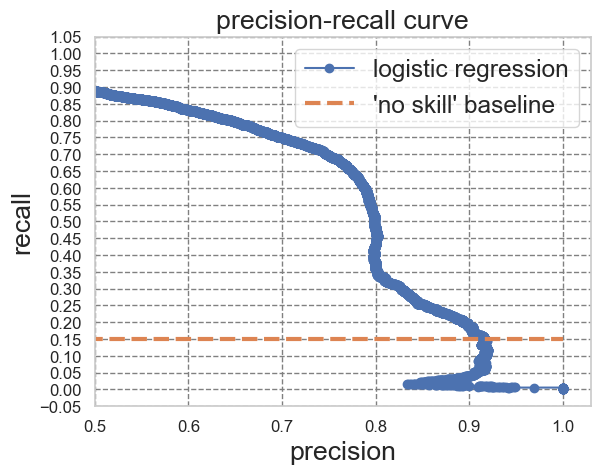

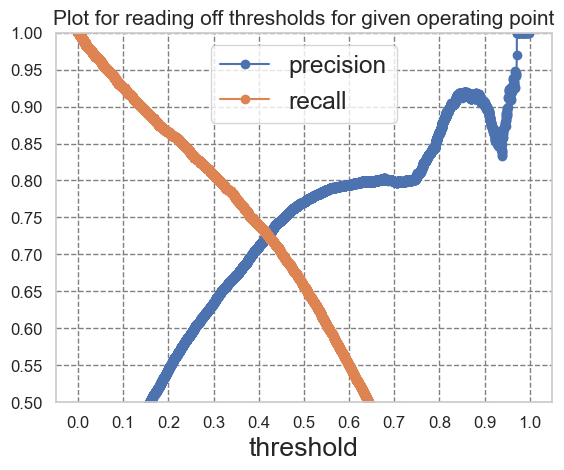

In [41]:
from matplotlib.ticker import MultipleLocator 
import seaborn as sns

sns.set(font_scale=1.6)
sns.set_style("whitegrid")

plt.plot(precisions, recalls, '-o', label="logistic regression") 
positive_fraction = np.sum(y_train == 1) / len(y_train)
plt.plot([0,1], [positive_fraction, positive_fraction], '--', lw=3, label="'no skill' baseline")
plt.xlabel("precision")
plt.ylabel("recall")
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.tick_params(axis='both', which='both', labelsize=12)
plt.title("precision-recall curve")
plt.xlim([0.5, 1.03]) # to only show the relevant part of the plot
#plt.grid(which='both')
ax.grid(which='major', color='gray', linestyle='--')
plt.show()

print()
print()


plt.plot(thresholds, precisions[:-1], '-o', label="precision")
plt.plot(thresholds, recalls[:-1], '-o', label="recall")
plt.xlabel("threshold")
plt.legend()
#plt.grid(which='both')
plt.title("Plot for reading off thresholds for given operating point", size=15)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.tick_params(axis='both', which='both', labelsize=12)
ax.grid(which='major', color='gray', linestyle='--')
ax.set_ylim([0.5, 1])
plt.show()

In [43]:
print("threshold values:", thresholds)
print(f"{len(thresholds)=}")

threshold values: [6.12e-10 1.72e-09 2.82e-09 ... 9.96e-01 9.97e-01 9.98e-01]
len(thresholds)=37740


In [69]:
good_precisions = precisions * (recalls >= 0.71) # i checked this by hand and 0.71 is the best for us because at this value we get precision and recall both 73%
best_index = np.argmax(good_precisions)

threshold = thresholds[best_index]

print("optimal threshold:", threshold)

optimal threshold: 0.4414745606625674


In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

pipe.fit(x_train, y_train)

print("default threshold (0.5)")

print("train precision:", precision_score(y_train, pipe.predict(x_train)))
print("train recall   :", recall_score(y_train, pipe.predict(x_train)))
print("train F1       :", f1_score(y_train, pipe.predict(x_train)))
print("test  precision:", precision_score(y_test, pipe.predict(x_test)))
print("test  recall   :", recall_score(y_test, pipe.predict(x_test)))
print("test  F1       :", f1_score(y_test, pipe.predict(x_test)))
print()

print(f"custom threshold ({threshold})")
print("train precision:", precision_score(y_train, pipe.predict_proba(x_train)[:,1] >= threshold)) 
print("train recall   :", recall_score(y_train, pipe.predict_proba(x_train)[:,1] >= threshold))
print("train F1       :", f1_score(y_train, pipe.predict_proba(x_train)[:,1] >= threshold))
print("test  precision:", precision_score(y_test, pipe.predict_proba(x_test)[:, 1] >= threshold))
print("test  recall   :", recall_score(y_test, pipe.predict_proba(x_test)[:,1] >= threshold))
print("test  F1       :", f1_score(y_test, pipe.predict_proba(x_test)[:,1] >= threshold))


default threshold (0.5)
train precision: 0.7727085902178381
train recall   : 0.655280585569885
train F1       : 0.7091663523198792
test  precision: 0.7605344295991778
test  recall   : 0.6727272727272727
test  F1       : 0.7139411480945489

custom threshold (0.4414745606625674)
train precision: 0.7444546287809349
train recall   : 0.7077378877657721
train F1       : 0.7256320914857501
test  precision: 0.7329700272479565
test  recall   : 0.7336363636363636
test  F1       : 0.733303044070877


#### **Final results of logistic regression model**

- Precision score: 73%
- Recall score: 73%
- F1 score : 73%


#### **Decision trees**

- Load the data as usual
- Drop the columns "Id", "Latitude", "Longitude"
- Split into x_train, x_test, y_train, y_test

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(["Driving_Pattern", "Latitude", "Longitude"], axis=1)
y_train = df1["Driving_Pattern"]

x_test = df2.drop(["Driving_Pattern", "Latitude", "Longitude"], axis =1)
y_test = df2["Driving_Pattern"]

We train two decision tree models, first decision tree with max_depth=2 randomly chosen and the second one without any parameters meaning all the parameters are default.

Training a decision tree with default values, we want to see the difference and how badly it overfits the training data

Observation:

- For the first tree "tree" model, we have a score of train 91% and test score 92%
- For the second tree "tree1" model, we have a score of training almost perfect 99.9% and the score of testing is 93%

What this tells us is that the model with default parameters is overfitting badly.

We will use grid search to find the optimal parameters for this model, but before doing the grid search, we will take a look at the f1, recall and precision scores.

In [132]:
from sklearn.tree import DecisionTreeClassifier


tree = DecisionTreeClassifier(max_depth=2, random_state=42) # untrained decision tree
tree.fit(x_train, y_train)

print("train accuracy:", tree.score(x_train, y_train))
print("test  accuracy:", tree.score(x_test, y_test))


tree1 = DecisionTreeClassifier(random_state=42) 
tree1.fit(x_train, y_train)

print("train accuracy:", tree1.score(x_train, y_train))
print("test  accuracy:", tree1.score(x_test, y_test))



train accuracy: 0.9116935059467425
test  accuracy: 0.9244570349386213
train accuracy: 0.9998421218819071
test  accuracy: 0.9311850802644004


#### **Decision tree visualizations**

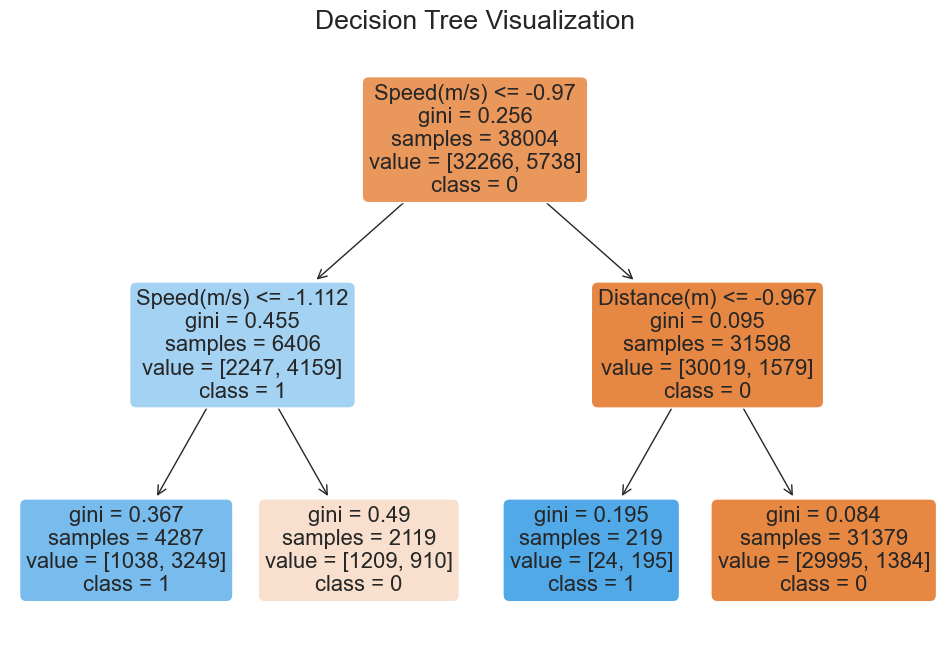

In [171]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree


class_names = list(map(str, tree.classes_))


plt.figure(figsize=(12, 8))
plot_tree(tree, filled=True, feature_names=x_train.columns.tolist(), class_names=class_names, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

We thought that this would be interesting to show and below we plotted how the tree would look like with large dataset and without restricting its roots :)

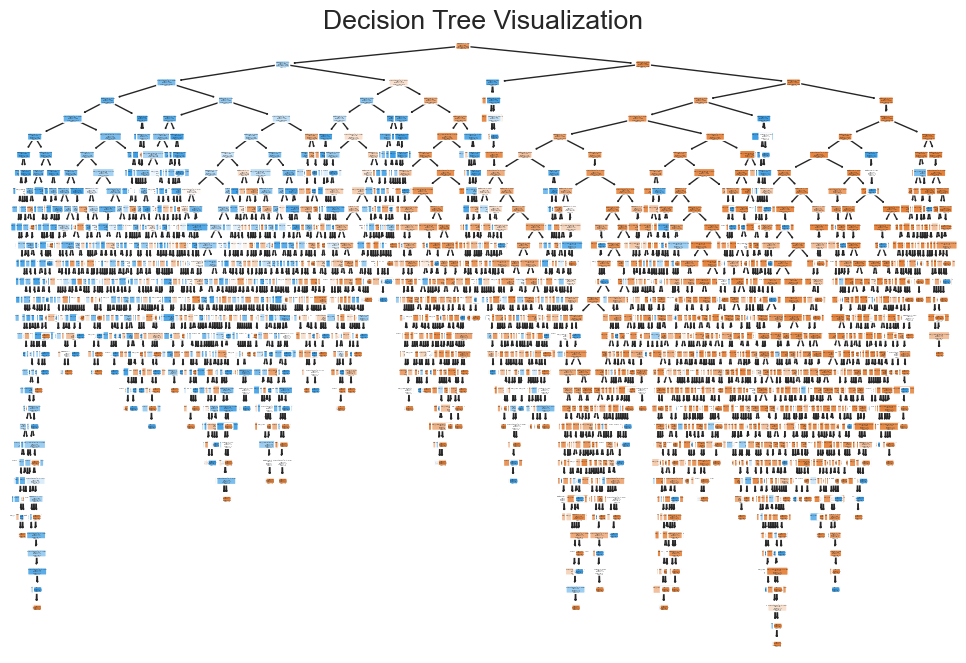

In [170]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree


class_names = list(map(str, tree1.classes_))


plt.figure(figsize=(12, 8))
plot_tree(tree1, filled=True, feature_names=x_train.columns.tolist(), class_names=class_names, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

Below is the report of f1, recall and precision score with support showing the number of samples. This code is very convenient to use and this code is available in the lecture notes as well. One can use this method from scikit learn to compute the f1, recall and precision scores.

Observation:

For the first tree (training set):

- For training data the class 0 is perfect but we mainly want to increase the scores of class 1 because basically all of the models are doing great with classifiying class 0.
- Class 1 has not really improved with depth 2, this is maybe obvious because for such large data depth 2 is not that deep and the model can not really catch all the information with this depth, hence we should definietly do grid search and try to find the optimal parameters.
- For class 1 the precision score is 76%, telling us that out of predicted class 1 samples, 76% are correct and 24% are incorrectly classified, the recall score is 60% , this means that out of true class 1 samples our model has catched only 60% of them and the rest 40% our model has missed.
- F1 score for class 1 is 67% not good.

For testing set: 

- We see that the scores are better than the training with precision, recall and f1 score being 75%, 63% and 69% respectively telling us the model is kind of underfitting, this is due to the fact that we have put only one parameter max depth being equal to 2.


For the tree model where the parameters are with default:

- We can see that the model with default parameters is doing perfect on the training data.
- For the testing report we can see that the model has 73% of precision, 76% of recall and 74% of f1 score, telling us that the testing reports are increasing but in this case the model overfits, this is why, as was mentioned before, we definitely will do grid search to see how well we can make the model to perform with the best parameters.

In [137]:
from sklearn.metrics import classification_report

print(classification_report(y_train, tree.predict(x_train)))
print(classification_report(y_test, tree.predict(x_test)))


print(classification_report(y_train, tree1.predict(x_train)))
print(classification_report(y_test, tree1.predict(x_test)))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     32266
           1       0.76      0.60      0.67      5738

    accuracy                           0.91     38004
   macro avg       0.85      0.78      0.81     38004
weighted avg       0.91      0.91      0.91     38004

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7372
           1       0.75      0.63      0.69      1100

    accuracy                           0.92      8472
   macro avg       0.85      0.80      0.82      8472
weighted avg       0.92      0.92      0.92      8472

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32266
           1       1.00      1.00      1.00      5738

    accuracy                           1.00     38004
   macro avg       1.00      1.00      1.00     38004
weighted avg       1.00      1.00      1.00     38004

              preci

Below we will be doing grid search of several parameters using cross validation = 5, with the max depth ranging from 1 to 10 and other parameters.

Observation:

- Grid search found the best parameters for this model namely 'max_depth': 8, 'max_features': 5, 'min_samples_leaf': 4, 'min_samples_split': 2

- We can see that with these parameters decision tree model has achieved roughly 95% on both training and testing datas which tell us that there is no overfitting, so we have to check the f1, precision and recall scores, to see how well the model is doing on class 1.


In [118]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': list(range(1, 10)),
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
    'max_features': [3,5],
}


grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5, verbose=1, n_jobs=-1)


grid.fit(x_train, y_train)

print("Best parameters found:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)


train_accuracy = grid.score(x_train, y_train)
print("Train accuracy:", train_accuracy)


test_accuracy = grid.score(x_test, y_test)
print("Test accuracy:", test_accuracy)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters found: {'max_depth': 8, 'max_features': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation score: 0.9414536175987924
Train accuracy: 0.946321439848437
Test accuracy: 0.9480642115203022


When looking to the report of the found best parameters below we can see the following observation:

- For the testing data our model has increased the precision score from 73% to 84%, which means that out of predicted class 1 samples 84% are correctly classified, but the rest 16% are incorrectly classified whereas the recall score has decreased a little bit but still we have improved the overall f1 score from 74% to 79%.


In [129]:
from sklearn.metrics import classification_report
best_model = grid.best_estimator_

print(classification_report(y_train, best_model.predict(x_train)))
print()
print()



best_model = grid.best_estimator_

print(classification_report(y_test, best_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     32266
           1       0.87      0.76      0.81      5738

    accuracy                           0.95     38004
   macro avg       0.91      0.87      0.89     38004
weighted avg       0.94      0.95      0.94     38004



              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7372
           1       0.84      0.74      0.79      1100

    accuracy                           0.95      8472
   macro avg       0.90      0.86      0.88      8472
weighted avg       0.95      0.95      0.95      8472



#### **Ensemble method**

One of the most elementary ensemble methods consists on training  a common training set several diverse types of classification models (e.g., a logistic regression model, a kNN classifier, and a decision tree) and then aggregate these into a single model by performing a majority vote.
This is called a voting classifier. It is implemented in scikit-learn via the VotingClassifier class.

Below we will aggregate the models that we have found so far with the best parameters into one bigger model. If we do this by default, it will take the majority vote which is called "hard voting" but we have tried this and this does not increase, so below we will pass the parameter voting='soft' which means that the classifier computes the average of the probabilities predicted by the individual classifiers, and then chooses the class with the highest average predicted probability. This can be helpful, since it gives higher weight to the classifiers that "have a high confidence in their decision".

Observation:

In this ensemble method now, the scores are smoothened a little bit, meaning that the recall score now has increased again to 76%, and if we compare the row decision model with this method then we see that the precision score has also increased to 80% , totaling of f1 score is 78%. This model is more balanced than the previous decision tree model with the best hyperparameters. In terms of being balanced between precision and recall, now the difference of recall and precision is not too big as it was in the previous model 84% and 74%, now it is 80% and 76% only 4%.

In [142]:
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier






voting_clf = VotingClassifier(estimators=[('log_reg', LogisticRegression(random_state=0)),
                                          ('kNN', KNeighborsClassifier(n_neighbors=19,)),
                                          ('tree', DecisionTreeClassifier(max_depth=8,max_features=5, min_samples_leaf=4, min_samples_split=2,
                                                                          random_state=0))], voting='soft')

from sklearn.pipeline import Pipeline
#
pipe = Pipeline(steps=[('scaler', StandardScaler()),
                       ('clf', voting_clf)])


voting_clf.fit(x_train, y_train)

print("Voting classifier accuracy:", voting_clf.score(x_test, y_test))



print(classification_report(y_train, voting_clf.predict(x_train)))
print(classification_report(y_test, voting_clf.predict(x_test)))

Voting classifier accuracy: 0.9434608120868744
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     32266
           1       0.83      0.76      0.79      5738

    accuracy                           0.94     38004
   macro avg       0.89      0.87      0.88     38004
weighted avg       0.94      0.94      0.94     38004

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      7372
           1       0.80      0.76      0.78      1100

    accuracy                           0.94      8472
   macro avg       0.88      0.86      0.87      8472
weighted avg       0.94      0.94      0.94      8472



#### **Final results of decision trees**

With ensemle method we have achieved:

- Precision score: 80%
- Recall score: 76%
- F1 score : 78%

#### **Random Forest**

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(["Driving_Pattern", "Latitude", "Longitude"], axis=1)
y_train = df1["Driving_Pattern"]

x_test = df2.drop(["Driving_Pattern", "Latitude", "Longitude"], axis =1)
y_test = df2["Driving_Pattern"]

As usual we will try a simple random forest model without any parameters, except setting number of trees being 700 and see how the model is doing.

Observation:

- We have achieved a training score of almost perfect because we have not restricted the depth or other paramers thus the tree is catching everythig on the training data with the accuracy of 99.9%

- It is clear and obvious that the testing accuracy is 95% , which tells us that we are suffering from overfitting which is expected if one does not tune the parameters of random forest model and only uses the default parameters, Hence we will also perform a grid search with cross validation equal 5 to find the best parameters and continue with the found best parameters. But before doing this we chech the f1, precision and recall scores as well for this default random forest model.

In [150]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score

forest = RandomForestClassifier(n_estimators=700,
                                #max_leaf_nodes=16,
                                #max_features=3,
                                n_jobs=-1,
                                random_state=42,
                                #verbose=1 (no need because takes about 35 seconds)
                                )
forest.fit(x_train, y_train)


print("Train accuracy:", forest.score(x_train, y_train))

print("Test  accuracy:", forest.score(x_test, y_test))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done 700 out of 700 | elapsed:   30.9s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done 700 out of 700 | elapsed:    2.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s


Train accuracy: 0.9998421218819071


[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.4s


Test  accuracy: 0.9527856468366384


[Parallel(n_jobs=4)]: Done 700 out of 700 | elapsed:    0.6s finished


Observation for the classification report:

- As we have expected we are suffering from overfitting with perfect scores on the training data.
- On the training data have increased the score of precision to 84%, the recall score to 79% and the f1 score to 81%. 

We now have to tune the parametrs to reduce overfitting and perform the model once more with the found hyperparameters

In [151]:
from sklearn.metrics import classification_report

print(classification_report(y_train, forest.predict(x_train)))
print()
print(classification_report(y_test, forest.predict(x_test)))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 700 out of 700 | elapsed:    2.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32266
           1       1.00      1.00      1.00      5738

    accuracy                           1.00     38004
   macro avg       1.00      1.00      1.00     38004
weighted avg       1.00      1.00      1.00     38004




[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.4s


              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7372
           1       0.84      0.79      0.81      1100

    accuracy                           0.95      8472
   macro avg       0.90      0.88      0.89      8472
weighted avg       0.95      0.95      0.95      8472



[Parallel(n_jobs=4)]: Done 700 out of 700 | elapsed:    0.9s finished


We are doing grid search using cross validation but with only cheking on two parametrs because this will be fast checking if in case if we can achieve close to the best performance then we will not perform further fine tuning.

Observation:

- We have found : 'max_depth': 10, 'max_features': 3 are the best parameters for this grid search using only these parameters
- We now has reduced the overfitting and the training and the testing accuracies are now 95% both.


In [154]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [2,5,10],
    #'min_samples_split': [2, 5],
    #'min_samples_leaf': [2, 4],
    'max_features': [3,5],
}


grid = GridSearchCV(RandomForestClassifier(), params, cv=5, verbose=1, n_jobs=-1)


grid.fit(x_train, y_train)


print("Best parameters found:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)


train_accuracy = grid.score(x_train, y_train)
print("Train accuracy:", train_accuracy)


test_accuracy = grid.score(x_test, y_test)
print("Test accuracy:", test_accuracy)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found: {'max_depth': 10, 'max_features': 3}
Best cross-validation score: 0.945663728456782
Train accuracy: 0.9563993263866961
Test accuracy: 0.9521954674220963


 Observation:

 Below we chech again the classification report and we see that we have no overfitting but the scores has increased drammatically compared to the other classifiers before and now we do some more fine tuning to see if we can increase further the performance of our model.
 
 - Precision score is 83%
 - Recall score is 80%
 - F1 score is 82%


In [158]:
best_model = grid.best_estimator_
print(classification_report(y_train, best_model.predict(x_train)))
print()
print(classification_report(y_test, best_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     32266
           1       0.98      0.90      0.94      5738

    accuracy                           0.98     38004
   macro avg       0.98      0.95      0.96     38004
weighted avg       0.98      0.98      0.98     38004


              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7372
           1       0.83      0.80      0.82      1100

    accuracy                           0.95      8472
   macro avg       0.90      0.89      0.89      8472
weighted avg       0.95      0.95      0.95      8472



Below we increase the number of parameters with grid search using cross validation.

Observation:

- Best parameters found: {'max_depth': 20, 'max_features': 3, 'min_samples_leaf': 2, 'min_samples_split': 5}
- Best cross-validation score: 0.9483476620112313
- Train accuracy: 0.9817650773602778
- Test accuracy: 0.9531397544853636


We see that there is approximately no further improvement, but now we are suffering from overfitting which tell us that the previous found parameters are doing better than these.

Note: This code runs for 62 minutes

In [157]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [10,15,20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
    'max_features': [3,5],
}


grid = GridSearchCV(RandomForestClassifier(n_estimators=400), params, cv=5, verbose=3, n_jobs=-1)


grid.fit(x_train, y_train)


print("Best parameters found:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)


train_accuracy = grid.score(x_train, y_train)
print("Train accuracy:", train_accuracy)


test_accuracy = grid.score(x_test, y_test)
print("Test accuracy:", test_accuracy)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found: {'max_depth': 20, 'max_features': 3, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best cross-validation score: 0.9483476620112313
Train accuracy: 0.9817650773602778
Test accuracy: 0.9531397544853636


In [159]:
best_model = grid.best_estimator_
print(classification_report(y_train, best_model.predict(x_train)))
print()
print(classification_report(y_test, best_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     32266
           1       0.98      0.90      0.94      5738

    accuracy                           0.98     38004
   macro avg       0.98      0.95      0.96     38004
weighted avg       0.98      0.98      0.98     38004


              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7372
           1       0.83      0.80      0.82      1100

    accuracy                           0.95      8472
   macro avg       0.90      0.89      0.89      8472
weighted avg       0.95      0.95      0.95      8472



Train on the full data

In [180]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score

forest = RandomForestClassifier(n_estimators=700,
                                #max_leaf_nodes=16,
                                #max_features=3,
                                max_depth=10,
                                max_features=3,
                                n_jobs=-1,
                                random_state=42,
                                
                                )
forest.fit(x_train, y_train)


print("Train accuracy:", forest.score(x_train, y_train))

print("Test  accuracy:", forest.score(x_test, y_test))

Train accuracy: 0.9565835175244711
Test  accuracy: 0.9527856468366384


In [181]:
print(classification_report(y_train, best_model.predict(x_train)))
print()
print(classification_report(y_test, best_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     32266
           1       0.98      0.90      0.94      5738

    accuracy                           0.98     38004
   macro avg       0.98      0.95      0.96     38004
weighted avg       0.98      0.98      0.98     38004


              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7372
           1       0.83      0.80      0.82      1100

    accuracy                           0.95      8472
   macro avg       0.90      0.89      0.89      8472
weighted avg       0.95      0.95      0.95      8472



#### **Extra trees**

This is simple extra tree, we tried this one also to see if we can get any better.

Observation:

Train accuracy: 0.9225607830754657

Test  accuracy: 0.9320113314447592


In [186]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import precision_score, recall_score

forest = ExtraTreesClassifier(n_estimators=500,
                              max_leaf_nodes=16,
                              max_features=3,
                              n_jobs=-1,
                              random_state=42)
forest.fit(x_train, y_train)


print("Train accuracy:", forest.score(x_train, y_train))
print("Test  accuracy:", forest.score(x_test, y_test))

Train accuracy: 0.9225607830754657
Test  accuracy: 0.9320113314447592


We will do grid search to find the best parameters below using cross validation.

Observation:

Best parameters found: {'max_depth': 10, 'max_features': 5}

Train accuracy: 0.9561888222292391

Test  accuracy: 0.9529036827195467

In [195]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [2,5,10],
    #'min_samples_split': [2, 5],
    #'min_samples_leaf': [2, 4],
    'max_features': [3,5],
}


grid = GridSearchCV(ExtraTreesClassifier(n_estimators=500), params, cv=5, verbose=1, n_jobs=-1)


grid.fit(x_train, y_train)


print("Best parameters found:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)


train_accuracy = grid.score(x_train, y_train)
print("Train accuracy:", train_accuracy)


test_accuracy = grid.score(x_test, y_test)
print("Test accuracy:", test_accuracy)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found: {'max_depth': 20, 'max_features': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best cross-validation score: 0.9501106779578865
Train accuracy: 0.981607199242185
Test accuracy: 0.95561850802644


Train on the full data

- Train accuracy: 0.9561888222292391
- Test  accuracy: 0.9529036827195467

In [199]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import precision_score, recall_score

forest = ExtraTreesClassifier(n_estimators=500,
                              max_depth=13,
                              max_features=5,
                              n_jobs=-1,
                              random_state=42)
forest.fit(x_train, y_train)


print("Train accuracy:", forest.score(x_train, y_train))
print("Test  accuracy:", forest.score(x_test, y_test))

Train accuracy: 0.9561888222292391
Test  accuracy: 0.9529036827195467


- Precision 83%
- Recall 80% 
- F1 SCORE 82%

In [200]:
print(classification_report(y_train, forest.predict(x_train)))
print()
print(classification_report(y_test, forest.predict(x_test)))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     32266
           1       0.88      0.82      0.85      5738

    accuracy                           0.96     38004
   macro avg       0.92      0.90      0.91     38004
weighted avg       0.96      0.96      0.96     38004


              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7372
           1       0.83      0.80      0.82      1100

    accuracy                           0.95      8472
   macro avg       0.90      0.89      0.89      8472
weighted avg       0.95      0.95      0.95      8472



#### **Feature engineering**

We load the data.


In [201]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(["Driving_Pattern", "Latitude", "Longitude"], axis=1)
y_train = df1["Driving_Pattern"]

x_test = df2.drop(["Driving_Pattern", "Latitude", "Longitude"], axis =1)
y_test = df2["Driving_Pattern"]

Below we will try feature engineering which is crucially important in machine learning, to see if we can improve the performance of our model.

- Firstly we replace all the 0 values in distance, speed and acceleration with missing values.
- Secondly we replace all positive and negative infinity values with missing values.
- Thirdly we replace all the missing values with the mean of the columns because missing values can not be given to the machine learning algorithm, they can not handle them.
- Then very importantly we add some new columns using log function, reciprocal and quotients.

- We use pipeline and set polynomial feature of degree 2 without standard scaling because random forest does not need scaling.


Observation:

We now improved our model's performance :

- Training score: 0.9630565203662772

- Testing score: 0.9603399433427762

- No overfitting


We will now calculate the f1, precision and recall scores to see how we have improved.

In [260]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id", "Latitude", "Longitude"], axis=1, inplace=True)
df2.drop(["Id", "Latitude", "Longitude"], axis=1, inplace=True)

y_train = df1["Driving_Pattern"]


y_test = df2["Driving_Pattern"]

new_df1 = df1[[ "Fuel_Consumption(liter)", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()


new_df1["Distance(m)"].replace(0, np.nan, inplace=True)
new_df1["Speed(m/s)"].replace(0, np.nan, inplace=True)
new_df1["Acceleration(m/s^2)"].replace(0, np.nan, inplace=True)

new_df1.replace([np.inf, -np.inf], np.nan, inplace=True)
# Impute NaN values with column means
imputer = SimpleImputer(strategy='mean')
new_df1 = pd.DataFrame(imputer.fit_transform(new_df1), columns=new_df1.columns)


new_df1["Transformed Distance"] = np.log(df1["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df1["Transformed Acceleration"] = np.sqrt(np.abs(df1["Acceleration(m/s^2)"]))
new_df1["Transformed Load"] = np.log(df1["Load(kg)"] + 1) 
new_df1["Transformed Speed"] = np.sqrt(df1["Speed(m/s)"])


new_df1["Reciprocal Distance"] = 1./df1["Distance(m)"] # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df1["Reciprocal Acceleration"] = 1./df1["Acceleration(m/s^2)"]
new_df1["Reciprocal Speed"] = 1./df1["Speed(m/s)"]

new_df1['Distance_Speed_Quotient'] = new_df1['Distance(m)'] / new_df1['Speed(m/s)']
new_df1['Speed_Distance_Quotient'] = new_df1['Speed(m/s)'] / new_df1['Distance(m)']

# Replace infinities with NaN
new_df1.replace([np.inf, -np.inf], np.nan, inplace=True)
# Impute NaN values with column means
imputer = SimpleImputer(strategy='mean')
new_df1 = pd.DataFrame(imputer.fit_transform(new_df1), columns=new_df1.columns)




new_df2 = df2[[ "Fuel_Consumption(liter)", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()

new_df2["Distance(m)"].replace(0, np.nan, inplace=True)
new_df2["Speed(m/s)"].replace(0, np.nan, inplace=True)
new_df2["Acceleration(m/s^2)"].replace(0, np.nan, inplace=True)

# Apply transformations for testing
new_df2["Transformed Distance"] = np.log(df2["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df2["Transformed Acceleration"] = np.sqrt(np.abs(df2["Acceleration(m/s^2)"]))
new_df2["Transformed Load"] = np.log(df2["Load(kg)"] + 1) 
new_df2["Transformed Speed"] = np.sqrt(df2["Speed(m/s)"])


new_df2["Reciprocal Distance"] = 1./df2["Distance(m)"] # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df2["Reciprocal Acceleration"] = 1./df2["Acceleration(m/s^2)"]
new_df2["Reciprocal Speed"] = 1./df2["Speed(m/s)"]

new_df2['Distance_Speed_Quotient'] = new_df2['Distance(m)'] / new_df2['Speed(m/s)']
new_df2['Speed_Distance_Quotient'] = new_df2['Speed(m/s)'] / new_df2['Distance(m)']
# Replace infinities with NaN 
new_df2.replace([np.inf, -np.inf], np.nan, inplace=True)
# Impute NaN values with column means
new_df2 = pd.DataFrame(imputer.fit_transform(new_df2), columns=new_df2.columns)


pipe = Pipeline([('poly', PolynomialFeatures(degree=2)),
                 ("forest", RandomForestClassifier(max_depth=10, max_features=5, verbose=1, n_jobs=-1, n_estimators=400, random_state=41))])

pipe.fit(new_df1, y_train)

print(pipe.score(new_df1, y_train))
print(pipe.score(new_df2, y_test))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   26.4s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:   50.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:    1.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s


0.9630565203662772


[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s


0.9603399433427762


[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:    0.4s finished


Below we see the classification report.

Observation:

- We see that with introducing new columns namely performing feature engineering we have increased both our precision and recall score, which also resulted in the increasement of f1 score in total.

- Precision score now is 85% which means that out of predicted class 1 samples 85% is correct and 15% is incorrect.

- Recall score is now 84% which means that now we can catch 84% of the class 1 samples as class 1, we only miss 16% of the class 1.

- Overall with these increased scores we get a total of 85% in F1 score which is pretty good if we actually take class 1 more serious than class 0.


In [223]:
print(classification_report(y_train, pipe.predict(new_df1)))
print()
print(classification_report(y_test, pipe.predict(new_df2)))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    1.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s


              precision    recall  f1-score   support

           0       0.97      0.98      0.98     32266
           1       0.90      0.85      0.87      5738

    accuracy                           0.96     38004
   macro avg       0.94      0.92      0.93     38004
weighted avg       0.96      0.96      0.96     38004


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7372
           1       0.85      0.84      0.85      1100

    accuracy                           0.96      8472
   macro avg       0.91      0.91      0.91      8472
weighted avg       0.96      0.96      0.96      8472



[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.2s finished


#### **Confusion matrix for testing data**

Observation:

- Out of 1100 class 1 samples in y_test namely in unseen data our model is predicting 917 samples roughly 84% correctly.
- Out of 1070 predicted class 1 samples 917 are actually class 1, the rest 153 are predicted incorrectly which actually belong to class 0.

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:    0.3s finished


[[7219  153]
 [ 183  917]]


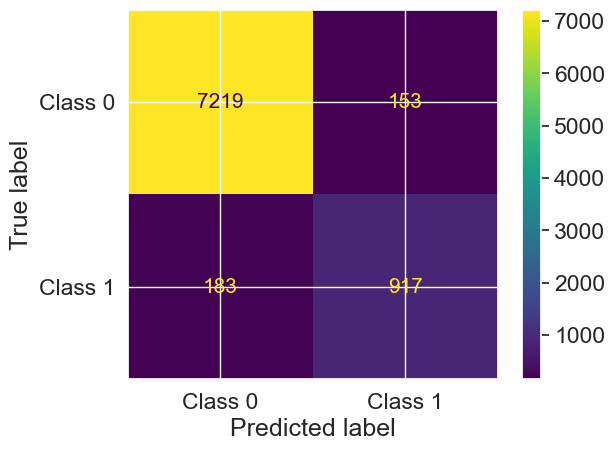

In [261]:

predictions = pipe.predict(new_df2)

# Compute the confusion matrix based on the predictions
# The first argument should be the TRUE/ACTUAL labels
# The second argument the PREDICTED labels
cm = confusion_matrix(y_test, predictions)
print(cm) 


disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Class 0", "Class 1"])

disp.plot()
plt.show()

#### **Confusion matrix with cross validation**

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   29.9s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:   51.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   20.8s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:   41.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | e

[[31511   755]
 [ 1065  4673]]


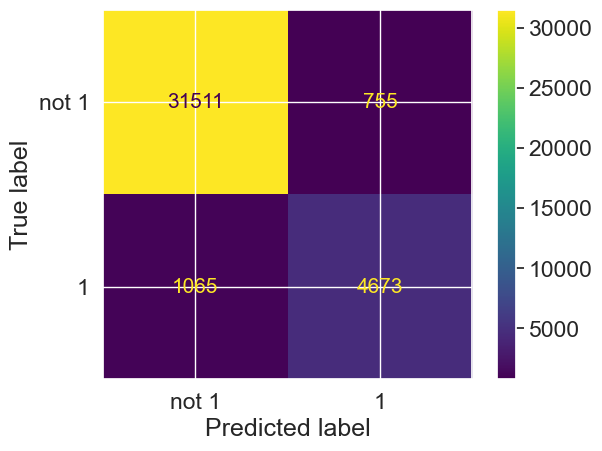

In [254]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt


plt.rcParams.update({'font.size': 15})


skf = StratifiedKFold(n_splits=5)
predictions = cross_val_predict(pipe, new_df1, y_train, cv=skf)


cm = confusion_matrix(y_train, predictions)
print(cm) 


disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Class 0", "Class 1"])

disp.plot()
plt.show()

This is simple extra tree, we tried this one also to see if we can get any better.

Observation:
Train accuracy: 0.9225607830754657
Test  accuracy: 0.9320113314447592


#### **Final results of random forest**
- Train accuracy : 96%
- Test accuracy : 96%

- Precision Score : 85%
- Recall score : 84%
- F1 SCORE : 85%

#### **Comparison of classification models**

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   21.4s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:   43.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:    0.3s finished


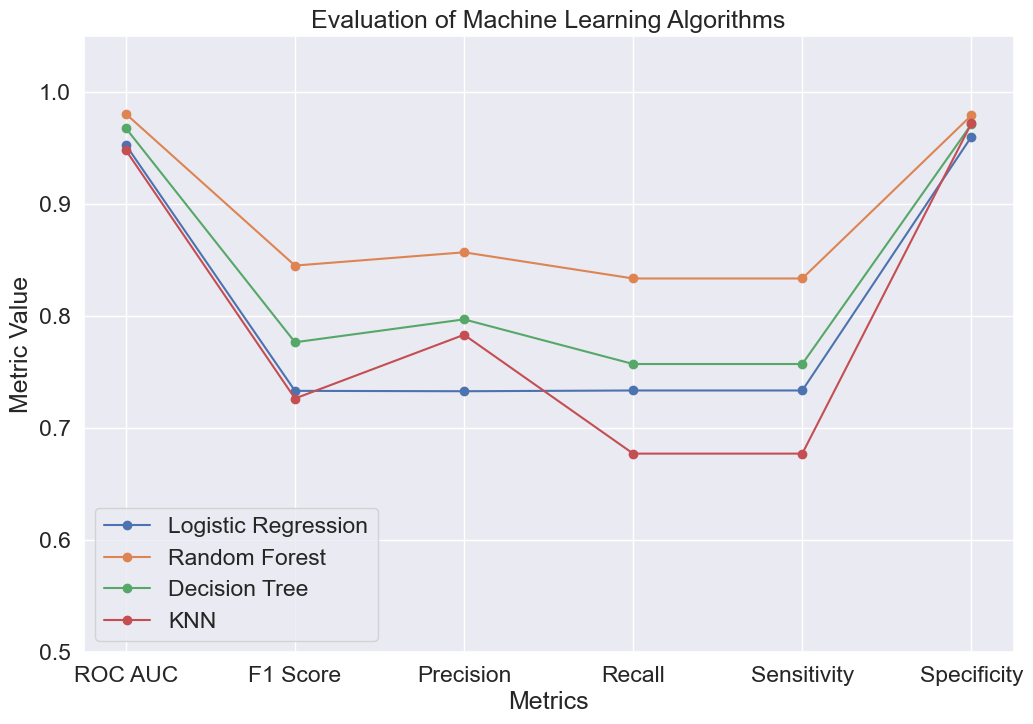

In [281]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler



# LOGISTIC

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(["Driving_Pattern", "Latitude", "Longitude"], axis=1)
y_train = df1["Driving_Pattern"]

x_test = df2.drop(["Driving_Pattern", "Latitude", "Longitude"], axis =1)
y_test = df2["Driving_Pattern"]

pipe_logistic = Pipeline([('scaler', StandardScaler()),
                 ('logreg', LogisticRegression())])





# RANDOM FOREST



df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id", "Latitude", "Longitude"], axis=1, inplace=True)
df2.drop(["Id", "Latitude", "Longitude"], axis=1, inplace=True)

y_train = df1["Driving_Pattern"]


y_test = df2["Driving_Pattern"]

new_df1 = df1[[ "Fuel_Consumption(liter)", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()


new_df1["Distance(m)"].replace(0, np.nan, inplace=True)
new_df1["Speed(m/s)"].replace(0, np.nan, inplace=True)
new_df1["Acceleration(m/s^2)"].replace(0, np.nan, inplace=True)

new_df1.replace([np.inf, -np.inf], np.nan, inplace=True)
# Impute NaN values with column means
imputer = SimpleImputer(strategy='mean')
new_df1 = pd.DataFrame(imputer.fit_transform(new_df1), columns=new_df1.columns)


new_df1["Transformed Distance"] = np.log(df1["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df1["Transformed Acceleration"] = np.sqrt(np.abs(df1["Acceleration(m/s^2)"]))
new_df1["Transformed Load"] = np.log(df1["Load(kg)"] + 1) 
new_df1["Transformed Speed"] = np.sqrt(df1["Speed(m/s)"])


new_df1["Reciprocal Distance"] = 1./df1["Distance(m)"] # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df1["Reciprocal Acceleration"] = 1./df1["Acceleration(m/s^2)"]
new_df1["Reciprocal Speed"] = 1./df1["Speed(m/s)"]

new_df1['Distance_Speed_Quotient'] = new_df1['Distance(m)'] / new_df1['Speed(m/s)']
new_df1['Speed_Distance_Quotient'] = new_df1['Speed(m/s)'] / new_df1['Distance(m)']

# Replace infinities with NaN
new_df1.replace([np.inf, -np.inf], np.nan, inplace=True)
# Impute NaN values with column means
imputer = SimpleImputer(strategy='mean')
new_df1 = pd.DataFrame(imputer.fit_transform(new_df1), columns=new_df1.columns)




new_df2 = df2[[ "Fuel_Consumption(liter)", "Speed(m/s)", "Distance(m)", "Acceleration(m/s^2)", "Load(kg)"]].copy()

new_df2["Distance(m)"].replace(0, np.nan, inplace=True)
new_df2["Speed(m/s)"].replace(0, np.nan, inplace=True)
new_df2["Acceleration(m/s^2)"].replace(0, np.nan, inplace=True)

# Apply transformations for testing
new_df2["Transformed Distance"] = np.log(df2["Distance(m)"] + 1) # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df2["Transformed Acceleration"] = np.sqrt(np.abs(df2["Acceleration(m/s^2)"]))
new_df2["Transformed Load"] = np.log(df2["Load(kg)"] + 1) 
new_df2["Transformed Speed"] = np.sqrt(df2["Speed(m/s)"])


new_df2["Reciprocal Distance"] = 1./df2["Distance(m)"] # we add 1 to log because log of 0 is undefined and log of very small values give extremely large negative values
new_df2["Reciprocal Acceleration"] = 1./df2["Acceleration(m/s^2)"]
new_df2["Reciprocal Speed"] = 1./df2["Speed(m/s)"]

new_df2['Distance_Speed_Quotient'] = new_df2['Distance(m)'] / new_df2['Speed(m/s)']
new_df2['Speed_Distance_Quotient'] = new_df2['Speed(m/s)'] / new_df2['Distance(m)']
# Replace infinities with NaN 
new_df2.replace([np.inf, -np.inf], np.nan, inplace=True)
# Impute NaN values with column means
new_df2 = pd.DataFrame(imputer.fit_transform(new_df2), columns=new_df2.columns)

pipe_random_forest = Pipeline([('poly', PolynomialFeatures(degree=2)),
                 ("forest", RandomForestClassifier(max_depth=10, max_features=5, verbose=1, n_jobs=-1, n_estimators=400, random_state=41))])















# VOTING CLASSIFIER DECISION TREE

from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier






voting_clf = VotingClassifier(estimators=[('log_reg', LogisticRegression(random_state=0)),
                                          ('kNN', KNeighborsClassifier(n_neighbors=19,)),
                                          ('tree', DecisionTreeClassifier(max_depth=8,max_features=5, min_samples_leaf=4, min_samples_split=2,
                                                                          random_state=0))], voting='soft')

from sklearn.pipeline import Pipeline
#
pipe = Pipeline(steps=[('scaler', StandardScaler()),
                       ('clf', voting_clf)])
















# KNN

df1 = pd.read_csv("training_dataset.csv")
df2 = pd.read_csv("testing_dataset.csv")


df2.rename(columns={'Acceleration(m^2)': 'Acceleration(m/s^2)'}, inplace=True)
df1.drop(["Id"], axis=1, inplace=True)
df2.drop(["Id"], axis=1, inplace=True)


x_train = df1.drop(["Driving_Pattern", "Latitude", "Longitude"], axis=1)
y_train = df1["Driving_Pattern"]

x_test = df2.drop(["Driving_Pattern", "Latitude", "Longitude"], axis =1)
y_test = df2["Driving_Pattern"]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

knn = KNeighborsClassifier(n_neighbors=19) # just a random k value , we will demonstrate how to tune this below

knn.fit(x_train, y_train)



# Function to calculate and return metrics
def calculate_metrics(y_true, y_pred, y_proba):
    # Calculate ROC AUC score
    roc_auc = roc_auc_score(y_true, y_proba[:, 1])
    
    # Calculate F1 score
    f1_scores = f1_score(y_true, y_pred)
    
    # Calculate precision and recall
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate sensitivity (recall for the positive class) and specificity
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    return {
        'ROC AUC': roc_auc,
        'F1 Score': f1_scores,
        'Precision': precision,
        'Recall': recall,
        'Sensitivity': sensitivity,
        'Specificity': specificity
    }

# Dictionary to store results
results = {
    'Logistic Regression': {},
    'Random Forest': {},
    'Decision Tree': {},
    'KNN': {}
}

# Train and predict with Logistic Regression model
threshold = 0.4414745606625674  # calculated above
pipe_logistic.fit(x_train, y_train)
y_proba_lr = pipe_logistic.predict_proba(x_test)
y_pred_lr = (y_proba_lr[:, 1] >= threshold).astype(int)
results['Logistic Regression'] = calculate_metrics(y_test, y_pred_lr, y_proba_lr)

# Train and predict with Random Forest model
pipe_random_forest.fit(new_df1, y_train)
y_pred_rf = pipe_random_forest.predict(new_df2)
y_proba_rf = pipe_random_forest.predict_proba(new_df2)
results['Random Forest'] = calculate_metrics(y_test, y_pred_rf, y_proba_rf)

#  voting  decision
pipe.fit(x_train, y_train)
y_pred_gb = pipe.predict(x_test)
y_proba_gb = pipe.predict_proba(x_test)
results['Decision Tree'] = calculate_metrics(y_test, y_pred_gb, y_proba_gb)

# Train and predict with KNN model
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
y_proba_knn = knn.predict_proba(x_test)
results['KNN'] = calculate_metrics(y_test, y_pred_knn, y_proba_knn)

# Adjusted Plotting Section
metrics = ['ROC AUC', 'F1 Score', 'Precision', 'Recall', 'Sensitivity', 'Specificity']
plt.figure(figsize=(12, 8))

for model_name in results.keys():
    plt.plot(metrics, [results[model_name][metric] for metric in metrics], marker='o', label=model_name)

plt.title('Evaluation of Machine Learning Algorithms')
plt.xlabel('Metrics')
plt.ylabel('Metric Value')
plt.ylim(0.5, 1.05)  # Adjust based on your metric ranges
plt.legend()
plt.grid(True)
plt.show()

#### **Conclusion**

In this project, we aimed to classify driving patterns using four different machine learning algorithms: Logistic Regression, Random Forest, Decision Tree, and K-Nearest Neighbors (KNN). We evaluated these models based on several performance metrics, including ROC AUC, F1 Score, Precision, Recall.

**Phase 1: Predicting Fuel Consumption**

In the initial phase of our project, we focused on predicting fuel consumption as a regression problem. However, due to the nature of the data, which was based on instant values rather than average values, the regression models did not perform well. This was evident from the poor R^2 scores, indicating that the models were unable to capture the relationship between the features and fuel consumption accurately. Consequently, we decided to shift our focus to classifying driving patterns, which seemed more feasible given the available data.

**Phase 2: Classifying Driving Patterns**

1. Logistic Regression:
    - Logistic Regression showed moderate performance across all metrics. The ROC AUC score indicates decent discriminative power, but it had the lowest F1 Score, Precision, and Recall among the models, suggesting challenges in capturing the complexities of the driving patterns. Not the top performer.
    

2. Random Forest:
    - Random Forest outperformed the other models in most metrics. It achieved the highest ROC AUC score, indicating excellent ability to distinguish between classes. It also maintained high values in Precision, Recall, Sensitivity, and Specificity, making it the most balanced and reliable model for this classification task.

    - Best Model: The Random Forest model emerged as the best performer in this study, offering the highest ROC AUC score and well-rounded performance across all metrics. Its ability to handle complex patterns in the data makes it the most suitable choice for our driving pattern classification task.

3. Decision Tree:
    - The Decision Tree classifier exhibited competitive performance, especially in Sensitivity and Specificity. While its ROC AUC score and F1 Score were slightly lower than those of the Random Forest, it still provided a robust model with relatively high Precision and Recall. This model strikes a good balance between performance and interpretability, providing a competitive alternative to Random Forest, especially when computational resources are limited.

4. K-Nearest Neighbors (KNN):
    - The KNN model had mixed results. It showed high Specificity but lower Sensitivity and F1 Score. This indicates that while KNN was good at correctly identifying negative cases, it struggled more with positive cases, which could be a limitation in certain applications.
  

This study demonstrates that machine learning models, particularly ensemble methods like Random Forest, can effectively classify driving pattern. We explored various approaches including feature engineering, hyperparameter tuning, and ensemble methods to achieve optimal results. With these models, we can optimize driving behaviors, paving the way for practical applications in real-world scenarios.